<a href="https://colab.research.google.com/github/ThisumiWijesinghe/Pop_Pyramid_Clustering/blob/main/pop_pyramids_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#spectral with countries

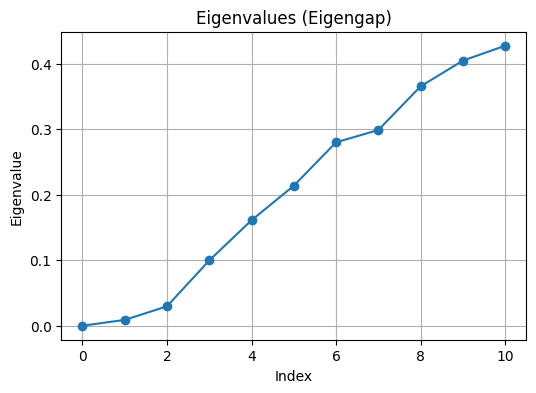

Optimal number of clusters: 3
                   Country  Cluster
1                  Albania        0
7                Australia        0
6                  Armenia        0
8                  Austria        0
13                Barbados        0
14                 Belarus        0
15                 Belgium        0
20  Bosnia and Herzegovina        0
24                Bulgaria        0
30                  Canada        0
42                 Czechia        0
44                 Denmark        0
39                    Cuba        0
38                 Croatia        0
33                   China        0
32                   Chile        0
40                 Curaçao        0
41                  Cyprus        0
52                 Estonia        0
61                 Germany        0
60                 Georgia        0
56                 Finland        0
57                  France        0
63                  Greece        0
80                   Italy        0
82                   Japan        

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import normalize
from sklearn.neighbors import kneighbors_graph

# =====================================================
# PROMPT
# Spectral clustering of countries using population
# pyramids (21 age groups) with kNN affinity
# =====================================================

CSV_PATH = "age_data_1.csv"
YEAR = 2020
N_NEIGHBORS = 12     # VERY IMPORTANT (8–15 works well)
MAX_EIGEN = 11

# =========================
# LOAD DATA
# =========================
df = pd.read_csv(CSV_PATH)
df_year = df[df["Time"] == YEAR].copy()

df_pivot = df_year.pivot(
    index="Location",
    columns="AgeGrp",
    values="PopTotal"
).fillna(0)

countries = df_pivot.index.values
X = df_pivot.values

assert X.shape[1] == 21, "Must have exactly 21 age groups"

# =========================
# NORMALIZE PYRAMIDS
# =========================
X = normalize(X, norm="l1")

# =========================
# BUILD kNN AFFINITY GRAPH
# =========================
W = kneighbors_graph(
    X,
    n_neighbors=N_NEIGHBORS,
    mode="connectivity",
    include_self=False
)

# make symmetric
W = 0.5 * (W + W.T)
W = W.toarray()

# =========================
# NORMALIZED LAPLACIAN
# =========================
degree = np.sum(W, axis=1)
D_inv_sqrt = np.diag(1.0 / np.sqrt(degree + 1e-10))
L = np.eye(W.shape[0]) - D_inv_sqrt @ W @ D_inv_sqrt

# =========================
# EIGENGAP
# =========================
eigenvals, _ = np.linalg.eigh(L)

plt.figure(figsize=(6,4))
plt.plot(eigenvals[:MAX_EIGEN], marker="o")
plt.xlabel("Index")
plt.ylabel("Eigenvalue")
plt.title("Eigenvalues (Eigengap)")
plt.grid(True)
plt.show()

gaps = np.diff(eigenvals[:MAX_EIGEN])
optimal_k = np.argmax(gaps) + 1

print("Optimal number of clusters:", optimal_k)

# =========================
# FINAL SPECTRAL CLUSTERING
# =========================
sc = SpectralClustering(
    n_clusters=optimal_k,
    affinity="nearest_neighbors",
    n_neighbors=N_NEIGHBORS,
    assign_labels="kmeans",
    random_state=42
)

labels = sc.fit_predict(X)

# =========================
# OUTPUT
# =========================
results = pd.DataFrame({
    "Country": countries,
    "Cluster": labels
}).sort_values("Cluster")

print(results.head(30))
print("\nCluster sizes:")
print(results["Cluster"].value_counts().sort_index())

print("Cluster 0:", ", ".join(results[results['Cluster'] == 0]['Country'].sort_values()))
print("Cluster 1:", ", ".join(results[results['Cluster'] == 1]['Country'].sort_values()))
print("Cluster 2:", ", ".join(results[results['Cluster'] == 2]['Country'].sort_values()))


Processing years: [np.int64(1975), np.int64(1980), np.int64(1985), np.int64(1990), np.int64(1995), np.int64(2000), np.int64(2005), np.int64(2010), np.int64(2015), np.int64(2020), np.int64(2025)]

Processing year: 1975
Computed optimal k for 1975: 3 (but using fixed k=3)
Cluster sizes for 1975:
Cluster
0    58
1    45
2    77
Name: count, dtype: int64

Processing year: 1980
Computed optimal k for 1980: 5 (but using fixed k=3)
Cluster sizes for 1980:
Cluster
0    60
1    46
2    74
Name: count, dtype: int64

Processing year: 1985
Computed optimal k for 1985: 3 (but using fixed k=3)
Cluster sizes for 1985:
Cluster
0    46
1    66
2    68
Name: count, dtype: int64

Processing year: 1990
Computed optimal k for 1990: 9 (but using fixed k=3)
Cluster sizes for 1990:
Cluster
0    52
1    65
2    63
Name: count, dtype: int64

Processing year: 1995
Computed optimal k for 1995: 9 (but using fixed k=3)
Cluster sizes for 1995:
Cluster
0    51
1    64
2    65
Name: count, dtype: int64

Processing yea

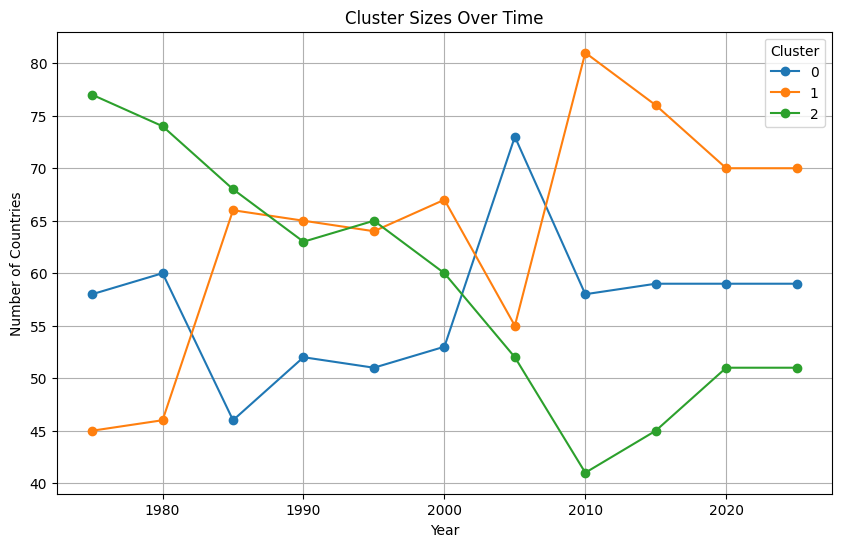

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import normalize
from sklearn.neighbors import kneighbors_graph

# =====================================================
# PROMPT
# Spectral clustering of countries using population
# pyramids (21 age groups) with kNN affinity
# Over time period 1975-2025
# =====================================================
CSV_PATH = "age_data_1.csv"
START_YEAR = 1975
END_YEAR = 2025
YEAR_STEP = 5  # Use 5-year steps to make it manageable; change to 1 for annual
N_NEIGHBORS = 12  # VERY IMPORTANT (8–15 works well)
MAX_EIGEN = 11
FIXED_K = 3  # Fix to 3 clusters for consistency over time (based on 2020 optimal)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv(CSV_PATH)
unique_years = sorted(df['Time'].unique())
years = [y for y in unique_years if START_YEAR <= y <= END_YEAR and (y - START_YEAR) % YEAR_STEP == 0]
print(f"Processing years: {years}")

# Prepare to collect results across years
all_results = []

for YEAR in years:
    print(f"\nProcessing year: {YEAR}")

    df_year = df[df["Time"] == YEAR].copy()
    if df_year.empty:
        print(f"No data for {YEAR}, skipping.")
        continue

    df_pivot = df_year.pivot(
        index="Location",
        columns="AgeGrp",
        values="PopTotal"
    ).fillna(0)

    countries = df_pivot.index.values
    X = df_pivot.values
    assert X.shape[1] == 21, "Must have exactly 21 age groups"

    # =========================
    # NORMALIZE PYRAMIDS
    # =========================
    X = normalize(X, norm="l1")

    # =========================
    # BUILD kNN AFFINITY GRAPH
    # =========================
    W = kneighbors_graph(
        X,
        n_neighbors=N_NEIGHBORS,
        mode="connectivity",
        include_self=False
    )
    # make symmetric
    W = 0.5 * (W + W.T)
    W = W.toarray()

    # =========================
    # NORMALIZED LAPLACIAN
    # =========================
    degree = np.sum(W, axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(degree + 1e-10))
    L = np.eye(W.shape[0]) - D_inv_sqrt @ W @ D_inv_sqrt

    # =========================
    # EIGENGAP (for info, but we'll use FIXED_K)
    # =========================
    eigenvals, _ = np.linalg.eigh(L)
    gaps = np.diff(eigenvals[:MAX_EIGEN])
    optimal_k = np.argmax(gaps) + 1
    print(f"Computed optimal k for {YEAR}: {optimal_k} (but using fixed k={FIXED_K})")

    # Plot eigengap (optional, comment out if too many plots)
    # plt.figure(figsize=(6,4))
    # plt.plot(eigenvals[:MAX_EIGEN], marker="o")
    # plt.xlabel("Index")
    # plt.ylabel("Eigenvalue")
    # plt.title(f"Eigenvalues (Eigengap) for {YEAR}")
    # plt.grid(True)
    # plt.show()

    # =========================
    # FINAL SPECTRAL CLUSTERING
    # =========================
    sc = SpectralClustering(
        n_clusters=FIXED_K,
        affinity="nearest_neighbors",
        n_neighbors=N_NEIGHBORS,
        assign_labels="kmeans",
        random_state=42
    )
    labels = sc.fit_predict(X)

    # =========================
    # COLLECT RESULTS
    # =========================
    year_results = pd.DataFrame({
        "Country": countries,
        "Year": YEAR,
        "Cluster": labels
    })
    all_results.append(year_results)

    # Print cluster sizes for this year
    print(f"Cluster sizes for {YEAR}:")
    print(year_results["Cluster"].value_counts().sort_index())

# Combine all results
full_df = pd.concat(all_results, ignore_index=True)

# Save to CSV for further analysis
full_df.to_csv("cluster_results_1975_2025.csv", index=False)
print("\nSaved results to 'cluster_results_1975_2025.csv'")

# Optional: Pivot for country-year-cluster table
pivot_df = full_df.pivot(index="Country", columns="Year", values="Cluster")
pivot_df.to_csv("cluster_pivot_1975_2025.csv")
print("Saved pivot table to 'cluster_pivot_1975_2025.csv'")

# Optional: Visualize cluster sizes over time
cluster_sizes = full_df.groupby(["Year", "Cluster"]).size().unstack(fill_value=0)
cluster_sizes.plot(kind="line", marker="o", figsize=(10,6))
plt.title("Cluster Sizes Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Countries")
plt.grid(True)
plt.legend(title="Cluster")
plt.show()

In [ ]:
#optimal and hyper prameter change


Processing year: 1975
Optimal number of clusters: 3
Cluster sizes:
Cluster
0    58
1    45
2    77
Name: count, dtype: int64

Processing year: 1980
Optimal number of clusters: 3
Cluster sizes:
Cluster
0    60
1    46
2    74
Name: count, dtype: int64

Processing year: 1985
Optimal number of clusters: 3
Cluster sizes:
Cluster
0    46
1    66
2    68
Name: count, dtype: int64

Processing year: 1990
Optimal number of clusters: 3
Cluster sizes:
Cluster
0    52
1    65
2    63
Name: count, dtype: int64

Processing year: 1995
Optimal number of clusters: 3
Cluster sizes:
Cluster
0    51
1    64
2    65
Name: count, dtype: int64

Processing year: 2000
Optimal number of clusters: 4
Cluster sizes:
Cluster
0    53
1    43
2    56
3    28
Name: count, dtype: int64

Processing year: 2005
Optimal number of clusters: 4
Cluster sizes:
Cluster
0    33
1    56
2    37
3    54
Name: count, dtype: int64

Processing year: 2010
Optimal number of clusters: 4
Cluster sizes:
Cluster
0    55
1    38
2    56
3 

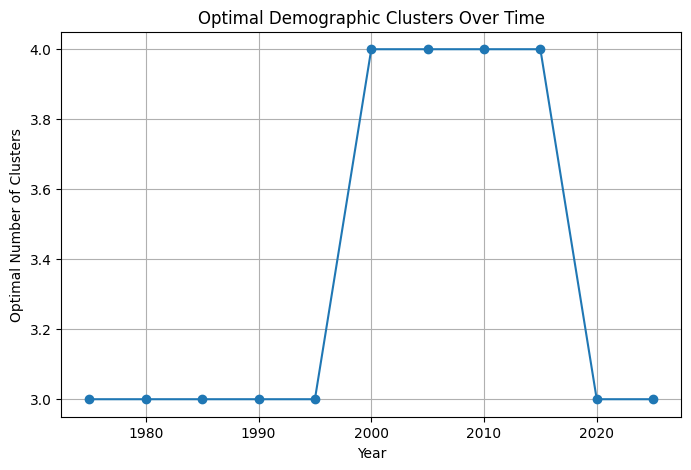

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import normalize
from sklearn.neighbors import kneighbors_graph

# =====================================================
# Spectral clustering of countries using population
# pyramids (21 age groups)
# Optimal number of clusters per year (1975–2025)
# =====================================================

CSV_PATH = "age_data_1.csv"
START_YEAR = 1975
END_YEAR = 2025
YEAR_STEP = 5

N_NEIGHBORS = 12       # kNN affinity (8–15 recommended)
MAX_EIGEN = 5       # eigenvalues inspected for eigengap
MIN_K = 2
MAX_K = 7             # plausible demographic range

# =========================
# LOAD DATA
# =========================
df = pd.read_csv(CSV_PATH)

years = sorted(
    y for y in df["Time"].unique()
    if START_YEAR <= y <= END_YEAR and (y - START_YEAR) % YEAR_STEP == 0
)

all_results = []
k_summary = []

# =========================
# LOOP OVER YEARS
# =========================
for YEAR in years:
    print(f"\nProcessing year: {YEAR}")

    df_year = df[df["Time"] == YEAR]
    if df_year.empty:
        print("No data, skipping.")
        continue

    # Country × age-group matrix
    df_pivot = df_year.pivot(
        index="Location",
        columns="AgeGrp",
        values="PopTotal"
    ).fillna(0)

    countries = df_pivot.index.values
    X = df_pivot.values

    assert X.shape[1] == 21, "Expected exactly 21 age groups"

    # =========================
    # NORMALIZE PYRAMIDS
    # =========================
    X = normalize(X, norm="l1")

    # =========================
    # kNN AFFINITY GRAPH
    # =========================
    W = kneighbors_graph(
        X,
        n_neighbors=N_NEIGHBORS,
        mode="connectivity",
        include_self=False
    )

    W = 0.5 * (W + W.T)
    W = W.toarray()

    # =========================
    # NORMALIZED LAPLACIAN
    # =========================
    degree = np.sum(W, axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(degree + 1e-10))
    L = np.eye(W.shape[0]) - D_inv_sqrt @ W @ D_inv_sqrt

    # =========================
    # EIGENGAP → OPTIMAL K
    # =========================
    eigenvals, _ = np.linalg.eigh(L)

    gaps = np.diff(eigenvals[:MAX_EIGEN])
    raw_k = np.argmax(gaps) + 1
    optimal_k = min(max(raw_k, MIN_K), MAX_K)

    print(f"Optimal number of clusters: {optimal_k}")

    k_summary.append({
        "Year": YEAR,
        "Optimal_K": optimal_k
    })

    # =========================
    # SPECTRAL CLUSTERING
    # =========================
    sc = SpectralClustering(
        n_clusters=optimal_k,
        affinity="nearest_neighbors",
        n_neighbors=N_NEIGHBORS,
        assign_labels="kmeans",
        random_state=42
    )

    labels = sc.fit_predict(X)

    year_results = pd.DataFrame({
        "Country": countries,
        "Year": YEAR,
        "Cluster": labels
    })

    all_results.append(year_results)

    print("Cluster sizes:")
    print(year_results["Cluster"].value_counts().sort_index())

# =========================
# SAVE RESULTS
# =========================
full_df = pd.concat(all_results, ignore_index=True)
full_df.to_csv("cluster_results_optimalK_1975_2025.csv", index=False)

k_df = pd.DataFrame(k_summary)
k_df.to_csv("optimal_k_by_year.csv", index=False)

print("\nSaved files:")
print("- cluster_results_optimalK_1975_2025.csv")
print("- optimal_k_by_year.csv")

# =========================
# PLOT OPTIMAL K OVER TIME
# =========================
plt.figure(figsize=(8,5))
plt.plot(k_df["Year"], k_df["Optimal_K"], marker="o")
plt.xlabel("Year")
plt.ylabel("Optimal Number of Clusters")
plt.title("Optimal Demographic Clusters Over Time")
plt.grid(True)
plt.show()


PCA - with countries spectral

PCA explained variance (2 components): 0.931


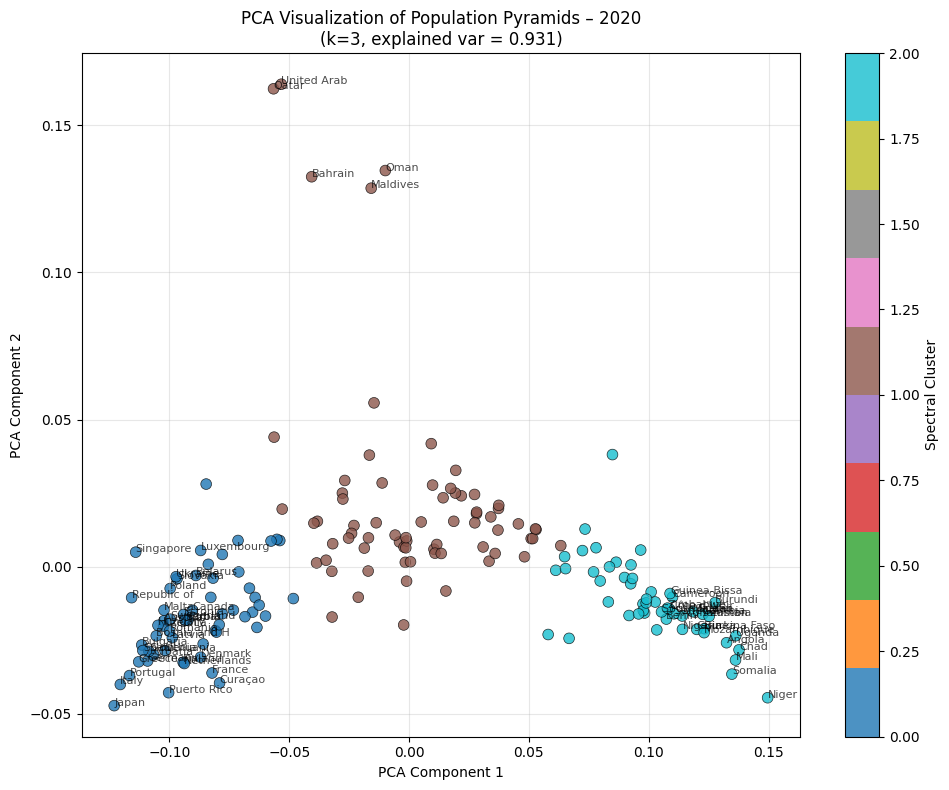


Cluster 0 (59 countries):
Albania, Armenia, Australia, Austria, Barbados, Belarus, Belgium, Bosnia and Herzegovina, Bulgaria, Canada, Chile, China, Croatia, Cuba, Curaçao ...

Cluster 1 (70 countries):
Algeria, Antigua and Barbuda, Argentina, Azerbaijan, Bahamas, Bahrain, Bangladesh, Belize, Bhutan, Bolivia (Plurinational State of), Botswana, Brazil, Brunei Darussalam, Cabo Verde, Cambodia ...

Cluster 2 (51 countries):
Afghanistan, Angola, Benin, Burkina Faso, Burundi, Cameroon, Chad, Comoros, Congo, Côte d'Ivoire, Equatorial Guinea, Eritrea, Eswatini, Ethiopia, Gabon ...


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import normalize
from sklearn.neighbors import kneighbors_graph
from sklearn.decomposition import PCA

# =====================================================
CSV_PATH = "age_data_1.csv"
YEAR = 2020
N_NEIGHBORS = 12
FIXED_K = 3

# Load & prepare
df = pd.read_csv(CSV_PATH)
df_year = df[df["Time"] == YEAR].copy()
df_pivot = df_year.pivot(index="Location", columns="AgeGrp", values="PopTotal").fillna(0)
countries = df_pivot.index.values
X = df_pivot.values
assert X.shape[1] == 21

# Normalize (L1 = proportions)
X_norm = normalize(X, norm="l1")

# Spectral clustering
W = kneighbors_graph(X_norm, n_neighbors=N_NEIGHBORS, mode="connectivity", include_self=False)
W = 0.5 * (W + W.T)
W = W.toarray()

degree = np.sum(W, axis=1)
D_inv_sqrt = np.diag(1.0 / np.sqrt(degree + 1e-10))
L = np.eye(W.shape[0]) - D_inv_sqrt @ W @ D_inv_sqrt

sc = SpectralClustering(
    n_clusters=FIXED_K,
    affinity="nearest_neighbors",
    n_neighbors=N_NEIGHBORS,
    assign_labels="kmeans",
    random_state=42
)
labels = sc.fit_predict(X_norm)

# -----------------------------
# PCA for visualization (2D)
# -----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_norm)

explained_var = pca.explained_variance_ratio_.sum()
print(f"PCA explained variance (2 components): {explained_var:.3f}")

# Plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=labels, cmap="tab10", s=60, alpha=0.8, edgecolor="k", linewidth=0.5
)

# Add country labels for interesting/outlier points (optional)
for i, country in enumerate(countries):
    if (X_pca[i, 0] > X_pca[:,0].max()*0.7 or X_pca[i, 1] > X_pca[:,1].max()*0.7 or
        X_pca[i, 0] < X_pca[:,0].min()*0.7 or X_pca[i, 1] < X_pca[:,1].min()*0.7):
        plt.annotate(country[:12], (X_pca[i, 0], X_pca[i, 1]), fontsize=8, alpha=0.7)

plt.colorbar(scatter, label="Spectral Cluster")
plt.title(f"PCA Visualization of Population Pyramids – {YEAR}\n"
          f"(k={FIXED_K}, explained var = {explained_var:.3f})")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Optional: print cluster → countries again
results = pd.DataFrame({"Country": countries, "Cluster": labels})
for cl in range(FIXED_K):
    cnts = results[results["Cluster"] == cl]["Country"].sort_values().tolist()
    print(f"\nCluster {cl} ({len(cnts)} countries):")
    print(", ".join(cnts[:15]) + " ..." if len(cnts) > 15 else ", ".join(cnts))

#Spectral clustering - PCA

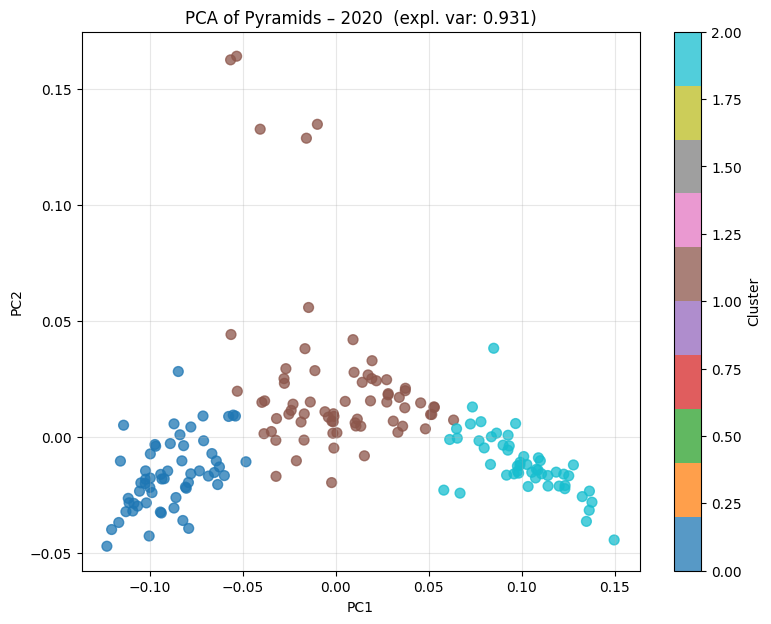

In [8]:
    # PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_norm)
    explained = pca.explained_variance_ratio_.sum()

    plt.figure(figsize=(9,7))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap="tab10", s=50, alpha=0.75)
    plt.title(f"PCA of Pyramids – {YEAR}  (expl. var: {explained:.3f})")
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.colorbar(label="Cluster")
    plt.grid(alpha=0.3)
    plt.savefig(f"pca_pyramids_{YEAR}.png", dpi=150, bbox_inches="tight")
    plt.show()   # or plt.show() if you want interactive


#Spectral clustering - UMAP

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


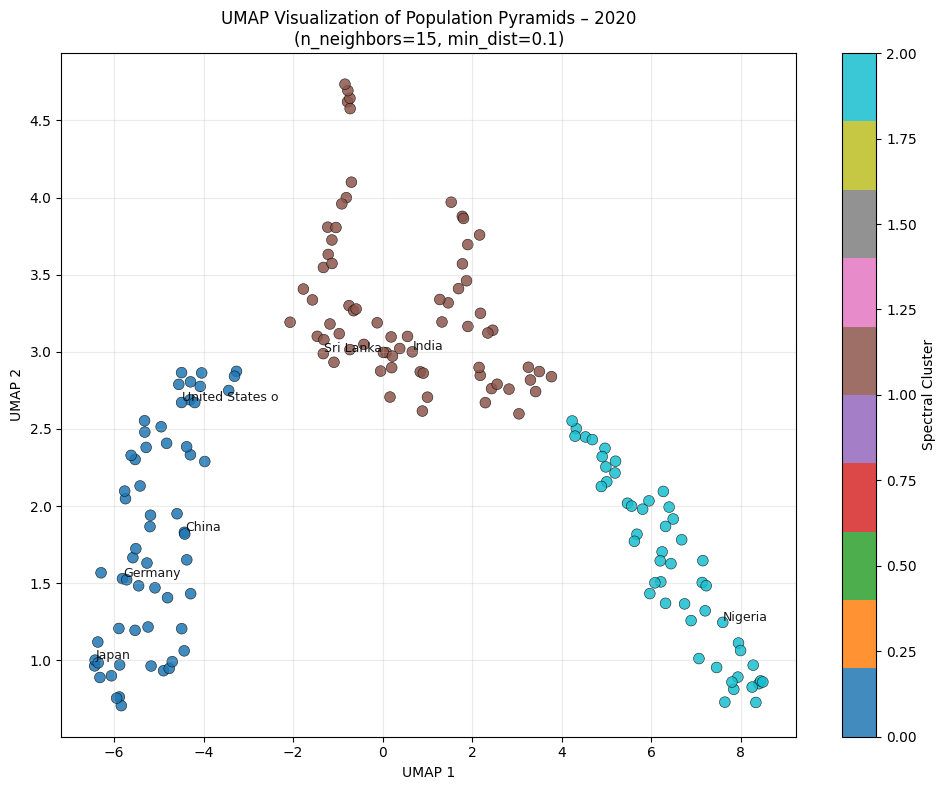

In [9]:
import umap  # ← add this import

# ... after you have X_norm (normalized pyramids) and labels from spectral clustering ...

# -----------------------------
# UMAP for visualization (2D)
# -----------------------------
umap_reducer = umap.UMAP(
    n_neighbors=15,          # similar scale to your spectral n_neighbors=12; try 5–30
    min_dist=0.1,            # how tightly points are packed; 0.0–0.5 common
    n_components=2,
    metric='euclidean',      # or 'cosine' if you prefer angle-based (good for proportions)
    random_state=42
)

X_umap = umap_reducer.fit_transform(X_norm)

# Explained variance isn't directly available in UMAP, but you can trust visual separation

# Plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_umap[:, 0], X_umap[:, 1],
    c=labels, cmap="tab10", s=60, alpha=0.85, edgecolor="k", linewidth=0.4
)

# Optional: label some outlier/representative countries
for i, country in enumerate(countries):
    # Label only extremes or countries you care about (e.g. Japan, Nigeria, India, Sri Lanka)
    if country in ["Japan", "Nigeria", "India", "China", "United States of America", "Sri Lanka", "Germany"]:
        plt.annotate(country[:15], (X_umap[i, 0]+0.01, X_umap[i, 1]+0.01), fontsize=9, alpha=0.9)

plt.colorbar(scatter, label="Spectral Cluster")
plt.title(f"UMAP Visualization of Population Pyramids – {YEAR}\n"
          f"(n_neighbors={umap_reducer.n_neighbors}, min_dist={umap_reducer.min_dist})")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [10]:
    umap_reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    X_umap = umap_reducer.fit_transform(X_norm)

    plt.figure(figsize=(9,7))
    plt.scatter(X_umap[:,0], X_umap[:,1], c=labels, cmap="tab10", s=50, alpha=0.8)
    plt.title(f"UMAP of Pyramids – {YEAR}")
    plt.xlabel("UMAP 1"); plt.ylabel("UMAP 2")
    plt.colorbar(label="Cluster")
    plt.grid(alpha=0.3)
    plt.savefig(f"umap_pyramids_{YEAR}.png", dpi=150, bbox_inches="tight")
    plt.close()  # or show() if interactive

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Data years range: 1950 to 2100
Processing years: [np.int64(1950), np.int64(1975), np.int64(2000), np.int64(2025)]


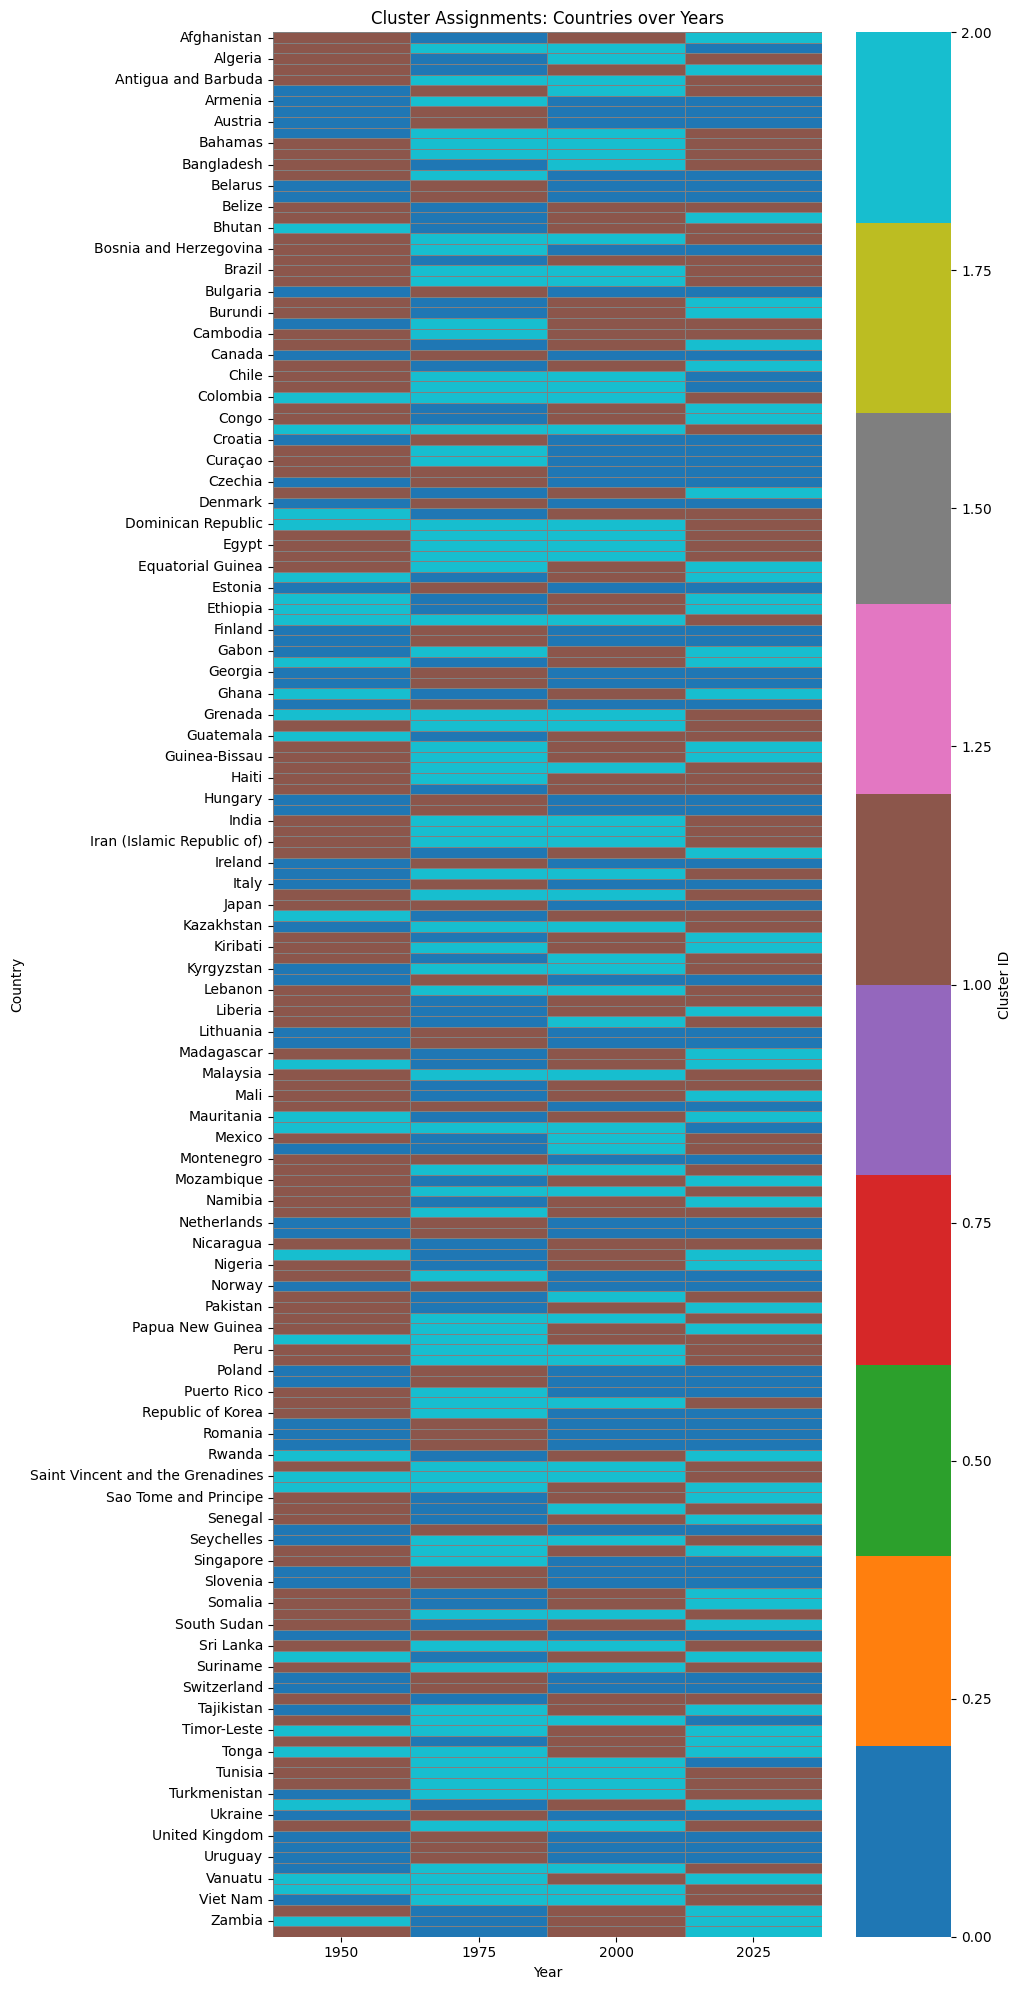

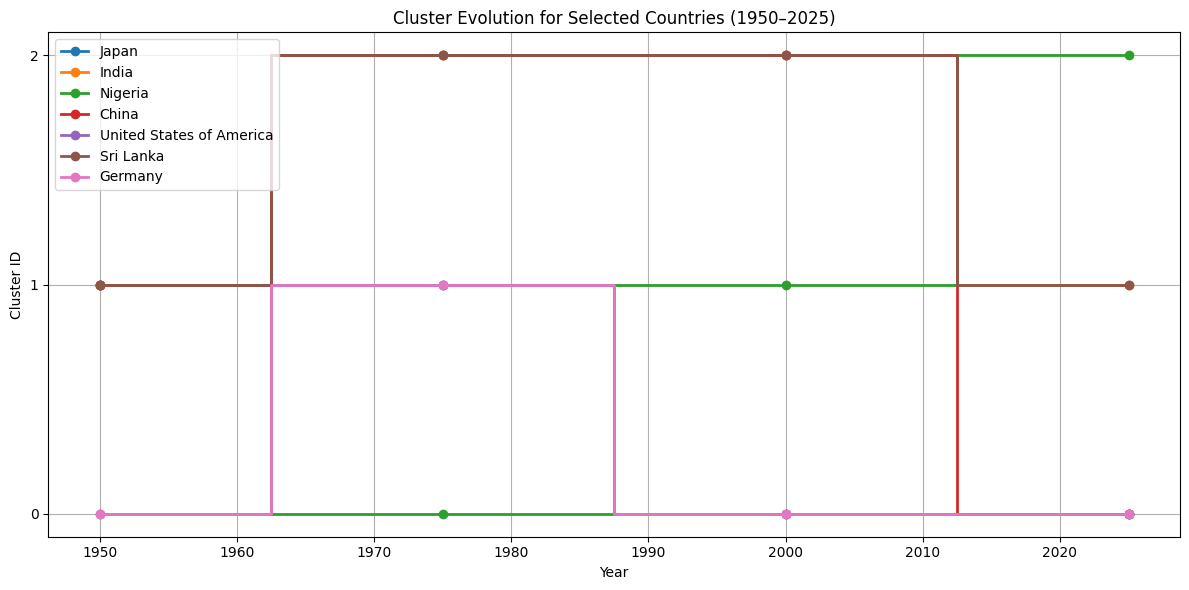


Japan cluster over years:
1950: Cluster 1
1975: Cluster 1
2000: Cluster 0
2025: Cluster 0

India cluster over years:
1950: Cluster 1
1975: Cluster 2
2000: Cluster 2
2025: Cluster 1

Nigeria cluster over years:
1950: Cluster 1
1975: Cluster 0
2000: Cluster 1
2025: Cluster 2


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import normalize
from sklearn.neighbors import kneighbors_graph
import seaborn as sns  # For heatmap

# =====================================================
# Spectral clustering over time, with 3D data view
# Treat data as country x year x age_group matrix
# Cluster per year independently, then visualize evolutions
# =====================================================
CSV_PATH = "age_data_1.csv"
YEAR_STEP = 25  # e.g., 1950, 1975, 2000, 2025 — adjust to 5 or 1 for denser
N_NEIGHBORS = 12
FIXED_K = 3
SELECTED_COUNTRIES = ["Japan", "India", "Nigeria", "China", "United States of America", "Sri Lanka", "Germany"]  # Add more as needed

# Load full data
df = pd.read_csv(CSV_PATH)
unique_years = sorted(df['Time'].unique())
min_year, max_year = min(unique_years), max(unique_years)
print(f"Data years range: {min_year} to {max_year}")

# Filter years: from 1950 to 2025, in steps
START_YEAR = max(1950, min_year)  # Auto-adjust if data starts later
END_YEAR = min(2025, max_year)
years = [y for y in unique_years if START_YEAR <= y <= END_YEAR and (y - START_YEAR) % YEAR_STEP == 0]
if END_YEAR not in years and END_YEAR in unique_years:  # Ensure end year included
    years.append(END_YEAR)
years = sorted(years)
print(f"Processing years: {years}")

all_results = []

for YEAR in years:
    df_year = df[df["Time"] == YEAR].copy()
    if df_year.empty:
        continue

    df_pivot = df_year.pivot(index="Location", columns="AgeGrp", values="PopTotal").fillna(0)
    countries = df_pivot.index.values
    X = df_pivot.values
    if X.shape[1] != 21:
        print(f"Skipping {YEAR}: incorrect age groups ({X.shape[1]})")
        continue

    X_norm = normalize(X, norm="l1")

    sc = SpectralClustering(
        n_clusters=FIXED_K,
        affinity="nearest_neighbors",
        n_neighbors=N_NEIGHBORS,
        assign_labels="kmeans",
        random_state=42
    )
    labels = sc.fit_predict(X_norm)

    year_results = pd.DataFrame({
        "Country": countries,
        "Year": YEAR,
        "Cluster": labels
    })
    all_results.append(year_results)

# Combine
full_df = pd.concat(all_results, ignore_index=True)
full_df.to_csv("cluster_results_1950_2025.csv", index=False)

# Pivot for country x year matrix (values = cluster)
pivot_df = full_df.pivot(index="Country", columns="Year", values="Cluster").fillna(-1).astype(int)  # -1 for missing
pivot_df.to_csv("cluster_pivot_1950_2025.csv")

# ==============================
# Visualize: Heatmap for all countries' cluster evolution
# ==============================
# Sort countries alphabetically or by some order (e.g., by 2025 cluster)
pivot_sorted = pivot_df.sort_index()  # or .sort_values(by=years[-1])

plt.figure(figsize=(10, 20))  # Tall for many countries
sns.heatmap(
    pivot_sorted,
    cmap="tab10",
    cbar_kws={'label': 'Cluster ID'},
    linewidths=0.5,
    linecolor='gray'
)
plt.title("Cluster Assignments: Countries over Years")
plt.xlabel("Year")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("cluster_heatmap_1950_2025.png", dpi=150)
plt.show()  # or close() if batch

# ==============================
# Visualize: Per-country cluster trajectories
# ==============================
# 3D matrix view: extract for selected countries
# But since clustering is per year, we plot cluster ID over time

fig, ax = plt.subplots(figsize=(12, 6))
for country in SELECTED_COUNTRIES:
    if country in pivot_df.index:
        cluster_path = pivot_df.loc[country].values
        ax.step(years, cluster_path, where='mid', label=country, linewidth=2, marker='o')
    else:
        print(f"{country} not found in data")

ax.set_title("Cluster Evolution for Selected Countries (1950–2025)")
ax.set_xlabel("Year")
ax.set_ylabel("Cluster ID")
ax.set_yticks(range(FIXED_K))
ax.grid(True)
ax.legend(loc='best')
plt.tight_layout()
plt.savefig("cluster_trajectories_selected.png", dpi=150)
plt.show()

# Optional: Print transitions for a specific country
def print_country_clusters(country):
    if country in pivot_df.index:
        print(f"\n{country} cluster over years:")
        for y, cl in zip(years, pivot_df.loc[country]):
            print(f"{y}: Cluster {cl}")
    else:
        print(f"{country} not in data")

# Example usage
print_country_clusters("Japan")
print_country_clusters("India")
print_country_clusters("Nigeria")

#HIerarchical for 2020

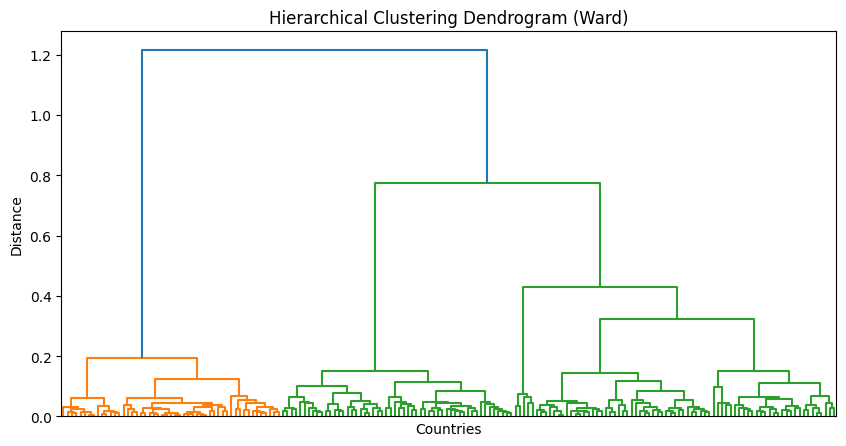

               Country  Cluster
0          Afghanistan        0
3               Angola        0
31                Chad        0
29            Cameroon        0
25        Burkina Faso        0
26             Burundi        0
17               Benin        0
62               Ghana        0
51             Eritrea        0
50   Equatorial Guinea        0
54            Ethiopia        0
53            Eswatini        0
58               Gabon        0
43       Côte d'Ivoire        0
36               Congo        0
35             Comoros        0
59              Gambia        0
97              Malawi        0
102         Mauritania        0
100               Mali        0
108         Mozambique        0
110            Namibia        0
116            Nigeria        0
115              Niger        0
120           Pakistan        0
122   Papua New Guinea        0
92             Liberia        0
85               Kenya        0
86            Kiribati        0
77                Iraq        0

Cluster

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import normalize
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# =====================================================
# Hierarchical clustering (Ward) of countries using
# population pyramids (21 age groups)
# =====================================================

CSV_PATH = "age_data_1.csv"
YEAR = 2020
N_CLUSTERS = None    # set to None to inspect dendrogram first

# =========================
# LOAD DATA
# =========================
df = pd.read_csv(CSV_PATH)
df_year = df[df["Time"] == YEAR].copy()

df_pivot = df_year.pivot(
    index="Location",
    columns="AgeGrp",
    values="PopTotal"
).fillna(0)

countries = df_pivot.index.values
X = df_pivot.values

assert X.shape[1] == 21, "Must have exactly 21 age groups"

# =========================
# NORMALIZE PYRAMIDS
# =========================
X = normalize(X, norm="l1")

# =========================
# HIERARCHICAL LINKAGE (WARD)
# =========================
Z = linkage(X, method="ward")

# =========================
# DENDROGRAM
# =========================
plt.figure(figsize=(10, 5))
dendrogram(
    Z,
    no_labels=True,
    color_threshold=None
)
plt.title("Hierarchical Clustering Dendrogram (Ward)")
plt.xlabel("Countries")
plt.ylabel("Distance")
plt.show()

# =========================
# CHOOSE NUMBER OF CLUSTERS
# =========================
# After inspecting the dendrogram, set N_CLUSTERS (usually 4–6)
if N_CLUSTERS is None:
    N_CLUSTERS = 5   # sensible demographic choice

# =========================
# FINAL CLUSTERING
# =========================
hc = AgglomerativeClustering(
    n_clusters=N_CLUSTERS,
    linkage="ward"
)

labels = hc.fit_predict(X)

# =========================
# OUTPUT
# =========================
results = pd.DataFrame({
    "Country": countries,
    "Cluster": labels
}).sort_values("Cluster")

print(results.head(30))
print("\nCluster sizes:")
print(results["Cluster"].value_counts().sort_index())


#HIerarchical clustering

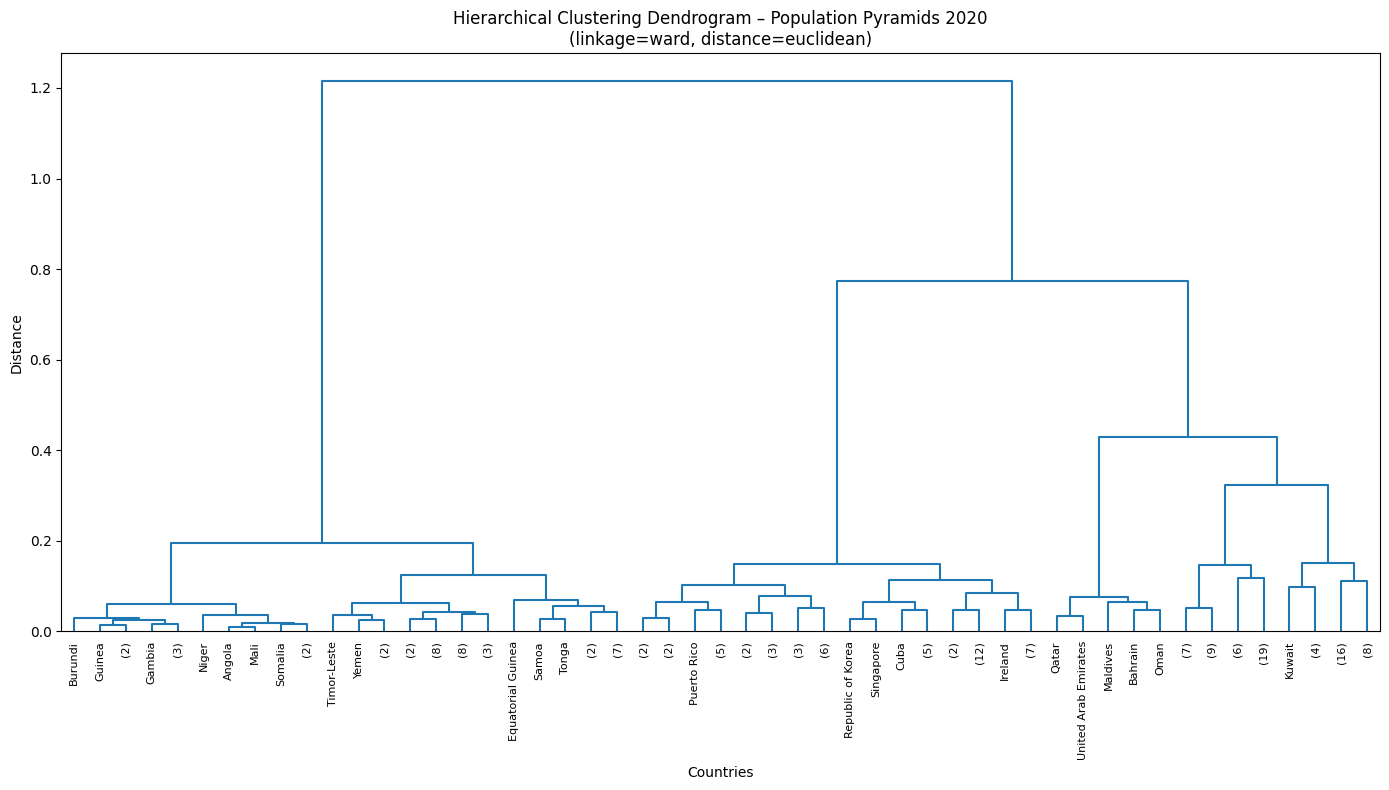

Cluster sizes:
Cluster
0    51
1    54
2    75
Name: count, dtype: int64

Cluster 0 (51 countries):
Afghanistan, Angola, Chad, Cameroon, Burkina Faso, Burundi, Benin, Ghana, Eritrea, Equatorial Guinea, Ethiopia, Eswatini, Gabon, Côte d'Ivoire, Congo, Comoros, Gambia, Malawi, Mauritania, Mali, Mozambique, Namibia, Nigeria, Niger, Pakistan, Papua New Guinea, Liberia, Kenya, Kiribati, Iraq, Guinea-Bissau, Guinea, Madagascar, Togo, Tonga, Uganda, Vanuatu, Zimbabwe, Tajikistan, Sudan, Solomon Islands, Somalia, South Sudan, Senegal, Samoa, Sao Tome and Principe, Zambia, Yemen, Timor-Leste, Rwanda, Sierra Leone

Cluster 1 (54 countries):
Georgia, Greece, Estonia, Germany, France, Hungary, Iceland, North Macedonia, Norway, Montenegro, New Zealand, Latvia, Japan, Netherlands, Ireland, Lithuania, Luxembourg, Italy, Poland, Portugal, Thailand, Uruguay, United Kingdom, Singapore, Slovenia, Sweden, Switzerland, Malta, Mauritius, Finland, Curaçao, China, Cuba, Croatia, Denmark, Czechia, Albania, Can

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, leaves_list
from scipy.spatial.distance import pdist

# =====================================================
# Hierarchical clustering of population pyramids
# =====================================================
CSV_PATH = "age_data_1.csv"
YEAR = 2020          # change as needed
LINKAGE = 'ward'     # 'ward', 'average', 'complete', 'single'
DIST_METRIC = 'euclidean'  # 'euclidean', 'cosine', 'cityblock' also good for proportions
DESIRED_K = 3        # for assignment (can change or ignore)

# Load & prepare
df = pd.read_csv(CSV_PATH)
df_year = df[df["Time"] == YEAR].copy()
df_pivot = df_year.pivot(index="Location", columns="AgeGrp", values="PopTotal").fillna(0)
countries = df_pivot.index.values
X = df_pivot.values
assert X.shape[1] == 21

# Normalize to proportions
X_norm = normalize(X, norm="l1")

# Compute pairwise distances
dist_matrix = pdist(X_norm, metric=DIST_METRIC)

# Hierarchical clustering
Z = linkage(dist_matrix, method=LINKAGE)

# -----------------------------
# 1. Dendrogram (visual tree)
# -----------------------------
plt.figure(figsize=(14, 8))
dend = dendrogram(
    Z,
    labels=countries,
    leaf_rotation=90,
    leaf_font_size=8,
    truncate_mode='level', p=5,   # truncate deep dendrogram (optional)
    color_threshold=0             # color branches by cluster level
)
plt.title(f"Hierarchical Clustering Dendrogram – Population Pyramids {YEAR}\n"
          f"(linkage={LINKAGE}, distance={DIST_METRIC})")
plt.xlabel("Countries")
plt.ylabel("Distance")
plt.tight_layout()
plt.savefig(f"dendrogram_{YEAR}_{LINKAGE}.png", dpi=180, bbox_inches="tight")
plt.show()

# -----------------------------
# 2. Cut dendrogram at desired k and get labels
# -----------------------------
labels = fcluster(Z, t=DESIRED_K, criterion='maxclust')

# Results DataFrame
results = pd.DataFrame({
    "Country": countries,
    "Cluster": labels - 1   # make clusters 0,1,2,... instead of 1,2,3,...
}).sort_values("Cluster")

print("Cluster sizes:")
print(results["Cluster"].value_counts().sort_index())

# Print countries per cluster (sorted)
for cl in sorted(results["Cluster"].unique()):
    cnts = results[results["Cluster"] == cl]["Country"].tolist()
    print(f"\nCluster {cl} ({len(cnts)} countries):")
    print(", ".join(cnts))

# Optional: Reorder countries by dendrogram leaves for better heatmap
leaf_order = countries[leaves_list(Z)]

In [14]:
    dist_matrix = pdist(X_norm, metric='euclidean')
    Z = linkage(dist_matrix, method='ward')

    # Dendrogram per year (can be many — maybe save only every 10 years or selected)
    if YEAR in [1950, 1975, 2000, 2025]:  # or remove condition
        plt.figure(figsize=(14, 8))
        dendrogram(Z, labels=countries, leaf_rotation=90, truncate_mode='level', p=4)
        plt.title(f"Dendrogram – {YEAR} (ward)")
        plt.savefig(f"dendrogram_{YEAR}.png", dpi=150)
        plt.close()

    # Get fixed k=3 clusters
    labels = fcluster(Z, t=3, criterion='maxclust') - 1

    year_results = pd.DataFrame({
        "Country": countries,
        "Year": YEAR,
        "Cluster": labels
    })
    all_results.append(year_results)

# Spectral clustering - 1950-2100 graphs

Found 151 years between 1950 and 2100: [np.int64(1950), np.int64(1951), np.int64(1952), np.int64(1953), np.int64(1954)] ... [np.int64(2096), np.int64(2097), np.int64(2098), np.int64(2099), np.int64(2100)]

Year: 1950


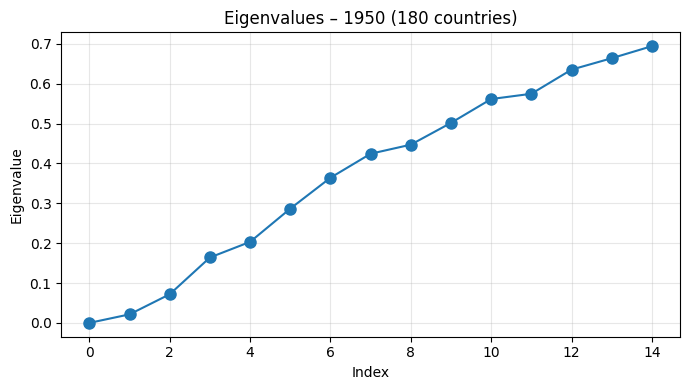

  Eigenvalues[:15]: [0.     0.0214 0.0719 0.1641 0.2032 0.2866 0.3641 0.4243 0.447  0.5017
 0.5615 0.5746 0.6352 0.6638 0.6941]
  Gaps: [0.0214 0.0504 0.0922 0.0392 0.0834 0.0775 0.0602 0.0227 0.0547 0.0598
 0.0132 0.0606 0.0286 0.0302]
  → Optimal number of clusters (eigengap): **3**
  Cluster sizes: [54 93 33]

Year: 1951


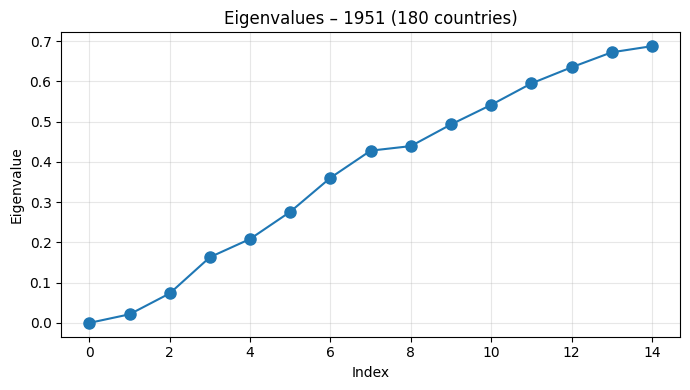

  Eigenvalues[:15]: [-0.      0.0213  0.0733  0.1633  0.2085  0.2761  0.3606  0.4279  0.4393
  0.4931  0.5417  0.595   0.6351  0.6723  0.6876]
  Gaps: [0.0213 0.052  0.09   0.0452 0.0676 0.0844 0.0674 0.0113 0.0538 0.0487
 0.0532 0.0401 0.0373 0.0153]
  → Optimal number of clusters (eigengap): **3**
  Cluster sizes: [53 94 33]

Year: 1952


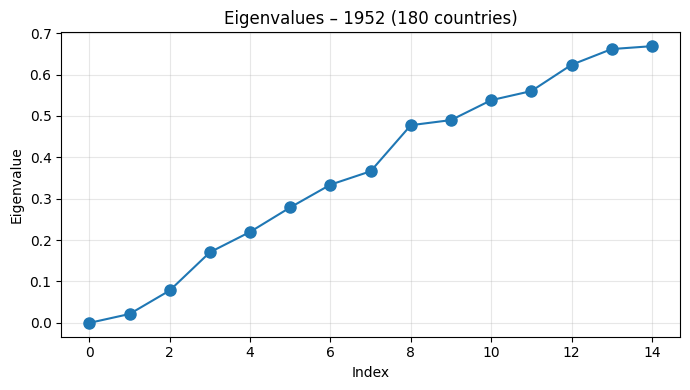

  Eigenvalues[:15]: [-0.      0.0215  0.0783  0.1707  0.2199  0.2791  0.334   0.3663  0.4777
  0.49    0.5381  0.5601  0.6236  0.6616  0.6686]
  Gaps: [0.0215 0.0568 0.0924 0.0492 0.0592 0.0549 0.0323 0.1113 0.0123 0.0481
 0.022  0.0635 0.038  0.007 ]
  → Optimal number of clusters (eigengap): **8**
  Cluster sizes: [17 18 37 12 33 27 11 25]

Year: 1953


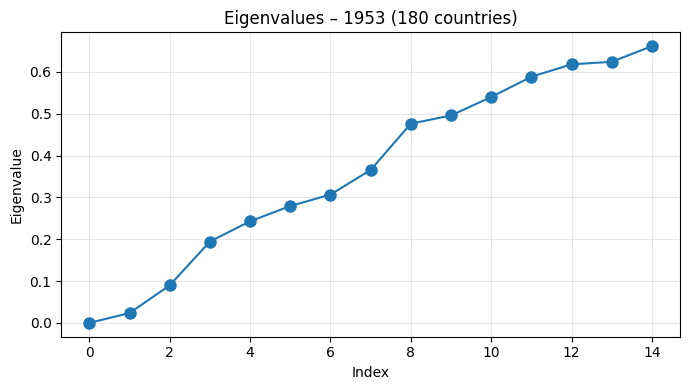

  Eigenvalues[:15]: [-0.      0.0235  0.0899  0.1945  0.2428  0.2792  0.3067  0.3654  0.4761
  0.4958  0.5399  0.5882  0.6179  0.624   0.6614]
  Gaps: [0.0235 0.0664 0.1046 0.0483 0.0364 0.0276 0.0586 0.1107 0.0196 0.0441
 0.0484 0.0297 0.0061 0.0374]
  → Optimal number of clusters (eigengap): **8**
  Cluster sizes: [25 18 28 37 12 24 10 26]

Year: 1954


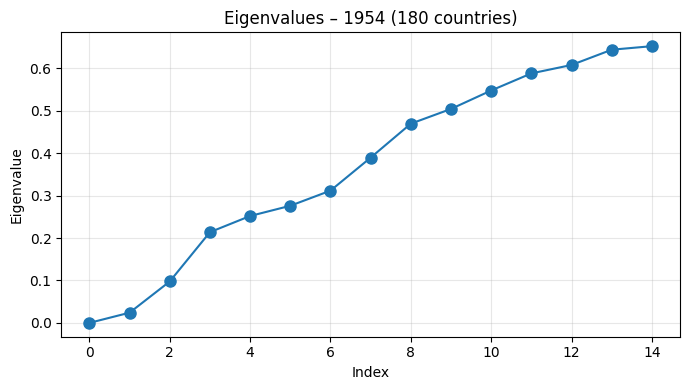

  Eigenvalues[:15]: [0.     0.024  0.0976 0.2138 0.2519 0.276  0.3116 0.3894 0.4694 0.5041
 0.5476 0.5879 0.6077 0.6437 0.652 ]
  Gaps: [0.024  0.0736 0.1162 0.0381 0.0241 0.0356 0.0778 0.08   0.0348 0.0434
 0.0403 0.0198 0.0359 0.0084]
  → Optimal number of clusters (eigengap): **3**
  Cluster sizes: [43 77 60]

Year: 1955


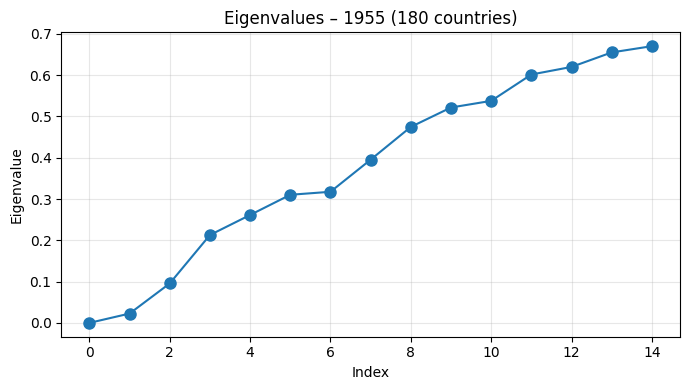

  Eigenvalues[:15]: [0.     0.0226 0.0956 0.2128 0.2614 0.3104 0.3176 0.3954 0.4747 0.5218
 0.5378 0.6017 0.6201 0.6552 0.6703]
  Gaps: [0.0226 0.073  0.1172 0.0486 0.0489 0.0072 0.0778 0.0794 0.047  0.0161
 0.0638 0.0184 0.0352 0.0151]
  → Optimal number of clusters (eigengap): **3**
  Cluster sizes: [80 43 57]

Year: 1956


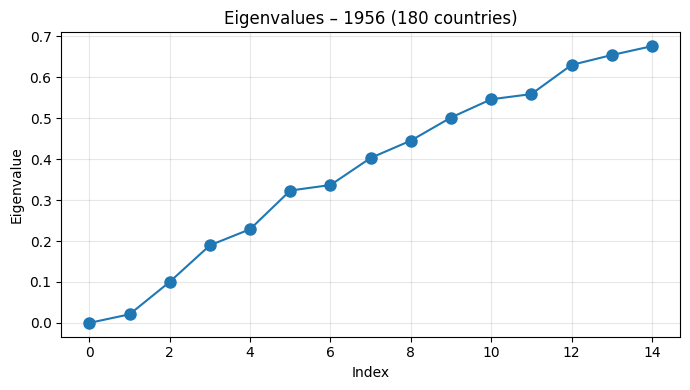

  Eigenvalues[:15]: [-0.      0.0209  0.1003  0.1896  0.2289  0.3233  0.3368  0.4029  0.4452
  0.5017  0.5462  0.5589  0.63    0.6542  0.676 ]
  Gaps: [0.0209 0.0793 0.0893 0.0393 0.0945 0.0134 0.0661 0.0423 0.0564 0.0446
 0.0127 0.0711 0.0242 0.0217]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [15 43 41 49 32]

Year: 1957


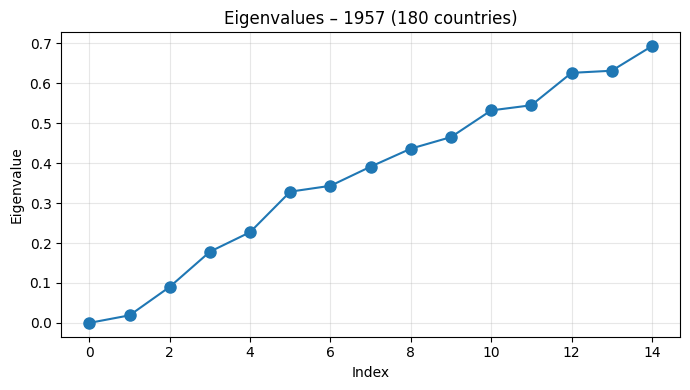

  Eigenvalues[:15]: [0.     0.0189 0.0903 0.1784 0.2273 0.3288 0.3434 0.3914 0.4365 0.4655
 0.5323 0.5452 0.6264 0.6317 0.6932]
  Gaps: [0.0189 0.0713 0.0881 0.0489 0.1015 0.0146 0.048  0.0451 0.029  0.0668
 0.0129 0.0811 0.0053 0.0616]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [15 50 40 32 43]

Year: 1958


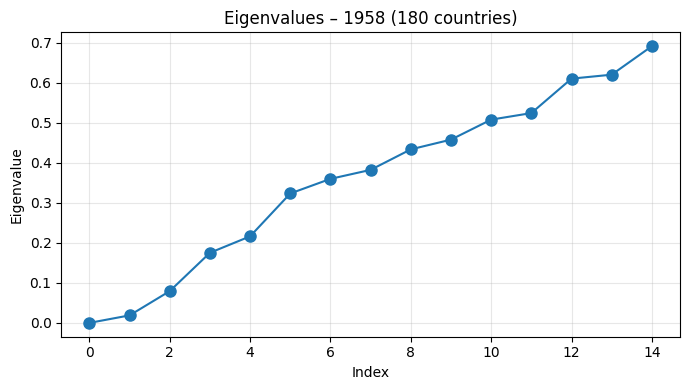

  Eigenvalues[:15]: [0.     0.0188 0.0795 0.1753 0.2165 0.3236 0.3602 0.3827 0.434  0.4583
 0.5083 0.5247 0.6108 0.6207 0.692 ]
  Gaps: [0.0188 0.0607 0.0958 0.0411 0.1072 0.0366 0.0225 0.0513 0.0243 0.05
 0.0164 0.0861 0.0099 0.0713]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [32 42 49 15 42]

Year: 1959


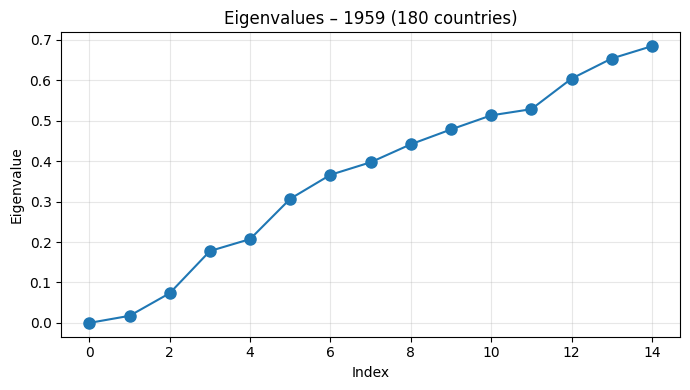

  Eigenvalues[:15]: [0.     0.0175 0.0735 0.1778 0.2073 0.3071 0.3663 0.3973 0.4418 0.4786
 0.5134 0.5287 0.6042 0.654  0.6846]
  Gaps: [0.0175 0.056  0.1042 0.0295 0.0998 0.0593 0.031  0.0445 0.0367 0.0348
 0.0153 0.0755 0.0498 0.0305]
  → Optimal number of clusters (eigengap): **3**
  Cluster sizes: [94 44 42]

Year: 1960


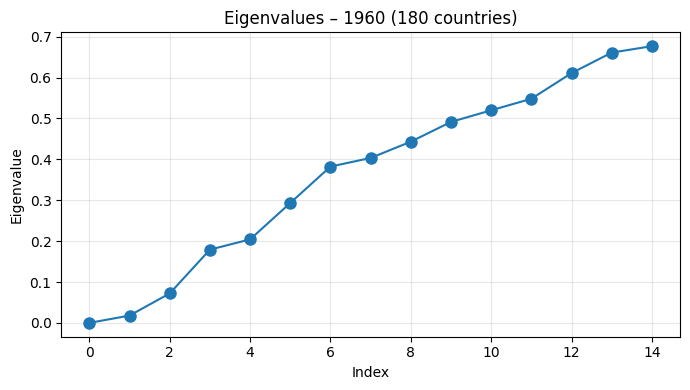

  Eigenvalues[:15]: [0.     0.018  0.0721 0.1792 0.2043 0.2933 0.3823 0.4034 0.4432 0.4915
 0.5199 0.5482 0.6109 0.6611 0.6768]
  Gaps: [0.018  0.0542 0.1071 0.0251 0.089  0.089  0.0211 0.0398 0.0483 0.0284
 0.0283 0.0627 0.0502 0.0157]
  → Optimal number of clusters (eigengap): **3**
  Cluster sizes: [44 96 40]

Year: 1961


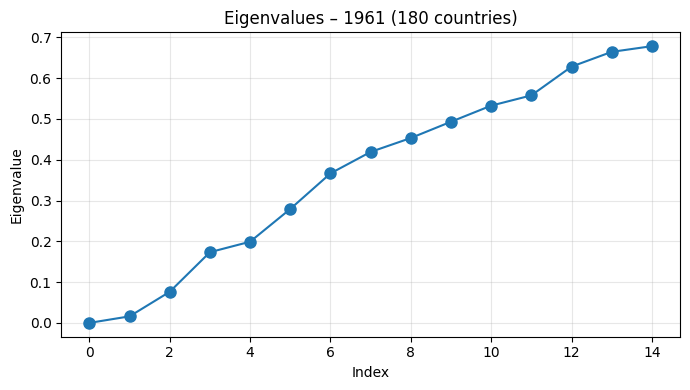

  Eigenvalues[:15]: [0.     0.016  0.0763 0.1733 0.199  0.2793 0.3665 0.4192 0.4533 0.4932
 0.5326 0.5578 0.6283 0.6646 0.6785]
  Gaps: [0.016  0.0603 0.097  0.0257 0.0803 0.0872 0.0527 0.0341 0.0399 0.0394
 0.0252 0.0705 0.0363 0.0139]
  → Optimal number of clusters (eigengap): **3**
  Cluster sizes: [44 95 41]

Year: 1962


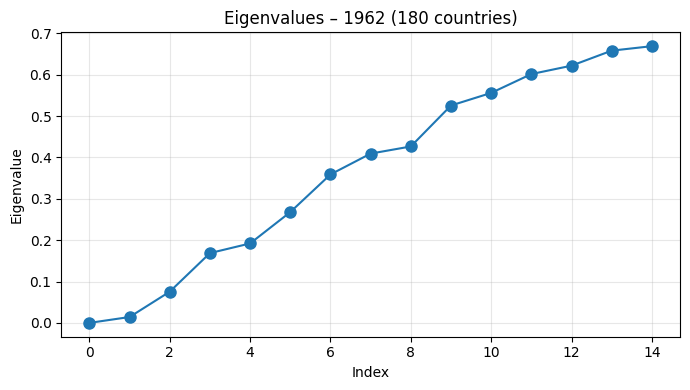

  Eigenvalues[:15]: [-0.      0.0142  0.0755  0.1687  0.1921  0.2679  0.3589  0.4094  0.4266
  0.5256  0.5561  0.6016  0.6219  0.6583  0.6691]
  Gaps: [0.0142 0.0613 0.0933 0.0234 0.0758 0.091  0.0504 0.0172 0.099  0.0305
 0.0456 0.0203 0.0363 0.0108]
  → Optimal number of clusters (eigengap): **9**
  Cluster sizes: [15 29 22 23 18 14 13 15 31]

Year: 1963


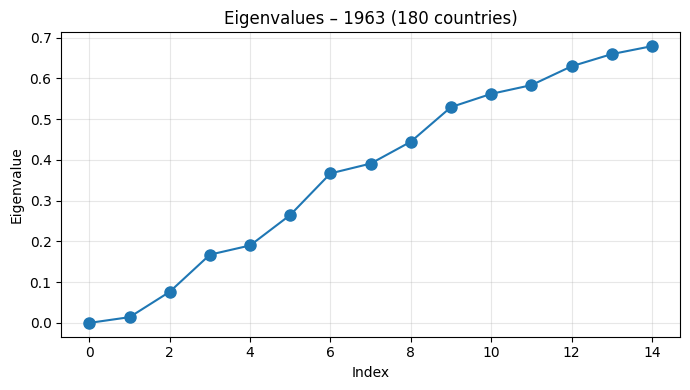

  Eigenvalues[:15]: [-0.      0.0141  0.0764  0.1675  0.1901  0.265   0.367   0.391   0.4448
  0.5297  0.5622  0.5836  0.6299  0.6598  0.6793]
  Gaps: [0.0141 0.0623 0.0911 0.0226 0.0749 0.1019 0.0241 0.0537 0.0849 0.0325
 0.0215 0.0462 0.0299 0.0195]
  → Optimal number of clusters (eigengap): **6**
  Cluster sizes: [43 36 30 40 15 16]

Year: 1964


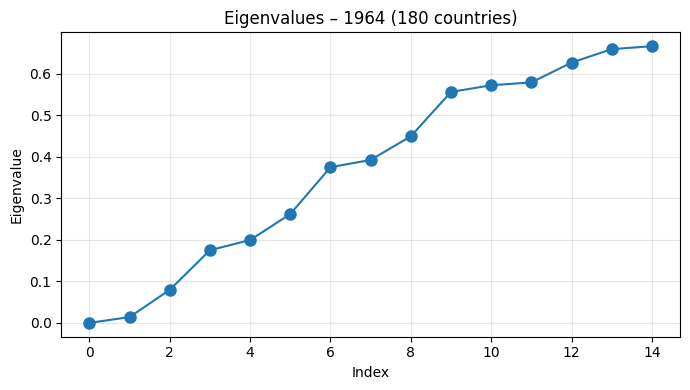

  Eigenvalues[:15]: [-0.      0.014   0.0796  0.175   0.1996  0.2621  0.375   0.3924  0.4494
  0.5562  0.5724  0.5792  0.627   0.6592  0.6665]
  Gaps: [0.014  0.0656 0.0954 0.0245 0.0625 0.1129 0.0174 0.057  0.1068 0.0162
 0.0068 0.0478 0.0323 0.0073]
  → Optimal number of clusters (eigengap): **6**
  Cluster sizes: [38 42 16 30 16 38]

Year: 1965


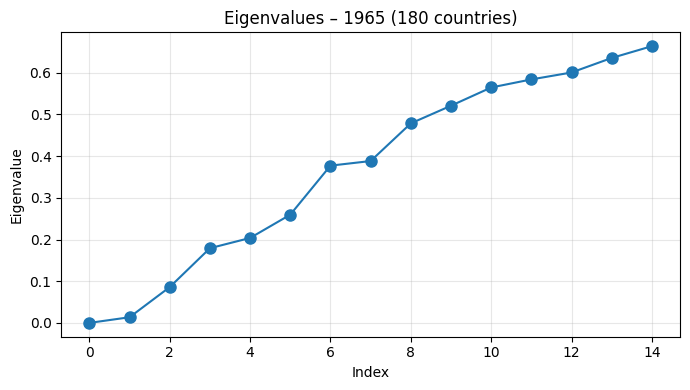

  Eigenvalues[:15]: [0.     0.0135 0.0859 0.1792 0.2038 0.2596 0.3772 0.3883 0.4786 0.521
 0.5647 0.5841 0.6007 0.6356 0.6638]
  Gaps: [0.0135 0.0724 0.0932 0.0246 0.0559 0.1176 0.011  0.0903 0.0424 0.0437
 0.0194 0.0166 0.0349 0.0283]
  → Optimal number of clusters (eigengap): **6**
  Cluster sizes: [44 30 33 16 16 41]

Year: 1966


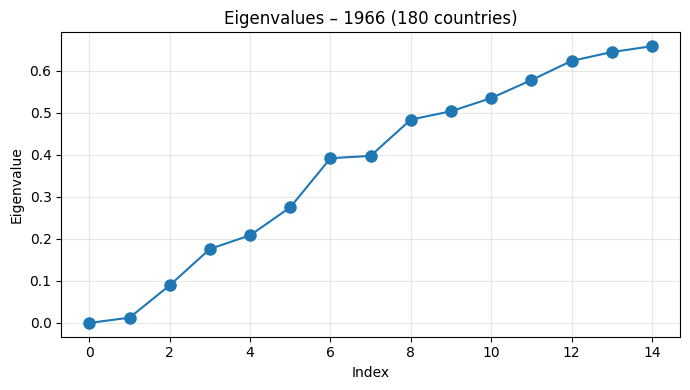

  Eigenvalues[:15]: [0.     0.0124 0.0895 0.1759 0.2083 0.2749 0.3915 0.3972 0.4834 0.5032
 0.5345 0.5774 0.623  0.6439 0.658 ]
  Gaps: [0.0124 0.0771 0.0864 0.0324 0.0666 0.1166 0.0057 0.0862 0.0198 0.0313
 0.0428 0.0456 0.0209 0.0141]
  → Optimal number of clusters (eigengap): **6**
  Cluster sizes: [18 43 36 38 16 29]

Year: 1967


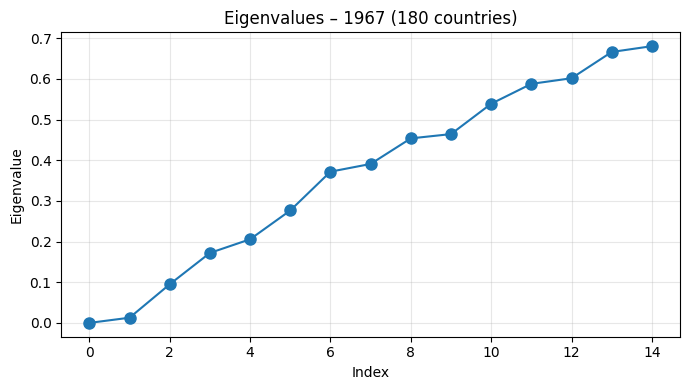

  Eigenvalues[:15]: [0.     0.0128 0.095  0.1721 0.2057 0.2766 0.372  0.391  0.4539 0.4644
 0.5391 0.588  0.6019 0.6665 0.6807]
  Gaps: [0.0128 0.0823 0.0771 0.0336 0.0709 0.0954 0.019  0.0629 0.0105 0.0747
 0.0489 0.0138 0.0646 0.0143]
  → Optimal number of clusters (eigengap): **6**
  Cluster sizes: [20 43 37 27 36 17]

Year: 1968


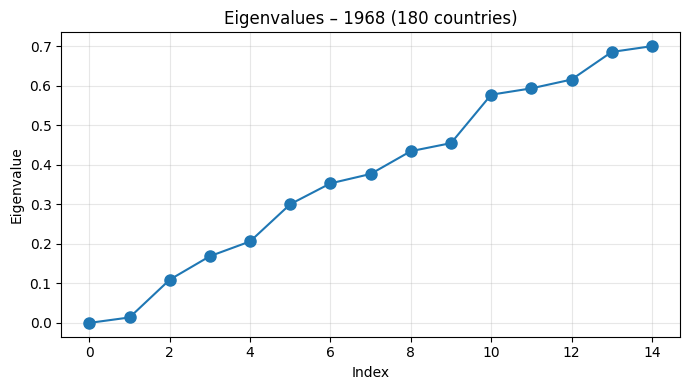

  Eigenvalues[:15]: [-0.      0.0138  0.1094  0.1688  0.2062  0.3004  0.3531  0.3768  0.4345
  0.4549  0.5774  0.5934  0.6158  0.6856  0.7002]
  Gaps: [0.0138 0.0956 0.0594 0.0373 0.0943 0.0526 0.0238 0.0577 0.0203 0.1226
 0.016  0.0223 0.0698 0.0146]
  → Optimal number of clusters (eigengap): **10**
  Cluster sizes: [16 21 17 22 18 17 14 19 19 17]

Year: 1969


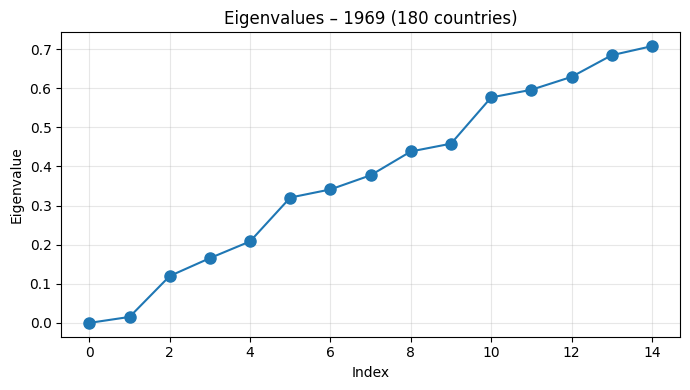

  Eigenvalues[:15]: [0.     0.0153 0.1199 0.1657 0.2085 0.3206 0.3413 0.3775 0.4384 0.4584
 0.5766 0.5962 0.6292 0.6846 0.7077]
  Gaps: [0.0153 0.1047 0.0457 0.0428 0.1121 0.0208 0.0362 0.0609 0.0199 0.1183
 0.0196 0.033  0.0554 0.0231]
  → Optimal number of clusters (eigengap): **10**
  Cluster sizes: [17 22 14 16 22 15 14 20 16 24]

Year: 1970


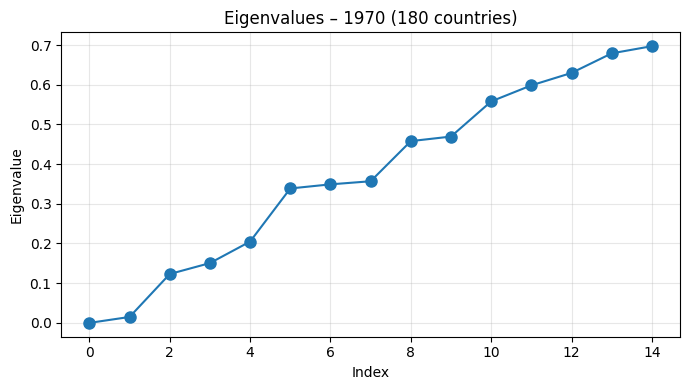

  Eigenvalues[:15]: [-0.      0.0149  0.1231  0.1506  0.2049  0.3387  0.349   0.3568  0.4579
  0.4694  0.5579  0.5984  0.6297  0.679   0.6971]
  Gaps: [0.0149 0.1082 0.0275 0.0542 0.1338 0.0103 0.0078 0.1011 0.0115 0.0885
 0.0405 0.0313 0.0494 0.0181]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [40 48 26 41 25]

Year: 1971


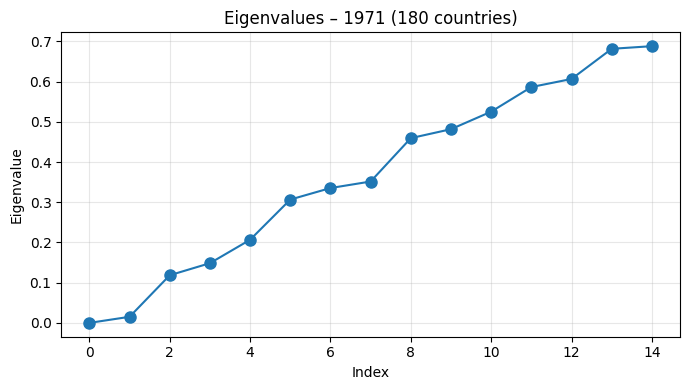

  Eigenvalues[:15]: [-0.      0.0151  0.1185  0.1485  0.2067  0.3067  0.3353  0.3516  0.4594
  0.4817  0.5253  0.5865  0.6066  0.6816  0.6881]
  Gaps: [0.0151 0.1034 0.03   0.0583 0.1    0.0286 0.0162 0.1079 0.0223 0.0436
 0.0612 0.0201 0.075  0.0066]
  → Optimal number of clusters (eigengap): **8**
  Cluster sizes: [24 29 20 25 21 21 22 18]

Year: 1972


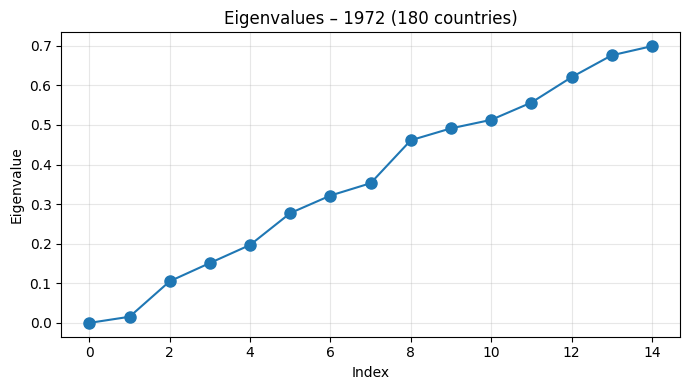

  Eigenvalues[:15]: [0.     0.0155 0.1052 0.1513 0.1969 0.2773 0.3217 0.3529 0.4614 0.4914
 0.5129 0.5565 0.6206 0.6759 0.699 ]
  Gaps: [0.0155 0.0897 0.0461 0.0456 0.0805 0.0443 0.0312 0.1085 0.03   0.0215
 0.0437 0.064  0.0553 0.0231]
  → Optimal number of clusters (eigengap): **8**
  Cluster sizes: [19 35 23 17 25 21 19 21]

Year: 1973


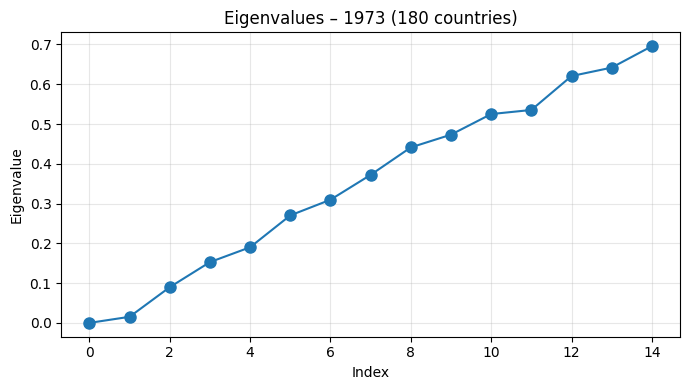

  Eigenvalues[:15]: [-0.      0.0153  0.0898  0.1528  0.1902  0.2703  0.3096  0.3722  0.4412
  0.4733  0.5251  0.5354  0.6207  0.6419  0.6958]
  Gaps: [0.0153 0.0745 0.063  0.0373 0.0801 0.0394 0.0626 0.069  0.032  0.0518
 0.0103 0.0853 0.0212 0.0539]
  → Optimal number of clusters (eigengap): **12**
  Cluster sizes: [16 16 21 21 19 13  9 10 15 11 14 15]

Year: 1974


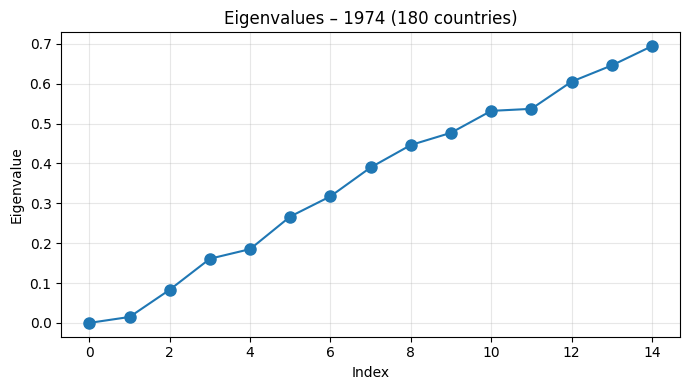

  Eigenvalues[:15]: [-0.      0.0149  0.0832  0.161   0.1851  0.2669  0.3175  0.39    0.4463
  0.4769  0.5319  0.537   0.6051  0.6458  0.6942]
  Gaps: [0.0149 0.0683 0.0778 0.0241 0.0818 0.0506 0.0725 0.0563 0.0306 0.055
 0.0051 0.0682 0.0407 0.0484]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [33 28 28 58 33]

Year: 1975


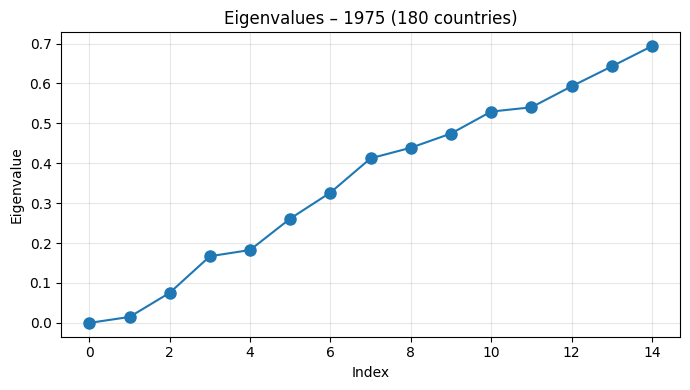

  Eigenvalues[:15]: [0.     0.0149 0.0755 0.167  0.1827 0.2615 0.3266 0.4124 0.4389 0.4745
 0.5295 0.5402 0.5927 0.6426 0.6935]
  Gaps: [0.0149 0.0606 0.0915 0.0156 0.0788 0.0651 0.0858 0.0265 0.0356 0.055
 0.0107 0.0525 0.0499 0.0508]
  → Optimal number of clusters (eigengap): **3**
  Cluster sizes: [44 76 60]

Year: 1976


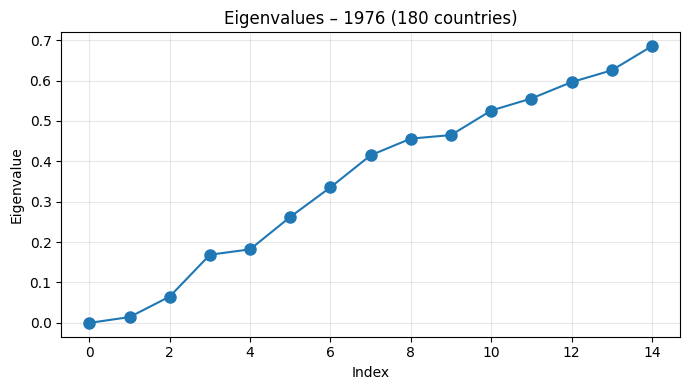

  Eigenvalues[:15]: [0.     0.0144 0.0652 0.1687 0.1821 0.2624 0.3356 0.4149 0.4562 0.4649
 0.5256 0.5555 0.596  0.6252 0.685 ]
  Gaps: [0.0144 0.0508 0.1036 0.0134 0.0803 0.0732 0.0794 0.0412 0.0087 0.0607
 0.0298 0.0405 0.0292 0.0598]
  → Optimal number of clusters (eigengap): **3**
  Cluster sizes: [45 75 60]

Year: 1977


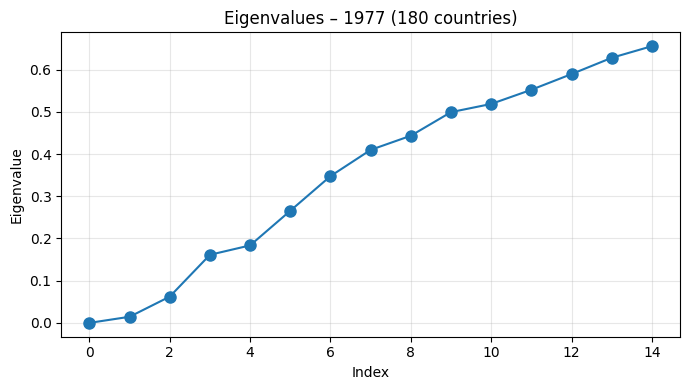

  Eigenvalues[:15]: [0.     0.0145 0.0622 0.1613 0.1836 0.2656 0.3476 0.4098 0.4434 0.4993
 0.5187 0.5522 0.5894 0.628  0.6556]
  Gaps: [0.0145 0.0477 0.0991 0.0223 0.082  0.082  0.0622 0.0335 0.0559 0.0194
 0.0336 0.0372 0.0386 0.0276]
  → Optimal number of clusters (eigengap): **3**
  Cluster sizes: [45 72 63]

Year: 1978


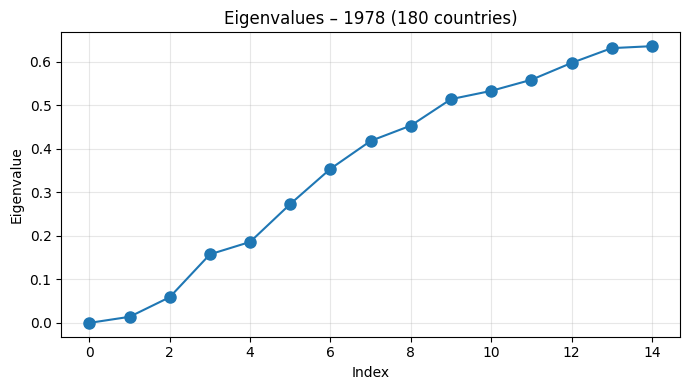

  Eigenvalues[:15]: [-0.      0.014   0.0591  0.1575  0.186   0.2731  0.354   0.418   0.4532
  0.514   0.533   0.5584  0.5971  0.6312  0.6357]
  Gaps: [0.014  0.0451 0.0984 0.0285 0.0871 0.0809 0.064  0.0352 0.0608 0.019
 0.0255 0.0387 0.034  0.0045]
  → Optimal number of clusters (eigengap): **3**
  Cluster sizes: [45 71 64]

Year: 1979


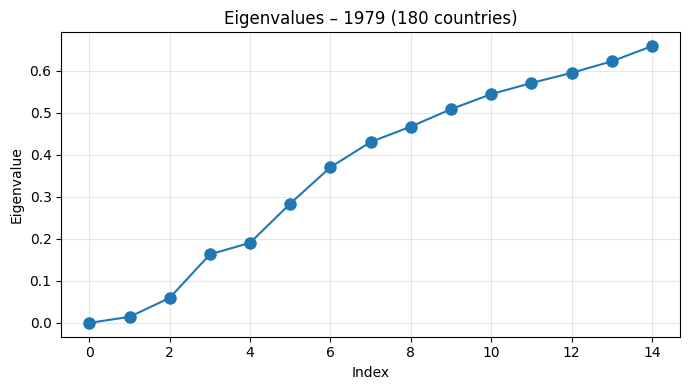

  Eigenvalues[:15]: [0.     0.0144 0.0596 0.1632 0.1907 0.2842 0.3707 0.4309 0.4674 0.509
 0.5447 0.5713 0.5954 0.6229 0.659 ]
  Gaps: [0.0144 0.0452 0.1036 0.0275 0.0935 0.0865 0.0602 0.0365 0.0416 0.0357
 0.0266 0.0241 0.0276 0.0361]
  → Optimal number of clusters (eigengap): **3**
  Cluster sizes: [45 74 61]

Year: 1980


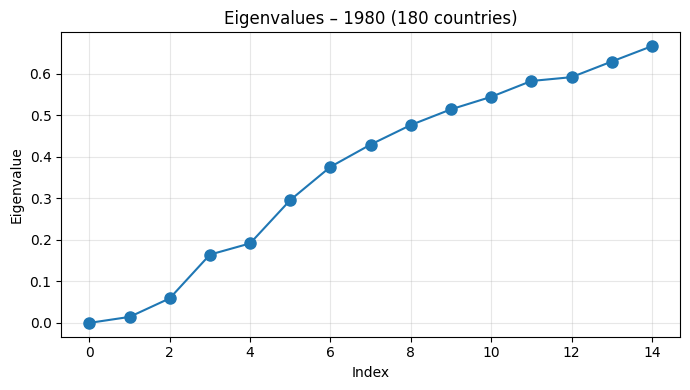

  Eigenvalues[:15]: [-0.      0.0144  0.0592  0.1645  0.1915  0.2959  0.3759  0.4296  0.4766
  0.5145  0.5445  0.5827  0.5919  0.6295  0.6665]
  Gaps: [0.0144 0.0447 0.1053 0.0271 0.1044 0.08   0.0537 0.047  0.0378 0.03
 0.0382 0.0092 0.0376 0.037 ]
  → Optimal number of clusters (eigengap): **3**
  Cluster sizes: [45 73 62]

Year: 1981


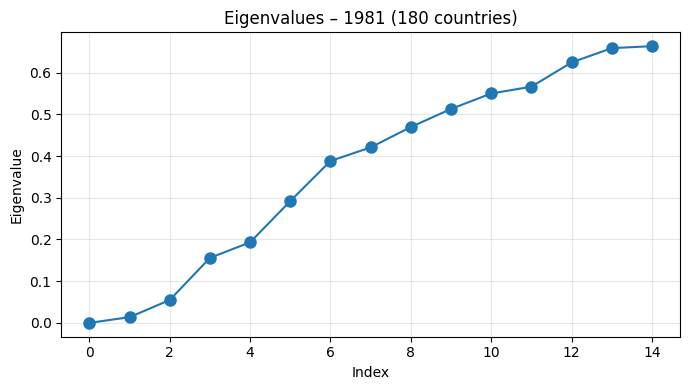

  Eigenvalues[:15]: [0.     0.0138 0.0549 0.1558 0.1931 0.292  0.3881 0.4207 0.4695 0.5128
 0.5499 0.5662 0.6243 0.6586 0.6634]
  Gaps: [0.0138 0.0411 0.101  0.0373 0.0989 0.0961 0.0325 0.0488 0.0433 0.0371
 0.0163 0.0581 0.0342 0.0048]
  → Optimal number of clusters (eigengap): **3**
  Cluster sizes: [45 73 62]

Year: 1982


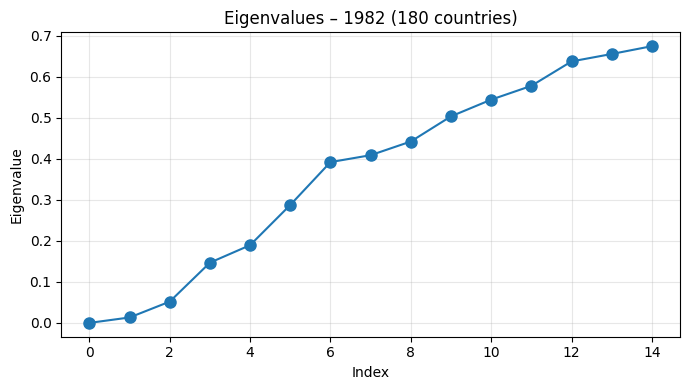

  Eigenvalues[:15]: [-0.      0.0132  0.0518  0.1467  0.1893  0.2873  0.3917  0.4085  0.4418
  0.5031  0.5438  0.5774  0.6369  0.655   0.6741]
  Gaps: [0.0132 0.0386 0.0949 0.0426 0.098  0.1044 0.0168 0.0333 0.0613 0.0407
 0.0336 0.0595 0.0181 0.0191]
  → Optimal number of clusters (eigengap): **6**
  Cluster sizes: [28 33 36 26 24 33]

Year: 1983


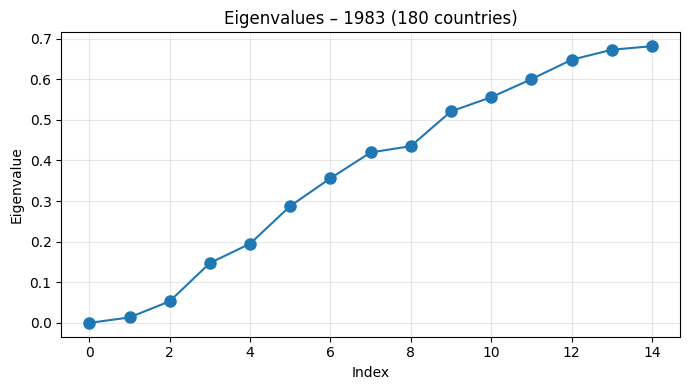

  Eigenvalues[:15]: [-0.      0.0135  0.0533  0.1475  0.195   0.2878  0.3562  0.4197  0.4351
  0.5208  0.5556  0.6001  0.6478  0.6725  0.6813]
  Gaps: [0.0135 0.0398 0.0942 0.0475 0.0928 0.0683 0.0635 0.0155 0.0857 0.0348
 0.0445 0.0477 0.0248 0.0088]
  → Optimal number of clusters (eigengap): **3**
  Cluster sizes: [44 74 62]

Year: 1984


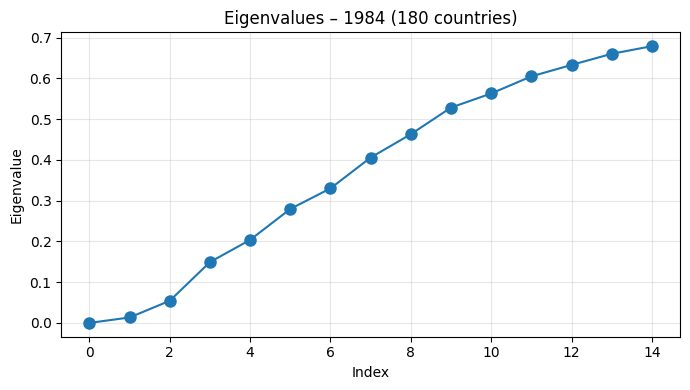

  Eigenvalues[:15]: [-0.      0.0133  0.0543  0.1492  0.2037  0.2796  0.3301  0.4058  0.463
  0.5285  0.563   0.6051  0.6331  0.6605  0.6792]
  Gaps: [0.0133 0.041  0.0949 0.0545 0.0759 0.0505 0.0757 0.0573 0.0654 0.0346
 0.042  0.028  0.0273 0.0187]
  → Optimal number of clusters (eigengap): **3**
  Cluster sizes: [43 70 67]

Year: 1985


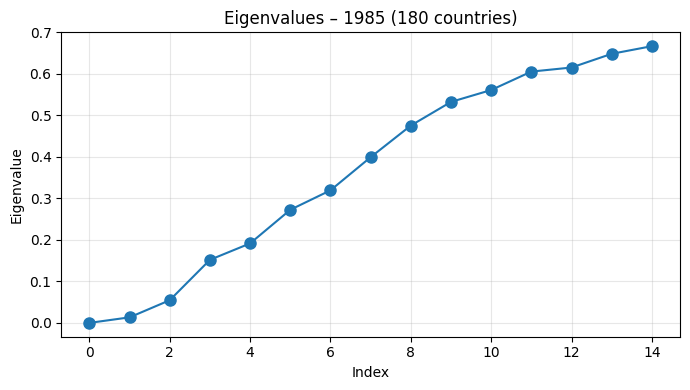

  Eigenvalues[:15]: [-0.      0.0134  0.0547  0.152   0.1916  0.2726  0.3195  0.3994  0.4756
  0.5326  0.5613  0.6057  0.6155  0.6486  0.667 ]
  Gaps: [0.0134 0.0413 0.0973 0.0396 0.081  0.0469 0.0799 0.0763 0.057  0.0287
 0.0444 0.0098 0.033  0.0184]
  → Optimal number of clusters (eigengap): **3**
  Cluster sizes: [46 66 68]

Year: 1986


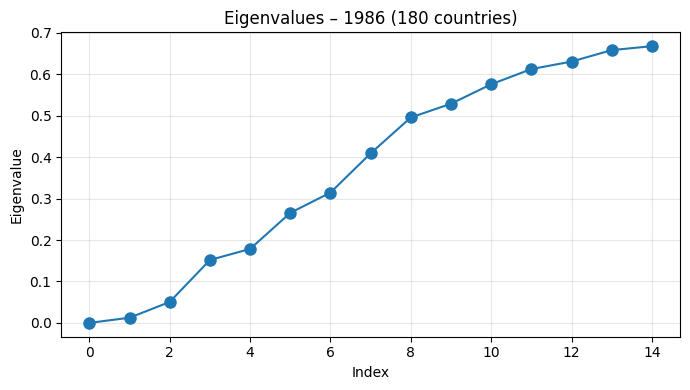

  Eigenvalues[:15]: [0.     0.0125 0.0506 0.1518 0.1785 0.2655 0.3145 0.4092 0.4958 0.529
 0.5759 0.6126 0.6307 0.6583 0.6679]
  Gaps: [0.0125 0.0381 0.1012 0.0267 0.087  0.0489 0.0947 0.0866 0.0332 0.0469
 0.0367 0.0181 0.0276 0.0096]
  → Optimal number of clusters (eigengap): **3**
  Cluster sizes: [68 50 62]

Year: 1987


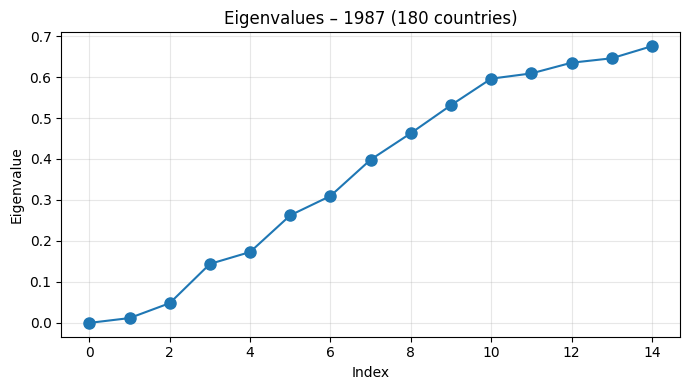

  Eigenvalues[:15]: [-0.      0.0118  0.0482  0.1439  0.1729  0.2626  0.3097  0.3984  0.4629
  0.5313  0.596   0.6088  0.6349  0.6457  0.6753]
  Gaps: [0.0118 0.0364 0.0957 0.029  0.0897 0.0471 0.0886 0.0645 0.0685 0.0647
 0.0128 0.0261 0.0108 0.0296]
  → Optimal number of clusters (eigengap): **3**
  Cluster sizes: [49 63 68]

Year: 1988


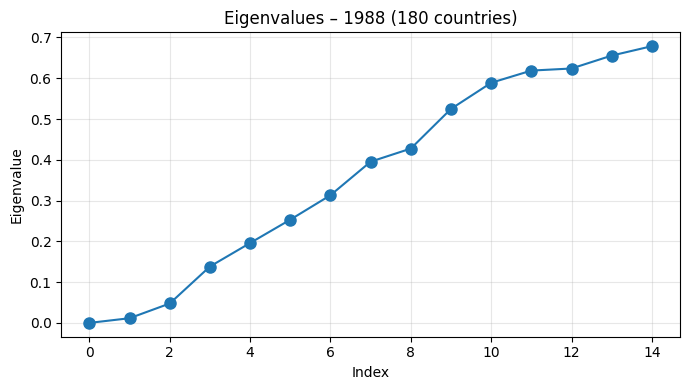

  Eigenvalues[:15]: [-0.      0.0115  0.0476  0.1383  0.1959  0.2532  0.3132  0.3954  0.4276
  0.5249  0.5889  0.6188  0.6239  0.6556  0.6787]
  Gaps: [0.0115 0.0361 0.0907 0.0576 0.0573 0.06   0.0822 0.0321 0.0973 0.064
 0.0299 0.0051 0.0317 0.0231]
  → Optimal number of clusters (eigengap): **9**
  Cluster sizes: [20 19 25 21 20 12 17 24 22]

Year: 1989


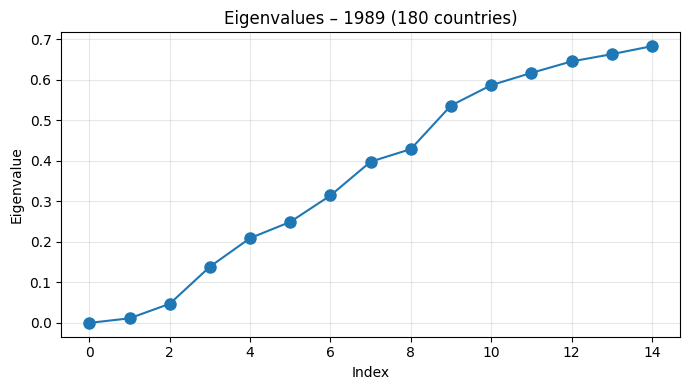

  Eigenvalues[:15]: [0.     0.0113 0.0472 0.1387 0.2091 0.2491 0.3143 0.3976 0.4287 0.5362
 0.5864 0.6166 0.645  0.6628 0.6826]
  Gaps: [0.0113 0.0359 0.0915 0.0704 0.04   0.0651 0.0833 0.0311 0.1074 0.0502
 0.0303 0.0283 0.0178 0.0198]
  → Optimal number of clusters (eigengap): **9**
  Cluster sizes: [13 23 22 23 23 17 19 20 20]

Year: 1990


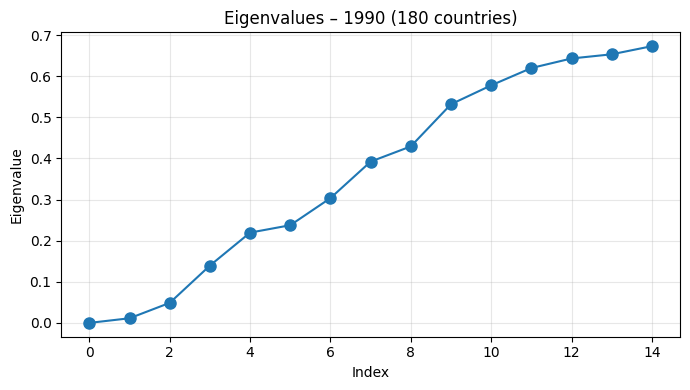

  Eigenvalues[:15]: [0.     0.0113 0.0487 0.1394 0.2195 0.2375 0.3035 0.3922 0.4292 0.5317
 0.5777 0.6198 0.6431 0.6532 0.673 ]
  Gaps: [0.0113 0.0375 0.0907 0.0801 0.018  0.066  0.0887 0.037  0.1025 0.0459
 0.0421 0.0233 0.0101 0.0198]
  → Optimal number of clusters (eigengap): **9**
  Cluster sizes: [16 24 20 22 17 22 18 19 22]

Year: 1991


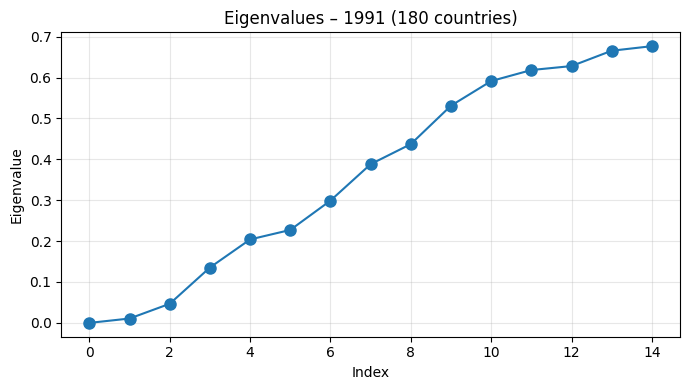

  Eigenvalues[:15]: [-0.      0.0107  0.0468  0.1354  0.2041  0.2273  0.299   0.3881  0.4372
  0.5311  0.5913  0.6183  0.628   0.6655  0.6767]
  Gaps: [0.0107 0.0361 0.0886 0.0687 0.0232 0.0717 0.0891 0.0491 0.094  0.0602
 0.027  0.0097 0.0375 0.0111]
  → Optimal number of clusters (eigengap): **9**
  Cluster sizes: [16 21 23 22 21 19 18 18 22]

Year: 1992


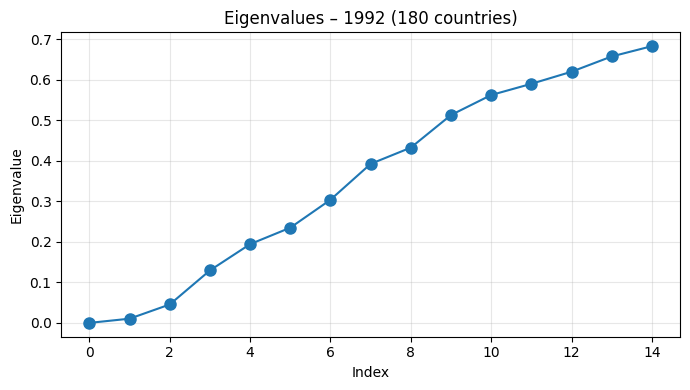

  Eigenvalues[:15]: [0.     0.0104 0.0455 0.1296 0.1945 0.2351 0.3041 0.3927 0.4329 0.5134
 0.5628 0.5905 0.6203 0.6581 0.6835]
  Gaps: [0.0104 0.0351 0.0841 0.0649 0.0406 0.069  0.0886 0.0402 0.0805 0.0494
 0.0277 0.0299 0.0377 0.0254]
  → Optimal number of clusters (eigengap): **7**
  Cluster sizes: [25 27 31 24 22 25 26]

Year: 1993


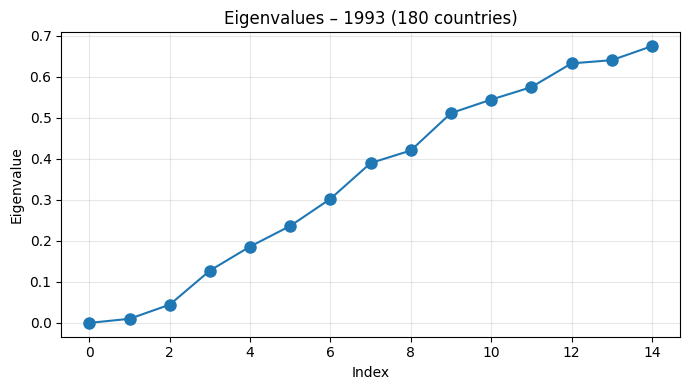

  Eigenvalues[:15]: [-0.      0.01    0.0445  0.1276  0.1863  0.2365  0.3027  0.3899  0.4206
  0.5117  0.5446  0.5751  0.633   0.6408  0.675 ]
  Gaps: [0.01   0.0345 0.0831 0.0586 0.0503 0.0662 0.0872 0.0307 0.0911 0.0329
 0.0304 0.0579 0.0078 0.0342]
  → Optimal number of clusters (eigengap): **9**
  Cluster sizes: [16 22 25 21 23 15 21 21 16]

Year: 1994


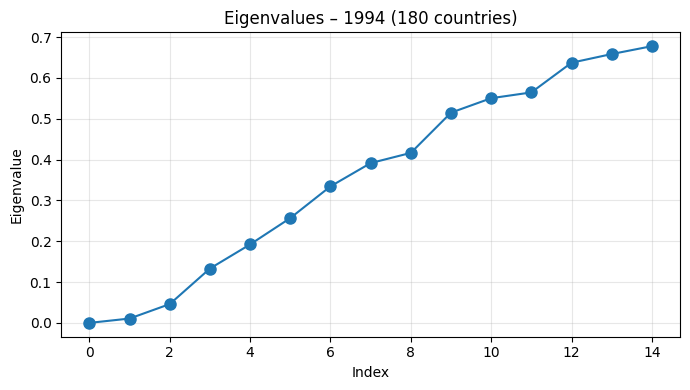

  Eigenvalues[:15]: [-0.      0.0107  0.0461  0.1331  0.1922  0.2567  0.3344  0.3914  0.4164
  0.5149  0.5503  0.5645  0.6372  0.6584  0.6777]
  Gaps: [0.0107 0.0354 0.0871 0.0591 0.0646 0.0776 0.057  0.025  0.0985 0.0355
 0.0142 0.0727 0.0213 0.0193]
  → Optimal number of clusters (eigengap): **9**
  Cluster sizes: [17 16 24 21 15 23 14 28 22]

Year: 1995


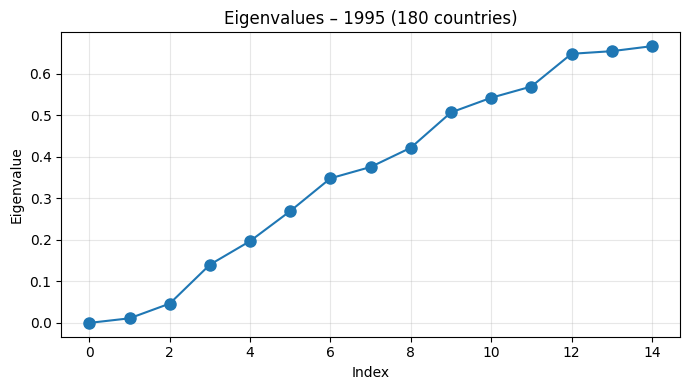

  Eigenvalues[:15]: [0.     0.011  0.0465 0.1403 0.1971 0.2694 0.3483 0.3756 0.4219 0.507
 0.5423 0.5694 0.6482 0.6545 0.6666]
  Gaps: [0.011  0.0355 0.0938 0.0567 0.0723 0.0789 0.0273 0.0464 0.085  0.0353
 0.0271 0.0788 0.0063 0.0121]
  → Optimal number of clusters (eigengap): **3**
  Cluster sizes: [51 65 64]

Year: 1996


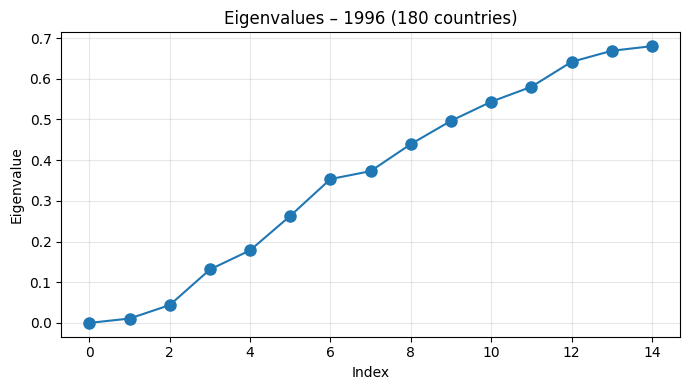

  Eigenvalues[:15]: [0.     0.0107 0.0439 0.1313 0.1783 0.263  0.3535 0.3729 0.4394 0.4965
 0.5435 0.5801 0.6414 0.6687 0.68  ]
  Gaps: [0.0107 0.0332 0.0874 0.047  0.0847 0.0905 0.0195 0.0665 0.0571 0.047
 0.0366 0.0613 0.0272 0.0114]
  → Optimal number of clusters (eigengap): **6**
  Cluster sizes: [27 43 26 25 25 34]

Year: 1997


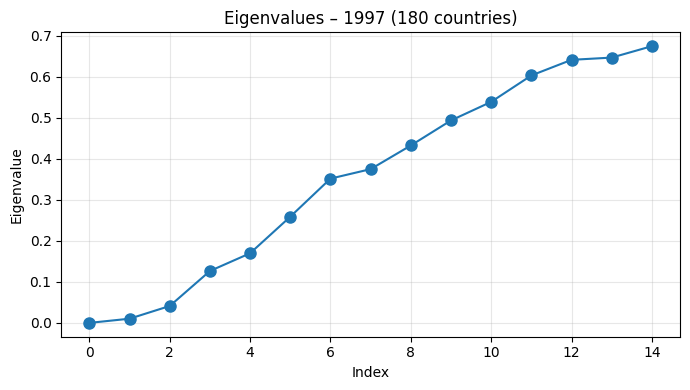

  Eigenvalues[:15]: [0.     0.0102 0.0412 0.1265 0.1698 0.2589 0.3518 0.3749 0.4325 0.4936
 0.5389 0.6033 0.6414 0.6468 0.6747]
  Gaps: [0.0102 0.031  0.0853 0.0432 0.0892 0.0928 0.0231 0.0577 0.0611 0.0453
 0.0644 0.0381 0.0055 0.0278]
  → Optimal number of clusters (eigengap): **6**
  Cluster sizes: [35 26 24 42 27 26]

Year: 1998


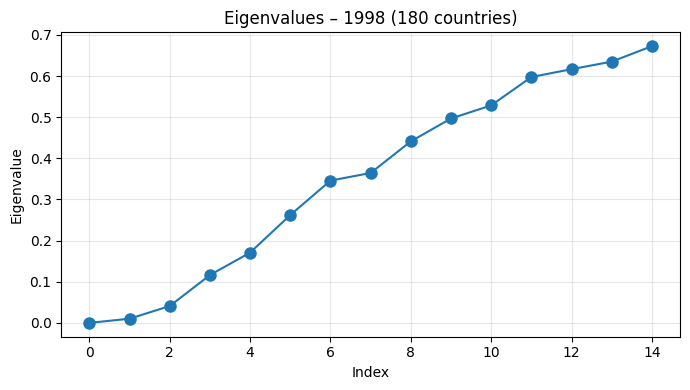

  Eigenvalues[:15]: [-0.      0.0102  0.041   0.1163  0.1709  0.2622  0.3459  0.3644  0.4413
  0.4969  0.5288  0.5977  0.6168  0.6351  0.6728]
  Gaps: [0.0102 0.0308 0.0753 0.0546 0.0914 0.0837 0.0185 0.0769 0.0556 0.0319
 0.0689 0.0191 0.0183 0.0376]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [40 27 32 40 41]

Year: 1999


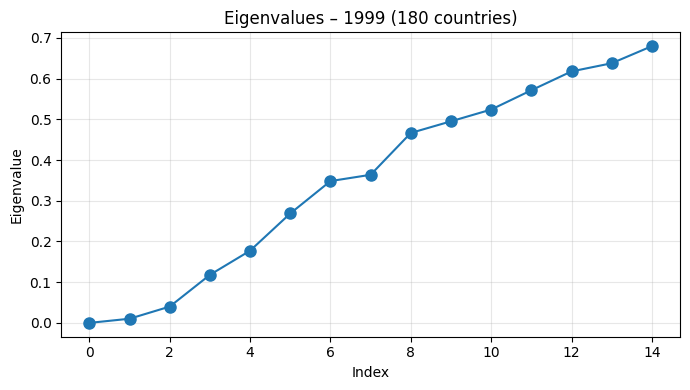

  Eigenvalues[:15]: [0.     0.0102 0.0401 0.1181 0.1774 0.2688 0.3483 0.3638 0.4666 0.4952
 0.524  0.5714 0.6177 0.6378 0.6797]
  Gaps: [0.0102 0.0298 0.078  0.0593 0.0915 0.0795 0.0155 0.1028 0.0286 0.0289
 0.0474 0.0463 0.0201 0.0419]
  → Optimal number of clusters (eigengap): **8**
  Cluster sizes: [14 31 26 22 17 26 17 27]

Year: 2000


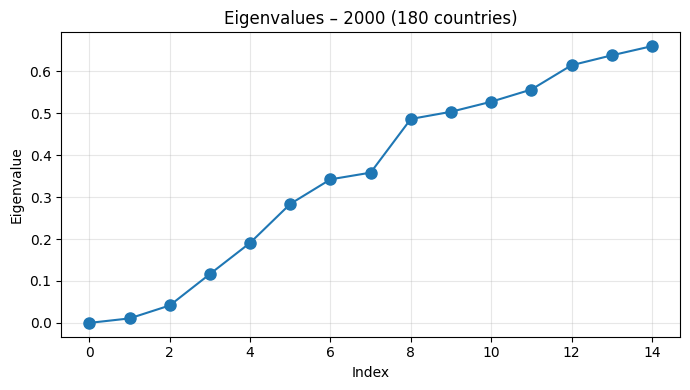

  Eigenvalues[:15]: [-0.      0.0107  0.0416  0.1165  0.1909  0.2837  0.3422  0.3583  0.4862
  0.5034  0.5273  0.5564  0.6143  0.6379  0.6598]
  Gaps: [0.0107 0.0309 0.0749 0.0743 0.0928 0.0586 0.016  0.128  0.0172 0.0239
 0.0291 0.0579 0.0236 0.0219]
  → Optimal number of clusters (eigengap): **8**
  Cluster sizes: [29 30 20 18 14 23 27 19]

Year: 2001


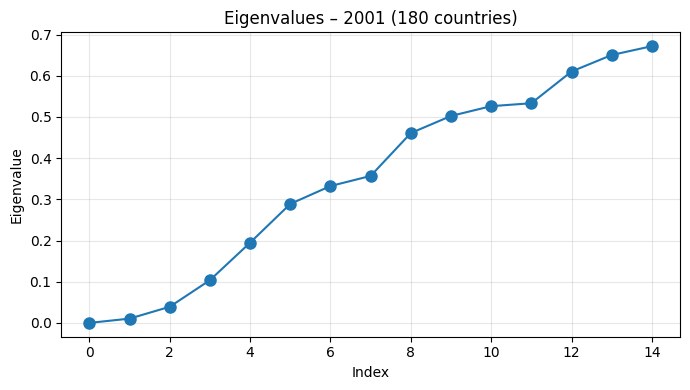

  Eigenvalues[:15]: [0.     0.0104 0.0392 0.1037 0.1948 0.2888 0.3322 0.3567 0.4608 0.5024
 0.5261 0.5333 0.6102 0.6503 0.6718]
  Gaps: [0.0104 0.0288 0.0646 0.091  0.094  0.0434 0.0245 0.1041 0.0416 0.0238
 0.0071 0.077  0.0401 0.0215]
  → Optimal number of clusters (eigengap): **8**
  Cluster sizes: [14 31 30 20 19 19 21 26]

Year: 2002


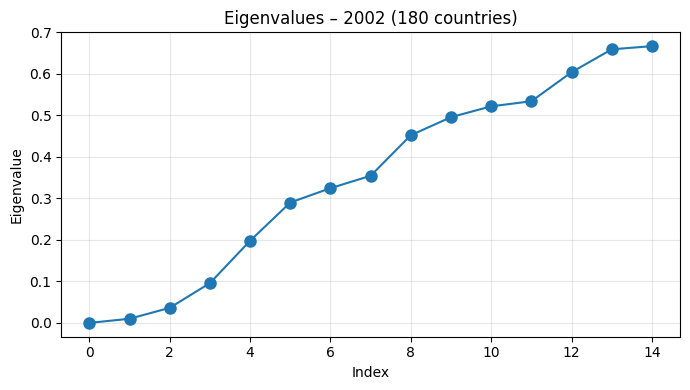

  Eigenvalues[:15]: [-0.      0.01    0.0363  0.0959  0.198   0.2901  0.3246  0.3546  0.4523
  0.4958  0.5219  0.5342  0.6041  0.6593  0.6669]
  Gaps: [0.01   0.0264 0.0596 0.1021 0.0922 0.0345 0.0299 0.0977 0.0435 0.0261
 0.0123 0.0699 0.0553 0.0076]
  → Optimal number of clusters (eigengap): **4**
  Cluster sizes: [55 53 36 36]

Year: 2003


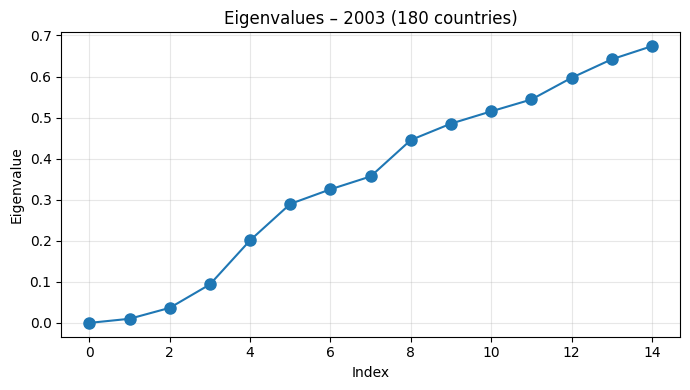

  Eigenvalues[:15]: [-0.      0.01    0.0366  0.0937  0.2011  0.2898  0.3253  0.3567  0.4454
  0.4853  0.5152  0.5441  0.5969  0.642   0.674 ]
  Gaps: [0.01   0.0266 0.0571 0.1073 0.0887 0.0356 0.0314 0.0887 0.0399 0.0299
 0.0289 0.0528 0.0451 0.032 ]
  → Optimal number of clusters (eigengap): **4**
  Cluster sizes: [34 53 37 56]

Year: 2004


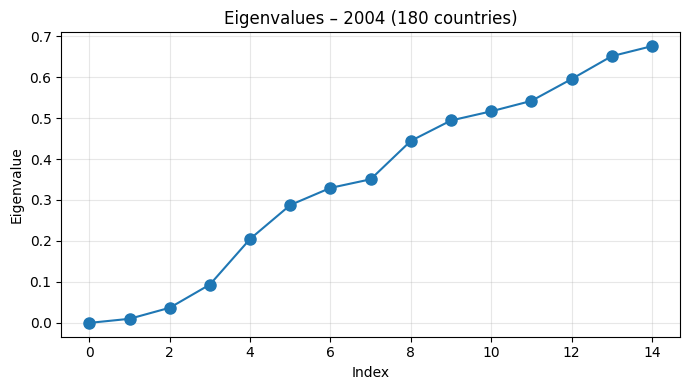

  Eigenvalues[:15]: [0.     0.01   0.037  0.0937 0.2049 0.2877 0.3295 0.3505 0.4442 0.494
 0.5164 0.5418 0.5951 0.651  0.6754]
  Gaps: [0.01   0.027  0.0567 0.1112 0.0828 0.0418 0.021  0.0937 0.0498 0.0224
 0.0254 0.0533 0.0559 0.0244]
  → Optimal number of clusters (eigengap): **4**
  Cluster sizes: [55 37 34 54]

Year: 2005


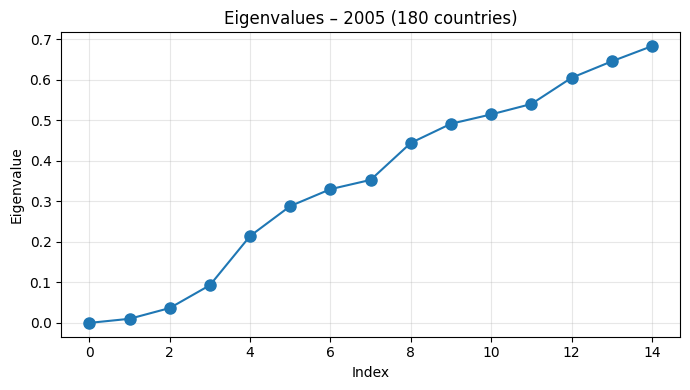

  Eigenvalues[:15]: [0.     0.0101 0.0366 0.093  0.2143 0.2881 0.3299 0.3527 0.444  0.4912
 0.5143 0.5399 0.6045 0.6451 0.6826]
  Gaps: [0.0101 0.0265 0.0564 0.1213 0.0738 0.0417 0.0229 0.0912 0.0472 0.0231
 0.0256 0.0646 0.0406 0.0375]
  → Optimal number of clusters (eigengap): **4**
  Cluster sizes: [37 54 34 55]

Year: 2006


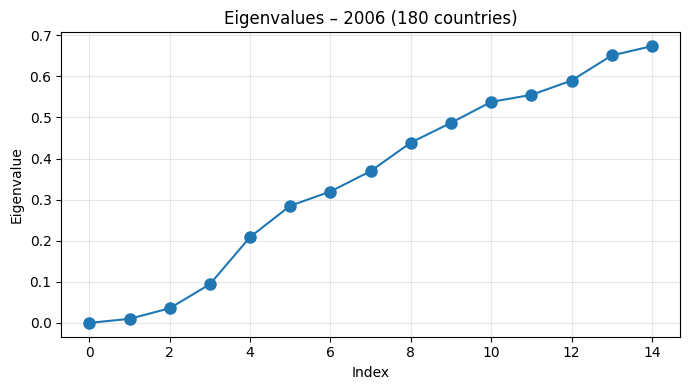

  Eigenvalues[:15]: [0.     0.0099 0.0356 0.0942 0.209  0.2851 0.3198 0.3694 0.4388 0.487
 0.5379 0.555  0.5898 0.651  0.6736]
  Gaps: [0.0099 0.0258 0.0586 0.1148 0.0761 0.0347 0.0497 0.0694 0.0481 0.051
 0.017  0.0348 0.0612 0.0225]
  → Optimal number of clusters (eigengap): **4**
  Cluster sizes: [55 53 35 37]

Year: 2007


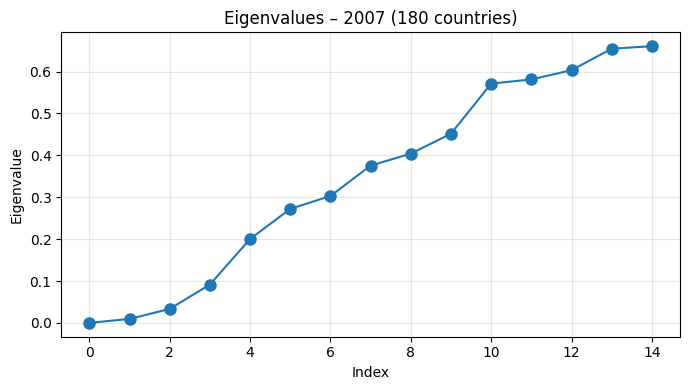

  Eigenvalues[:15]: [-0.      0.0095  0.0335  0.0916  0.2005  0.2722  0.303   0.3755  0.4041
  0.4517  0.5714  0.5812  0.6034  0.6547  0.6607]
  Gaps: [0.0095 0.024  0.0581 0.1089 0.0717 0.0308 0.0724 0.0287 0.0476 0.1197
 0.0098 0.0222 0.0513 0.0061]
  → Optimal number of clusters (eigengap): **10**
  Cluster sizes: [18 24 15 19 17 14 14 18 18 23]

Year: 2008


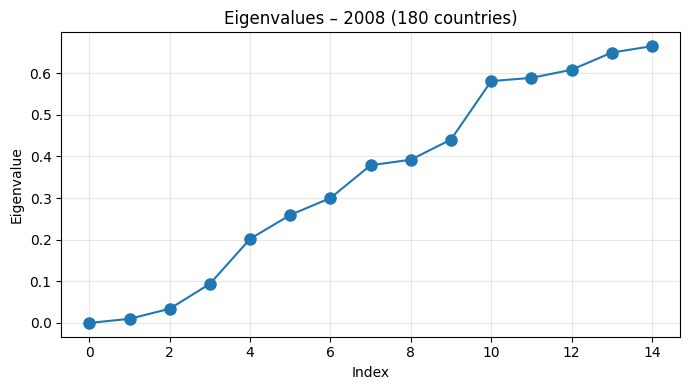

  Eigenvalues[:15]: [0.     0.0097 0.0341 0.0938 0.2019 0.2594 0.3    0.3789 0.3921 0.4406
 0.581  0.5888 0.6082 0.6495 0.665 ]
  Gaps: [0.0097 0.0244 0.0597 0.1081 0.0575 0.0407 0.0788 0.0133 0.0484 0.1405
 0.0077 0.0195 0.0412 0.0155]
  → Optimal number of clusters (eigengap): **10**
  Cluster sizes: [23 19 13 23 15 15 17 19 19 17]

Year: 2009


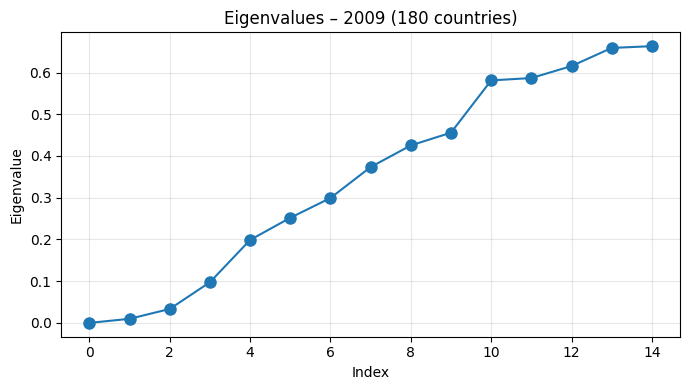

  Eigenvalues[:15]: [-0.      0.0098  0.0334  0.0975  0.1988  0.2519  0.2993  0.3735  0.4253
  0.4559  0.5811  0.5868  0.6155  0.659   0.6632]
  Gaps: [0.0098 0.0236 0.0641 0.1013 0.0531 0.0475 0.0742 0.0519 0.0305 0.1253
 0.0056 0.0287 0.0435 0.0042]
  → Optimal number of clusters (eigengap): **10**
  Cluster sizes: [22 23 17 23 12 18 15 19 17 14]

Year: 2010


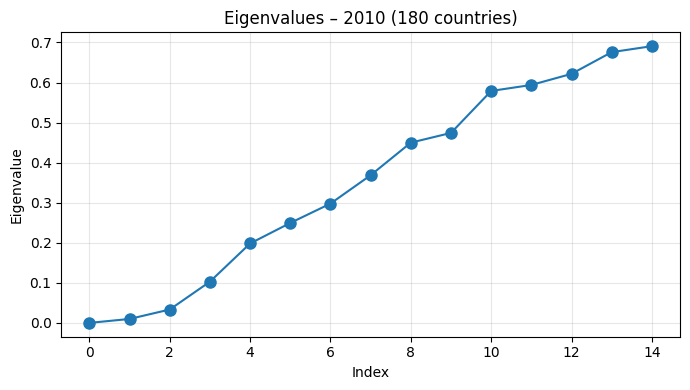

  Eigenvalues[:15]: [0.     0.0098 0.0334 0.1029 0.1982 0.2495 0.2977 0.3686 0.4499 0.4742
 0.579  0.5939 0.6217 0.6759 0.6907]
  Gaps: [0.0098 0.0236 0.0695 0.0953 0.0513 0.0483 0.0709 0.0813 0.0243 0.1048
 0.015  0.0277 0.0542 0.0149]
  → Optimal number of clusters (eigengap): **10**
  Cluster sizes: [24 23 17 17 17 14 13 19 18 18]

Year: 2011


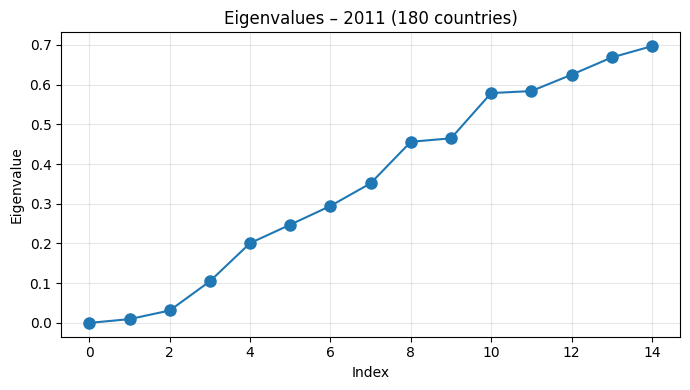

  Eigenvalues[:15]: [0.     0.0095 0.0312 0.1048 0.2009 0.2473 0.2944 0.3515 0.4559 0.4647
 0.5786 0.5837 0.6248 0.6682 0.6967]
  Gaps: [0.0095 0.0218 0.0736 0.096  0.0465 0.0471 0.057  0.1045 0.0088 0.1139
 0.0051 0.0411 0.0435 0.0285]
  → Optimal number of clusters (eigengap): **10**
  Cluster sizes: [22 18 18 18 14 25 23 12 12 18]

Year: 2012


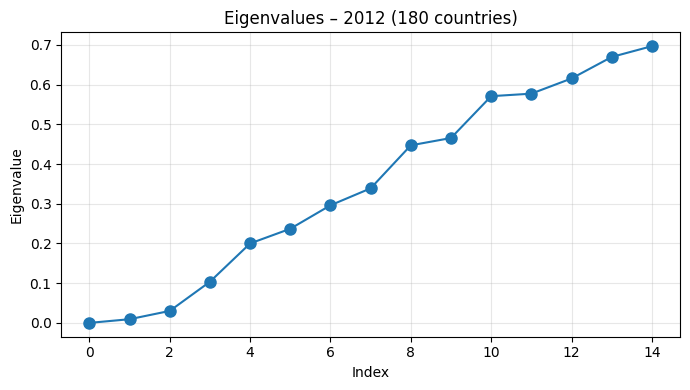

  Eigenvalues[:15]: [-0.      0.0093  0.0301  0.1036  0.2     0.237   0.2961  0.3389  0.4472
  0.4656  0.571   0.5773  0.6155  0.6697  0.6969]
  Gaps: [0.0093 0.0209 0.0735 0.0964 0.037  0.0591 0.0427 0.1083 0.0184 0.1054
 0.0063 0.0382 0.0542 0.0272]
  → Optimal number of clusters (eigengap): **8**
  Cluster sizes: [22 29 29 12 26 21 14 27]

Year: 2013


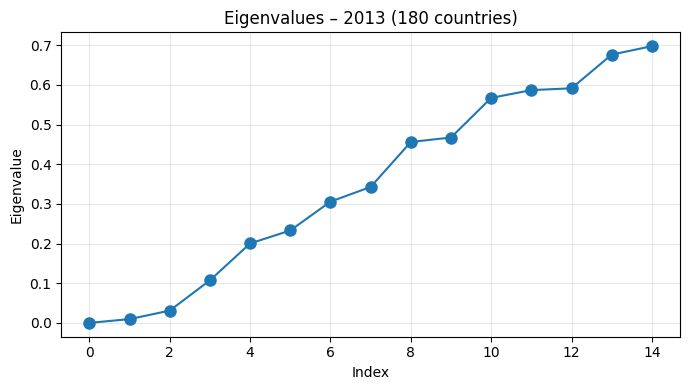

  Eigenvalues[:15]: [-0.      0.0095  0.031   0.1073  0.2003  0.233   0.3058  0.3426  0.456
  0.4673  0.5672  0.5868  0.5914  0.6764  0.6976]
  Gaps: [0.0095 0.0214 0.0764 0.0929 0.0327 0.0728 0.0369 0.1134 0.0113 0.0999
 0.0196 0.0046 0.085  0.0212]
  → Optimal number of clusters (eigengap): **8**
  Cluster sizes: [28 26 25 30 24 20 15 12]

Year: 2014


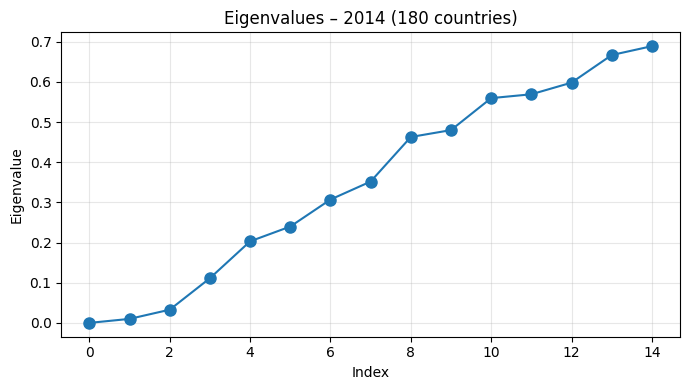

  Eigenvalues[:15]: [0.     0.01   0.0328 0.1113 0.203  0.2398 0.307  0.3518 0.4627 0.4799
 0.5594 0.569  0.598  0.6667 0.6888]
  Gaps: [0.01   0.0229 0.0784 0.0918 0.0368 0.0672 0.0448 0.1109 0.0172 0.0796
 0.0096 0.029  0.0687 0.0221]
  → Optimal number of clusters (eigengap): **8**
  Cluster sizes: [26 26 25 26 12 19 15 31]

Year: 2015


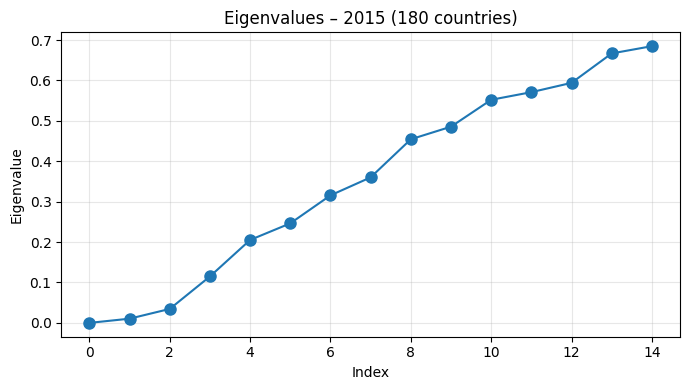

  Eigenvalues[:15]: [0.     0.0104 0.0345 0.115  0.2053 0.2464 0.3157 0.3602 0.4545 0.4856
 0.5522 0.5711 0.5941 0.667  0.6849]
  Gaps: [0.0104 0.0241 0.0804 0.0903 0.0411 0.0693 0.0445 0.0943 0.0311 0.0666
 0.0189 0.023  0.0729 0.018 ]
  → Optimal number of clusters (eigengap): **8**
  Cluster sizes: [26 27 26 15 18 31 23 14]

Year: 2016


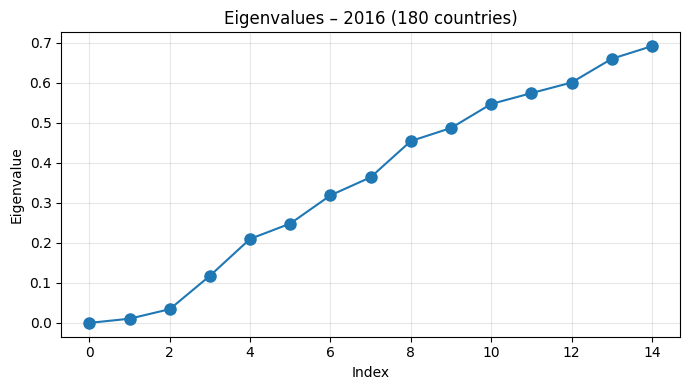

  Eigenvalues[:15]: [0.     0.0104 0.0343 0.1176 0.2098 0.2481 0.3186 0.3637 0.4541 0.4867
 0.5468 0.5738 0.6003 0.6596 0.6912]
  Gaps: [0.0104 0.0239 0.0834 0.0922 0.0383 0.0705 0.0452 0.0904 0.0326 0.06
 0.0271 0.0265 0.0592 0.0316]
  → Optimal number of clusters (eigengap): **4**
  Cluster sizes: [57 34 53 36]

Year: 2017


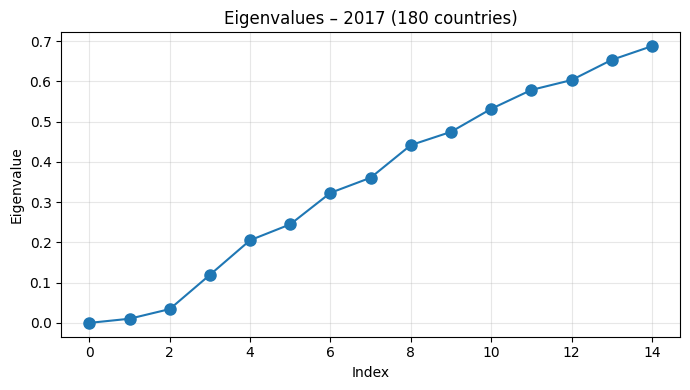

  Eigenvalues[:15]: [-0.      0.0103  0.0343  0.1194  0.2054  0.2449  0.323   0.3606  0.4416
  0.4745  0.5317  0.5786  0.6031  0.6533  0.6874]
  Gaps: [0.0103 0.024  0.0851 0.0859 0.0395 0.0782 0.0376 0.081  0.0329 0.0572
 0.0469 0.0245 0.0501 0.0341]
  → Optimal number of clusters (eigengap): **4**
  Cluster sizes: [36 51 36 57]

Year: 2018


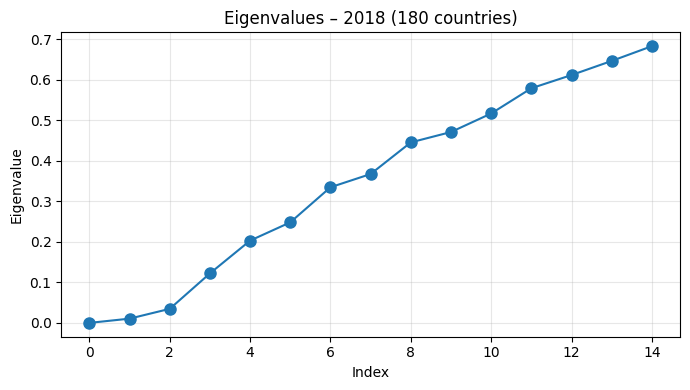

  Eigenvalues[:15]: [0.     0.0105 0.0347 0.1222 0.203  0.2481 0.3347 0.3673 0.4454 0.471
 0.5167 0.579  0.6116 0.6464 0.6828]
  Gaps: [0.0105 0.0242 0.0875 0.0809 0.0451 0.0866 0.0327 0.0781 0.0256 0.0457
 0.0623 0.0326 0.0348 0.0364]
  → Optimal number of clusters (eigengap): **3**
  Cluster sizes: [49 59 72]

Year: 2019


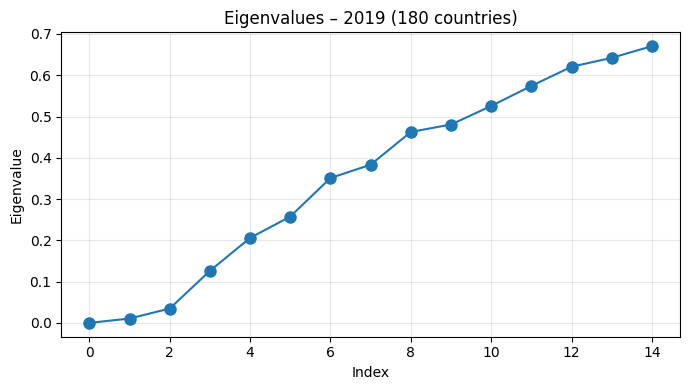

  Eigenvalues[:15]: [-0.      0.0105  0.0348  0.1261  0.2059  0.2577  0.3511  0.3832  0.4627
  0.4806  0.5256  0.5741  0.6206  0.6422  0.6704]
  Gaps: [0.0105 0.0243 0.0913 0.0797 0.0518 0.0934 0.0321 0.0795 0.018  0.045
 0.0485 0.0465 0.0215 0.0283]
  → Optimal number of clusters (eigengap): **6**
  Cluster sizes: [28 31 39 20 31 31]

Year: 2020


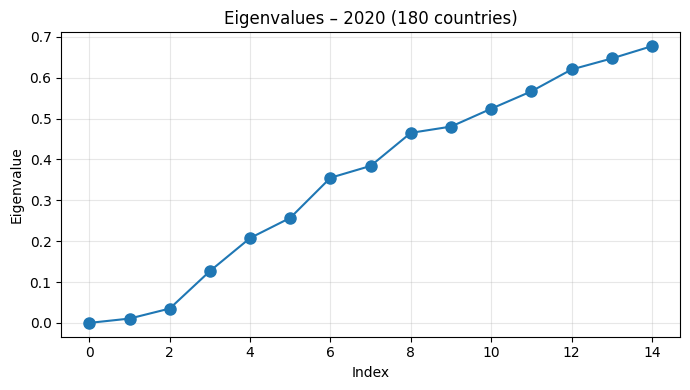

  Eigenvalues[:15]: [0.     0.0106 0.0351 0.1268 0.2076 0.2571 0.3551 0.3841 0.465  0.4804
 0.5241 0.5666 0.6201 0.647  0.6772]
  Gaps: [0.0106 0.0245 0.0917 0.0808 0.0494 0.0981 0.029  0.0809 0.0154 0.0437
 0.0425 0.0535 0.0269 0.0302]
  → Optimal number of clusters (eigengap): **6**
  Cluster sizes: [30 39 29 21 31 30]

Year: 2021


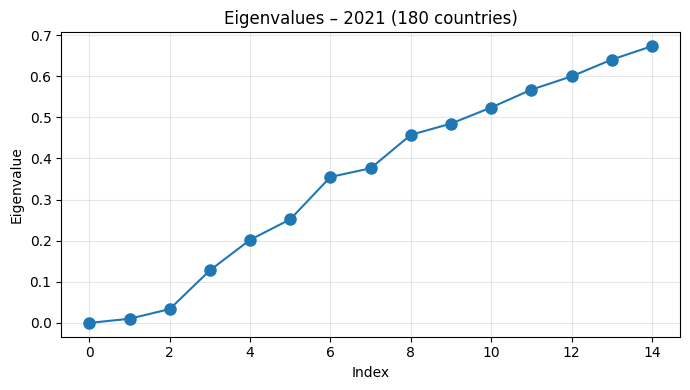

  Eigenvalues[:15]: [-0.      0.0101  0.0336  0.1279  0.2021  0.252   0.3551  0.376   0.4575
  0.4847  0.5239  0.5673  0.5996  0.6403  0.6731]
  Gaps: [0.0101 0.0236 0.0943 0.0741 0.0499 0.1031 0.0209 0.0814 0.0273 0.0392
 0.0434 0.0323 0.0407 0.0328]
  → Optimal number of clusters (eigengap): **6**
  Cluster sizes: [28 31 20 31 38 32]

Year: 2022


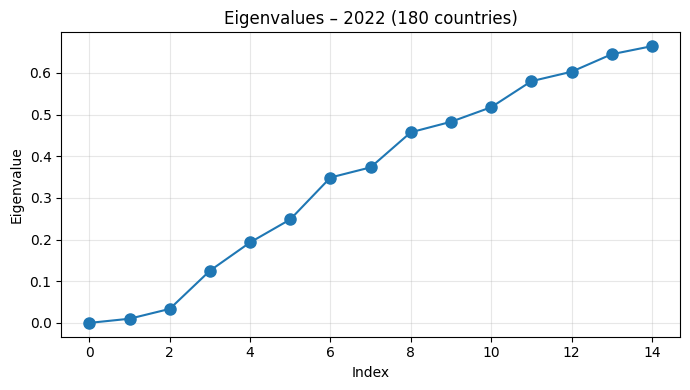

  Eigenvalues[:15]: [-0.      0.01    0.0336  0.1253  0.1931  0.2484  0.3489  0.3733  0.4574
  0.4827  0.5176  0.5801  0.6027  0.6448  0.6642]
  Gaps: [0.01   0.0236 0.0917 0.0679 0.0553 0.1005 0.0244 0.0841 0.0252 0.0349
 0.0625 0.0227 0.0421 0.0194]
  → Optimal number of clusters (eigengap): **6**
  Cluster sizes: [31 32 33 18 28 38]

Year: 2023


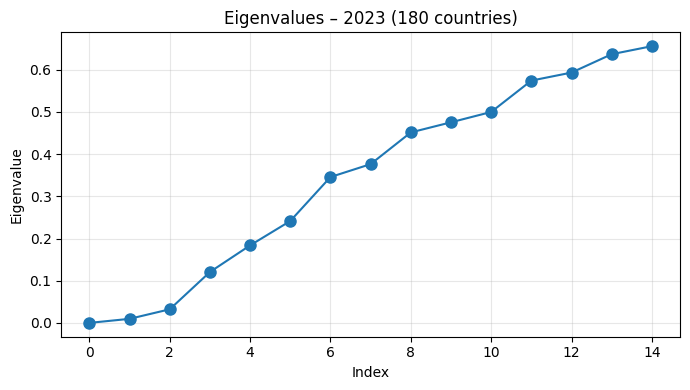

  Eigenvalues[:15]: [-0.      0.0096  0.0322  0.1207  0.1838  0.2415  0.3458  0.3764  0.4515
  0.4755  0.5     0.5744  0.5934  0.637   0.656 ]
  Gaps: [0.0096 0.0226 0.0884 0.0631 0.0578 0.1042 0.0306 0.0752 0.024  0.0245
 0.0744 0.019  0.0435 0.019 ]
  → Optimal number of clusters (eigengap): **6**
  Cluster sizes: [28 32 31 38 19 32]

Year: 2024


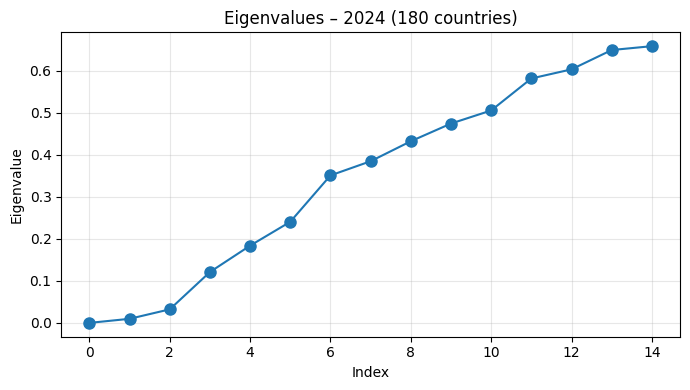

  Eigenvalues[:15]: [0.     0.0097 0.0322 0.1211 0.1839 0.2407 0.3511 0.3849 0.4325 0.4746
 0.5058 0.5819 0.6037 0.6497 0.6588]
  Gaps: [0.0097 0.0225 0.0889 0.0628 0.0568 0.1104 0.0338 0.0476 0.0421 0.0312
 0.0762 0.0217 0.046  0.0092]
  → Optimal number of clusters (eigengap): **6**
  Cluster sizes: [33 37 33 18 33 26]

Year: 2025


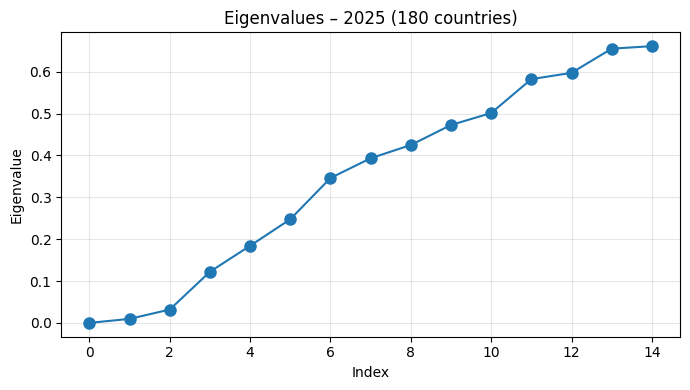

  Eigenvalues[:15]: [-0.      0.0096  0.0318  0.1222  0.1843  0.2476  0.3462  0.3933  0.425
  0.4728  0.5014  0.5824  0.5974  0.6552  0.6611]
  Gaps: [0.0096 0.0222 0.0903 0.0621 0.0633 0.0986 0.0472 0.0316 0.0479 0.0285
 0.081  0.015  0.0578 0.0059]
  → Optimal number of clusters (eigengap): **6**
  Cluster sizes: [26 33 37 33 33 18]

Year: 2026


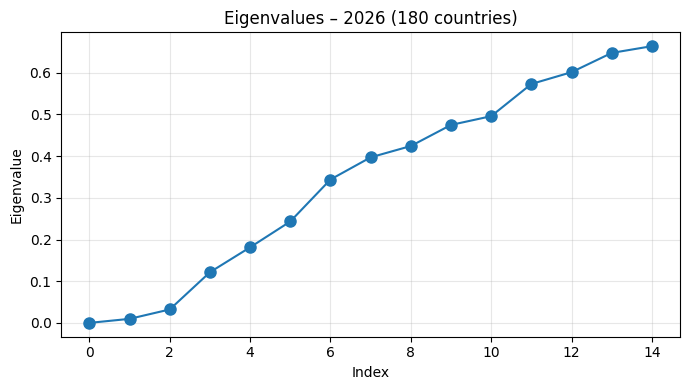

  Eigenvalues[:15]: [-0.      0.0097  0.0322  0.1215  0.1813  0.2432  0.3439  0.3971  0.4242
  0.4749  0.4958  0.5731  0.6014  0.6476  0.6638]
  Gaps: [0.0097 0.0225 0.0893 0.0598 0.0619 0.1007 0.0532 0.0271 0.0506 0.021
 0.0772 0.0283 0.0462 0.0162]
  → Optimal number of clusters (eigengap): **6**
  Cluster sizes: [26 33 33 37 33 18]

Year: 2027


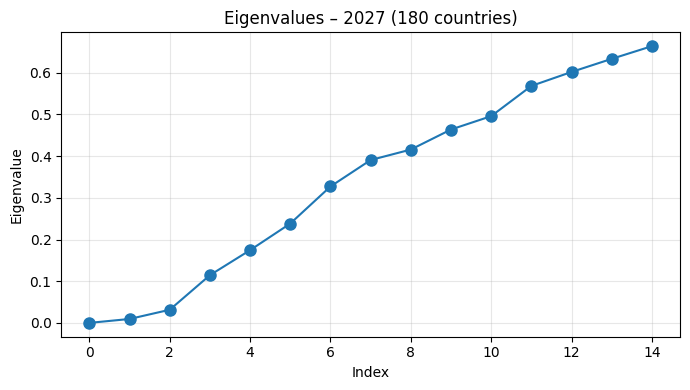

  Eigenvalues[:15]: [-0.      0.0094  0.0315  0.1145  0.1745  0.2383  0.3272  0.3906  0.4158
  0.4638  0.4959  0.5684  0.6019  0.6333  0.6638]
  Gaps: [0.0094 0.0221 0.083  0.06   0.0638 0.0889 0.0635 0.0252 0.0481 0.032
 0.0725 0.0335 0.0315 0.0304]
  → Optimal number of clusters (eigengap): **6**
  Cluster sizes: [33 37 33 26 18 33]

Year: 2028


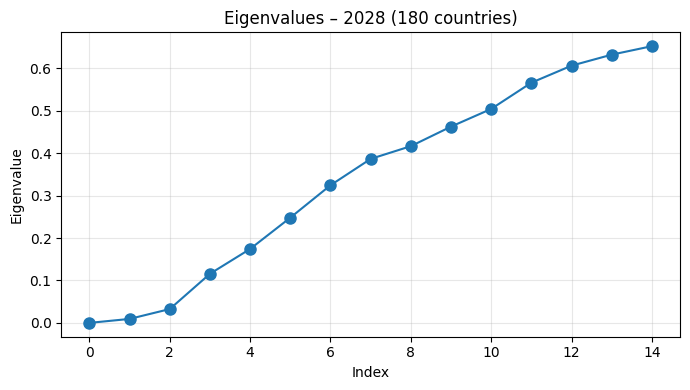

  Eigenvalues[:15]: [0.     0.0094 0.0326 0.1157 0.1743 0.248  0.3244 0.3866 0.4166 0.4626
 0.5044 0.5662 0.6064 0.6323 0.6524]
  Gaps: [0.0094 0.0232 0.0831 0.0586 0.0737 0.0764 0.0621 0.03   0.0461 0.0417
 0.0618 0.0402 0.0259 0.02  ]
  → Optimal number of clusters (eigengap): **3**
  Cluster sizes: [58 71 51]

Year: 2029


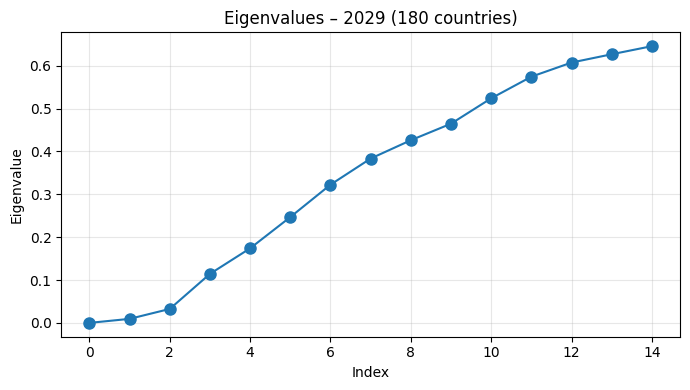

  Eigenvalues[:15]: [-0.      0.0094  0.0325  0.1143  0.1739  0.2468  0.3224  0.3834  0.4261
  0.4646  0.5239  0.5743  0.6073  0.6267  0.6455]
  Gaps: [0.0094 0.0231 0.0818 0.0596 0.0729 0.0756 0.061  0.0427 0.0386 0.0592
 0.0504 0.033  0.0193 0.0189]
  → Optimal number of clusters (eigengap): **3**
  Cluster sizes: [58 71 51]

Year: 2030


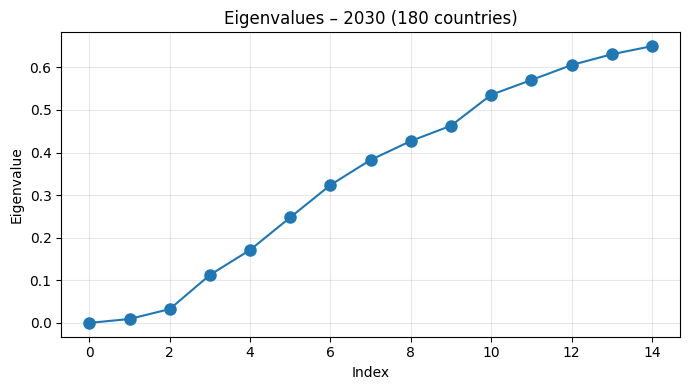

  Eigenvalues[:15]: [0.     0.0092 0.0324 0.1126 0.1712 0.2477 0.3237 0.3826 0.427  0.4629
 0.5354 0.5702 0.6053 0.6306 0.6496]
  Gaps: [0.0092 0.0233 0.0802 0.0586 0.0765 0.076  0.0589 0.0443 0.036  0.0725
 0.0347 0.0351 0.0253 0.0191]
  → Optimal number of clusters (eigengap): **3**
  Cluster sizes: [58 71 51]

Year: 2031


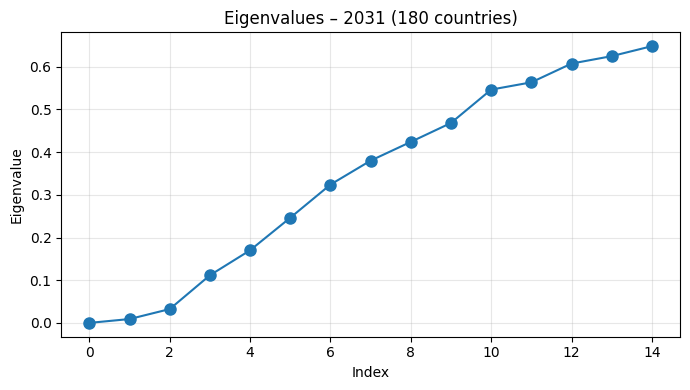

  Eigenvalues[:15]: [0.     0.009  0.0324 0.1116 0.1701 0.2463 0.324  0.3801 0.424  0.4684
 0.5465 0.5635 0.6075 0.6249 0.6483]
  Gaps: [0.009  0.0234 0.0792 0.0585 0.0762 0.0777 0.0561 0.0439 0.0443 0.0781
 0.017  0.0439 0.0174 0.0234]
  → Optimal number of clusters (eigengap): **3**
  Cluster sizes: [59 70 51]

Year: 2032


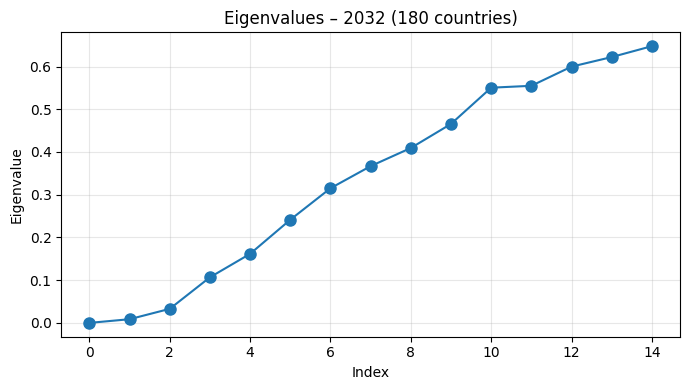

  Eigenvalues[:15]: [-0.      0.0086  0.0329  0.1067  0.1616  0.2414  0.3151  0.3669  0.4094
  0.4657  0.5505  0.5549  0.5998  0.6222  0.6477]
  Gaps: [0.0086 0.0243 0.0738 0.0549 0.0798 0.0737 0.0518 0.0425 0.0563 0.0849
 0.0044 0.0449 0.0224 0.0255]
  → Optimal number of clusters (eigengap): **10**
  Cluster sizes: [16 17 21 16 18 11 19 22 20 20]

Year: 2033


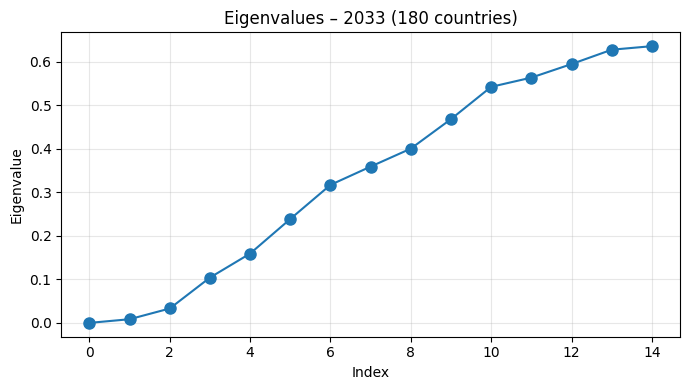

  Eigenvalues[:15]: [-0.      0.0084  0.0331  0.1041  0.1594  0.2388  0.3172  0.3593  0.4006
  0.4684  0.5426  0.5639  0.595   0.628   0.6361]
  Gaps: [0.0084 0.0246 0.0711 0.0552 0.0795 0.0784 0.042  0.0413 0.0678 0.0742
 0.0212 0.0311 0.033  0.0081]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [22 38 31 52 37]

Year: 2034


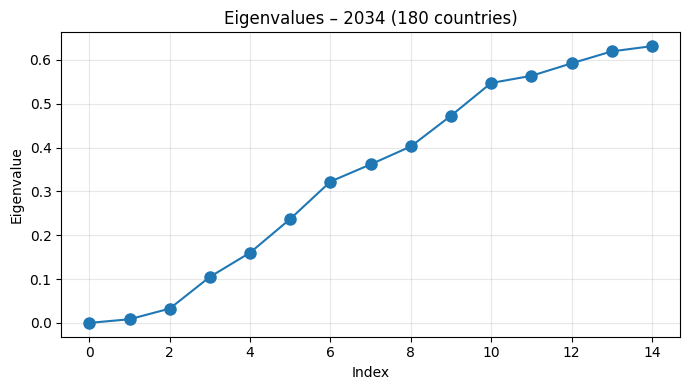

  Eigenvalues[:15]: [-0.      0.0083  0.0326  0.1051  0.1603  0.2373  0.3225  0.3618  0.4027
  0.4728  0.5476  0.5639  0.5923  0.6197  0.6316]
  Gaps: [0.0083 0.0243 0.0725 0.0552 0.077  0.0852 0.0393 0.0409 0.0701 0.0748
 0.0163 0.0284 0.0274 0.0119]
  → Optimal number of clusters (eigengap): **6**
  Cluster sizes: [29 42 23 30 26 30]

Year: 2035


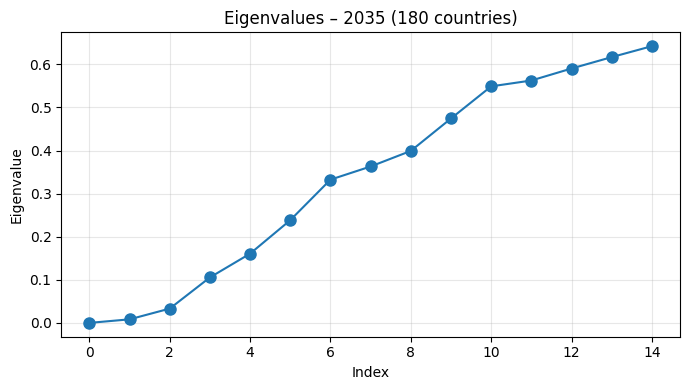

  Eigenvalues[:15]: [0.     0.0082 0.0332 0.1055 0.1607 0.2384 0.3324 0.3629 0.3991 0.4743
 0.5488 0.5624 0.5902 0.6167 0.6421]
  Gaps: [0.0082 0.0249 0.0724 0.0551 0.0777 0.094  0.0305 0.0361 0.0752 0.0745
 0.0136 0.0278 0.0265 0.0254]
  → Optimal number of clusters (eigengap): **6**
  Cluster sizes: [29 42 25 30 26 28]

Year: 2036


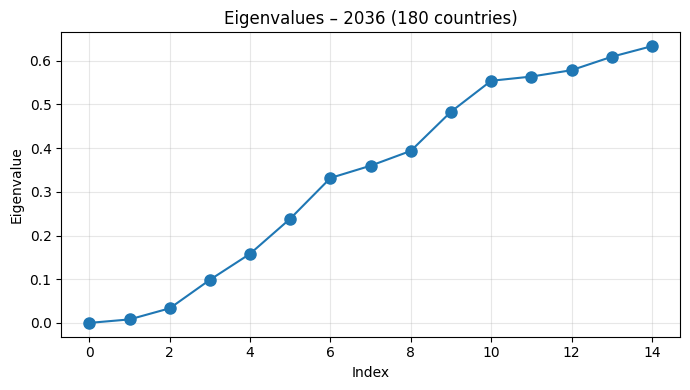

  Eigenvalues[:15]: [0.     0.008  0.0334 0.0986 0.1582 0.2386 0.3317 0.3597 0.3937 0.4833
 0.5541 0.5637 0.5783 0.609  0.6333]
  Gaps: [0.008  0.0254 0.0652 0.0596 0.0804 0.0931 0.0281 0.0339 0.0896 0.0708
 0.0096 0.0146 0.0307 0.0243]
  → Optimal number of clusters (eigengap): **6**
  Cluster sizes: [30 26 26 27 40 31]

Year: 2037


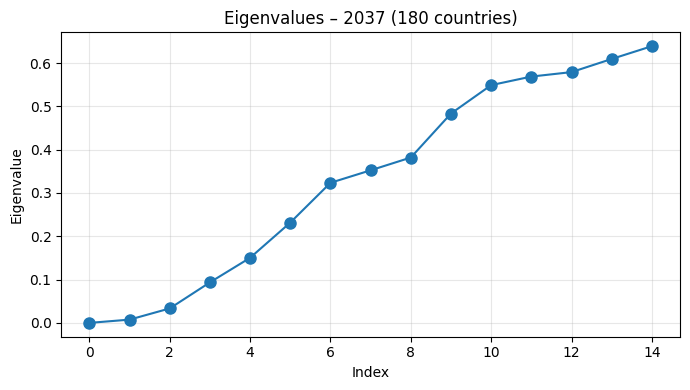

  Eigenvalues[:15]: [-0.      0.0075  0.0334  0.0936  0.1503  0.2317  0.3235  0.3524  0.3819
  0.4835  0.5491  0.5689  0.5792  0.6095  0.6391]
  Gaps: [0.0075 0.0259 0.0602 0.0567 0.0813 0.0919 0.0289 0.0295 0.1016 0.0656
 0.0198 0.0103 0.0304 0.0295]
  → Optimal number of clusters (eigengap): **9**
  Cluster sizes: [24 21 20 22 15 18 26 17 17]

Year: 2038


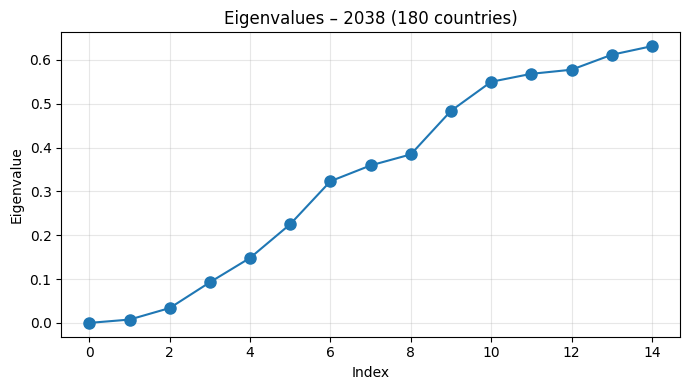

  Eigenvalues[:15]: [-0.      0.0076  0.0339  0.0928  0.1484  0.2254  0.3233  0.3594  0.3846
  0.484   0.5502  0.5685  0.5778  0.6119  0.6316]
  Gaps: [0.0076 0.0264 0.0588 0.0556 0.077  0.098  0.0361 0.0251 0.0994 0.0663
 0.0182 0.0093 0.0341 0.0197]
  → Optimal number of clusters (eigengap): **9**
  Cluster sizes: [18 26 24 17 20 15 18 22 20]

Year: 2039


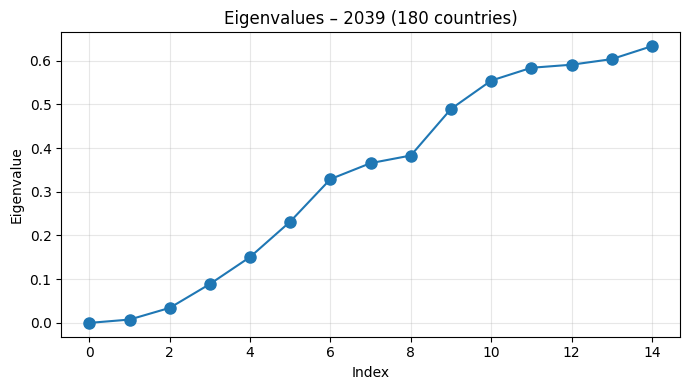

  Eigenvalues[:15]: [-0.      0.0076  0.0344  0.0889  0.1507  0.2318  0.3289  0.3654  0.3828
  0.4894  0.5542  0.5835  0.5905  0.6033  0.6329]
  Gaps: [0.0076 0.0268 0.0546 0.0618 0.0811 0.0971 0.0365 0.0174 0.1065 0.0648
 0.0294 0.007  0.0128 0.0296]
  → Optimal number of clusters (eigengap): **9**
  Cluster sizes: [22 26 15 17 23 18 20 24 15]

Year: 2040


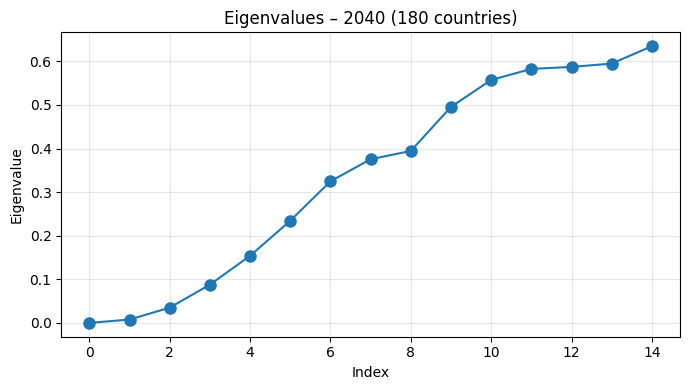

  Eigenvalues[:15]: [0.     0.0076 0.035  0.0878 0.154  0.2344 0.3248 0.3755 0.3944 0.4956
 0.5574 0.5827 0.5873 0.5949 0.6349]
  Gaps: [0.0076 0.0274 0.0528 0.0662 0.0804 0.0904 0.0507 0.0189 0.1012 0.0618
 0.0254 0.0046 0.0076 0.04  ]
  → Optimal number of clusters (eigengap): **9**
  Cluster sizes: [24 24 21 26 14 18 20 15 18]

Year: 2041


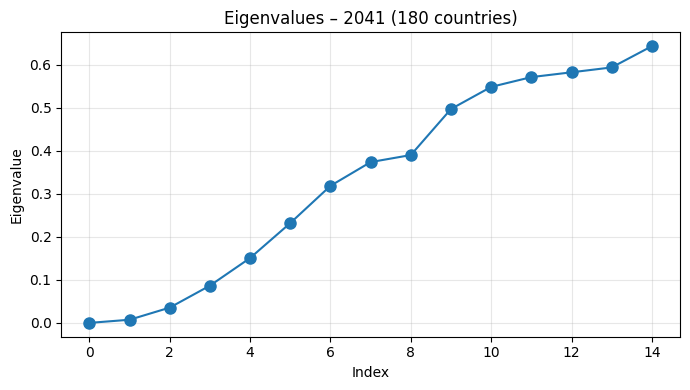

  Eigenvalues[:15]: [-0.      0.0073  0.0356  0.0867  0.151   0.2322  0.3189  0.3741  0.3905
  0.4976  0.549   0.5718  0.583   0.5943  0.6438]
  Gaps: [0.0073 0.0283 0.0511 0.0643 0.0813 0.0866 0.0552 0.0164 0.1071 0.0514
 0.0228 0.0112 0.0113 0.0494]
  → Optimal number of clusters (eigengap): **9**
  Cluster sizes: [21 26 24 23 14 18 18 20 16]

Year: 2042


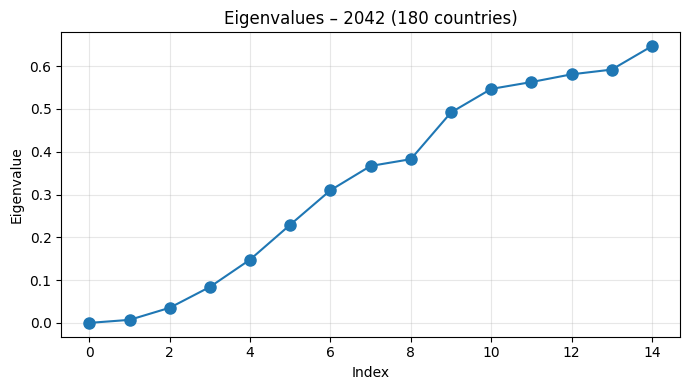

  Eigenvalues[:15]: [0.     0.0071 0.0354 0.084  0.1479 0.2295 0.31   0.3668 0.3826 0.4918
 0.5468 0.5628 0.5809 0.592  0.6467]
  Gaps: [0.0071 0.0283 0.0487 0.0639 0.0816 0.0804 0.0568 0.0158 0.1091 0.055
 0.0161 0.0181 0.0111 0.0548]
  → Optimal number of clusters (eigengap): **9**
  Cluster sizes: [25 23 18 26 19 13 22 17 17]

Year: 2043


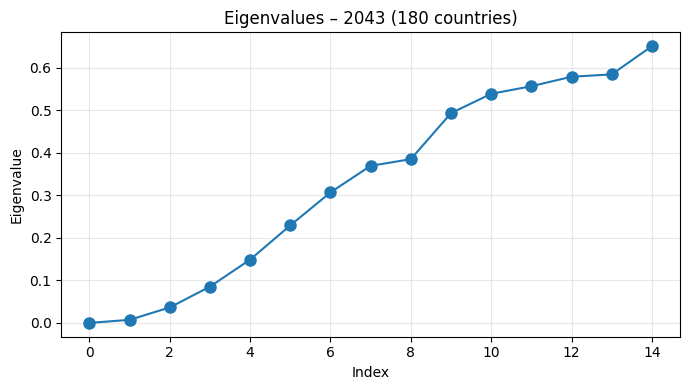

  Eigenvalues[:15]: [-0.      0.0071  0.0364  0.0852  0.1488  0.2293  0.307   0.3695  0.3852
  0.4934  0.5389  0.5568  0.5791  0.5846  0.651 ]
  Gaps: [0.0071 0.0292 0.0489 0.0636 0.0805 0.0776 0.0626 0.0156 0.1082 0.0455
 0.0179 0.0223 0.0055 0.0664]
  → Optimal number of clusters (eigengap): **9**
  Cluster sizes: [25 17 26 23 13 17 19 22 18]

Year: 2044


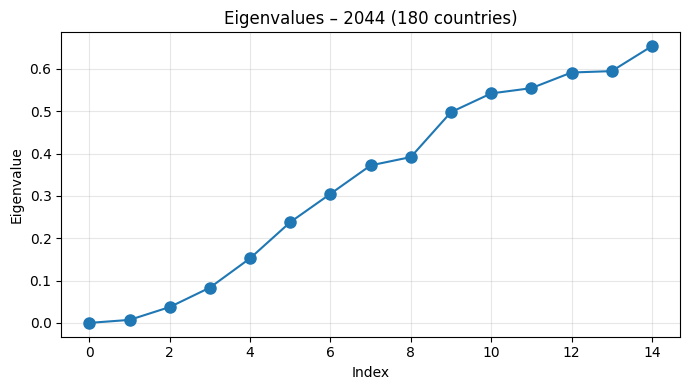

  Eigenvalues[:15]: [-0.      0.0071  0.0375  0.0834  0.1526  0.238   0.3049  0.3721  0.3917
  0.4978  0.5421  0.5545  0.5915  0.5948  0.6537]
  Gaps: [0.0071 0.0304 0.0459 0.0692 0.0854 0.0669 0.0672 0.0196 0.1061 0.0443
 0.0124 0.037  0.0033 0.059 ]
  → Optimal number of clusters (eigengap): **9**
  Cluster sizes: [23 26 24 24 13 18 17 16 19]

Year: 2045


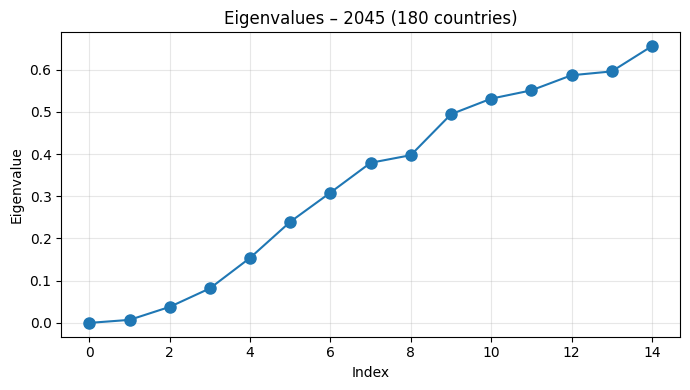

  Eigenvalues[:15]: [-0.      0.0071  0.038   0.0819  0.1541  0.2396  0.3088  0.3794  0.3974
  0.4944  0.5314  0.551   0.5868  0.5959  0.6558]
  Gaps: [0.0071 0.0308 0.0439 0.0723 0.0855 0.0692 0.0706 0.018  0.097  0.0369
 0.0196 0.0358 0.0091 0.0599]
  → Optimal number of clusters (eigengap): **9**
  Cluster sizes: [23 21 20 15 13 27 18 17 26]

Year: 2046


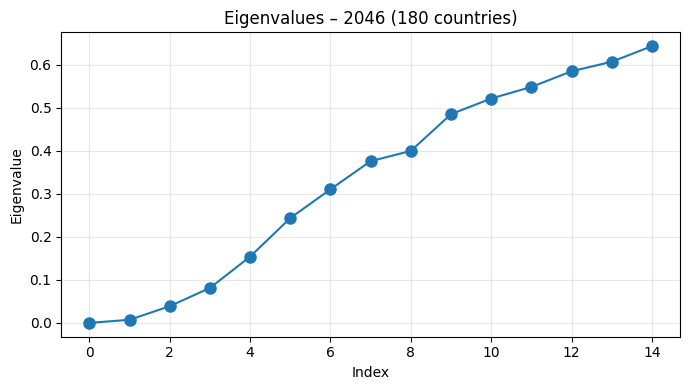

  Eigenvalues[:15]: [-0.      0.0072  0.0388  0.0812  0.1539  0.2435  0.3104  0.3758  0.3995
  0.4849  0.5213  0.5481  0.5845  0.6066  0.6429]
  Gaps: [0.0072 0.0316 0.0424 0.0726 0.0896 0.0669 0.0654 0.0237 0.0853 0.0364
 0.0268 0.0364 0.0221 0.0363]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [58 32 28 25 37]

Year: 2047


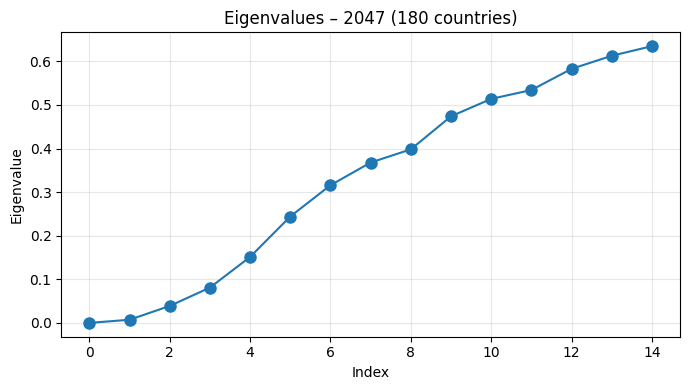

  Eigenvalues[:15]: [0.     0.0072 0.0389 0.081  0.1513 0.244  0.3158 0.3679 0.3981 0.4739
 0.5139 0.5342 0.5827 0.6128 0.6348]
  Gaps: [0.0072 0.0317 0.042  0.0704 0.0927 0.0718 0.052  0.0302 0.0758 0.04
 0.0203 0.0485 0.03   0.0221]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [58 32 25 28 37]

Year: 2048


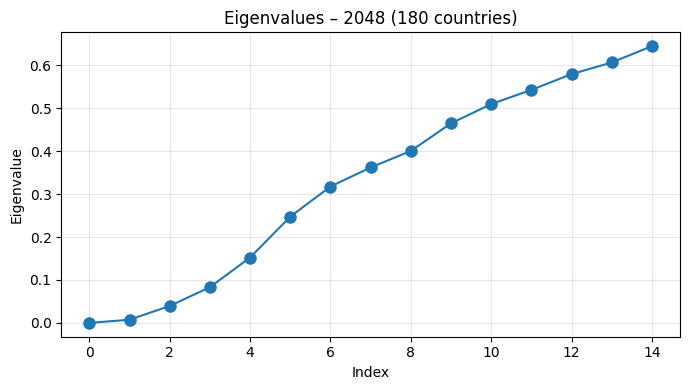

  Eigenvalues[:15]: [0.     0.0074 0.0395 0.0833 0.1524 0.2476 0.3178 0.3623 0.4007 0.4651
 0.5099 0.5431 0.5798 0.607  0.645 ]
  Gaps: [0.0074 0.0321 0.0438 0.0691 0.0952 0.0702 0.0445 0.0384 0.0645 0.0448
 0.0331 0.0368 0.0271 0.038 ]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [49 49 25 29 28]

Year: 2049


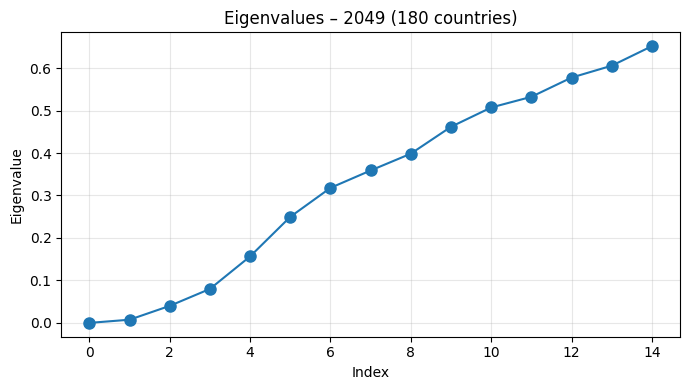

  Eigenvalues[:15]: [-0.      0.0075  0.0401  0.08    0.1566  0.2498  0.3179  0.3589  0.3985
  0.4617  0.5072  0.5323  0.5776  0.6056  0.6516]
  Gaps: [0.0075 0.0326 0.0399 0.0766 0.0932 0.0682 0.041  0.0396 0.0633 0.0455
 0.0251 0.0453 0.028  0.046 ]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [51 48 25 28 28]

Year: 2050


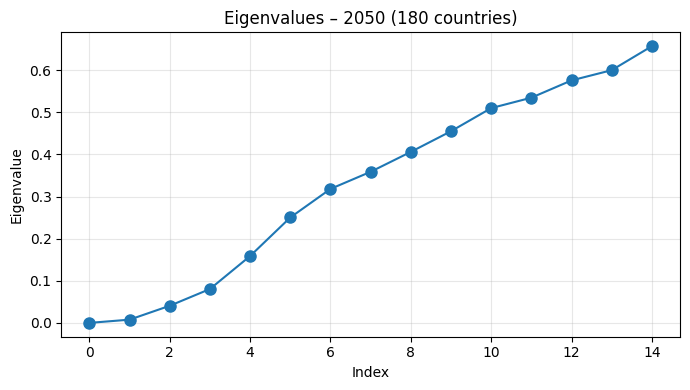

  Eigenvalues[:15]: [-0.      0.0077  0.0407  0.0804  0.1588  0.2503  0.3182  0.3589  0.4061
  0.4552  0.5101  0.5349  0.5759  0.6002  0.6572]
  Gaps: [0.0077 0.033  0.0398 0.0784 0.0915 0.0679 0.0407 0.0473 0.0491 0.0549
 0.0248 0.0411 0.0243 0.057 ]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [55 32 25 28 40]

Year: 2051


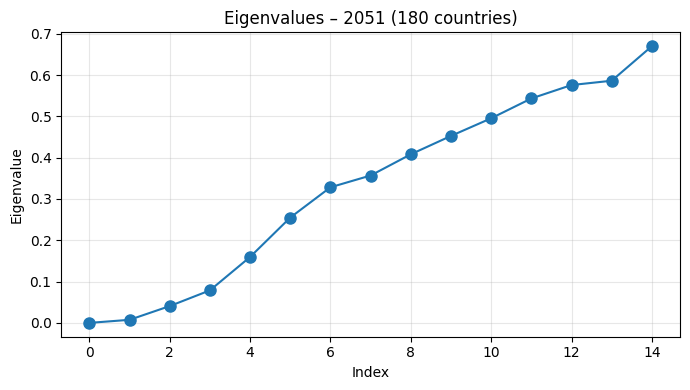

  Eigenvalues[:15]: [-0.      0.0075  0.0407  0.0787  0.1596  0.255   0.3283  0.3568  0.4081
  0.4526  0.4953  0.5433  0.5758  0.5862  0.6699]
  Gaps: [0.0075 0.0333 0.038  0.0809 0.0954 0.0733 0.0285 0.0513 0.0445 0.0427
 0.048  0.0325 0.0104 0.0837]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [53 32 25 28 42]

Year: 2052


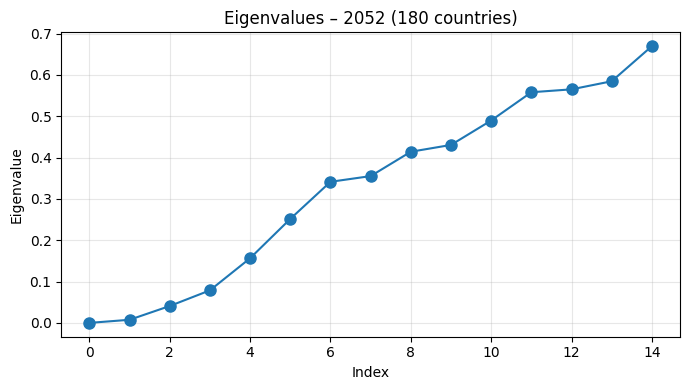

  Eigenvalues[:15]: [-0.      0.0075  0.0408  0.0787  0.1564  0.2515  0.3413  0.3551  0.414
  0.4305  0.4896  0.5579  0.565   0.5845  0.6694]
  Gaps: [0.0075 0.0333 0.0379 0.0777 0.0951 0.0898 0.0138 0.0589 0.0165 0.0591
 0.0684 0.007  0.0195 0.0849]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [42 31 25 28 54]

Year: 2053


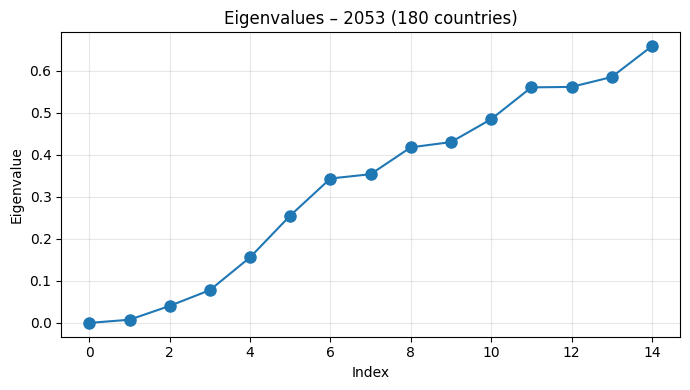

  Eigenvalues[:15]: [0.     0.0075 0.0405 0.078  0.1561 0.2555 0.3436 0.3539 0.4178 0.4303
 0.4848 0.5605 0.5617 0.5851 0.6586]
  Gaps: [0.0075 0.033  0.0376 0.0781 0.0994 0.0882 0.0102 0.0639 0.0125 0.0545
 0.0757 0.0011 0.0235 0.0735]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [45 31 25 28 51]

Year: 2054


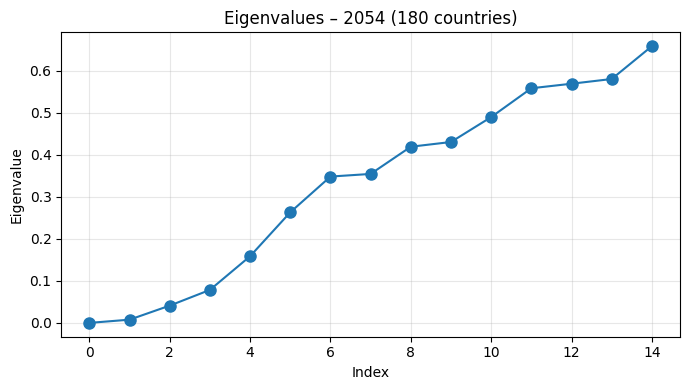

  Eigenvalues[:15]: [-0.      0.0077  0.0411  0.0786  0.1588  0.2634  0.3484  0.3547  0.4195
  0.4307  0.4901  0.5587  0.5695  0.5807  0.6589]
  Gaps: [0.0077 0.0335 0.0374 0.0802 0.1046 0.0851 0.0063 0.0648 0.0112 0.0594
 0.0686 0.0108 0.0112 0.0782]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [45 31 25 51 28]

Year: 2055


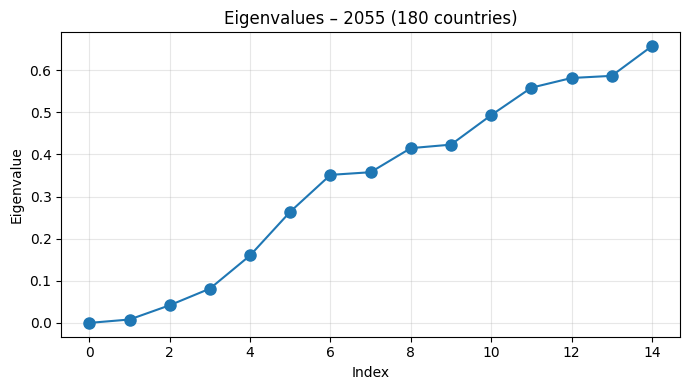

  Eigenvalues[:15]: [0.     0.008  0.0419 0.0814 0.1601 0.264  0.3514 0.3577 0.4148 0.4231
 0.4932 0.5583 0.5813 0.5864 0.6569]
  Gaps: [0.008  0.0339 0.0395 0.0787 0.1039 0.0874 0.0063 0.0572 0.0083 0.07
 0.0651 0.023  0.0051 0.0705]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [49 33 25 28 45]

Year: 2056


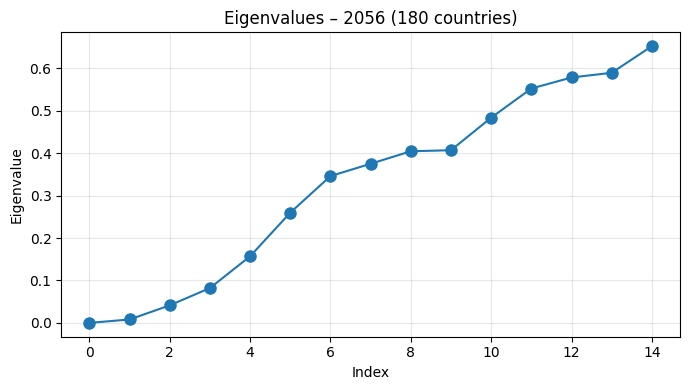

  Eigenvalues[:15]: [0.     0.008  0.0414 0.0821 0.1571 0.2599 0.3462 0.3752 0.4046 0.4072
 0.4839 0.5526 0.5786 0.5897 0.6525]
  Gaps: [0.008  0.0334 0.0407 0.0749 0.1029 0.0862 0.029  0.0295 0.0025 0.0767
 0.0687 0.026  0.0111 0.0628]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [49 33 25 28 45]

Year: 2057


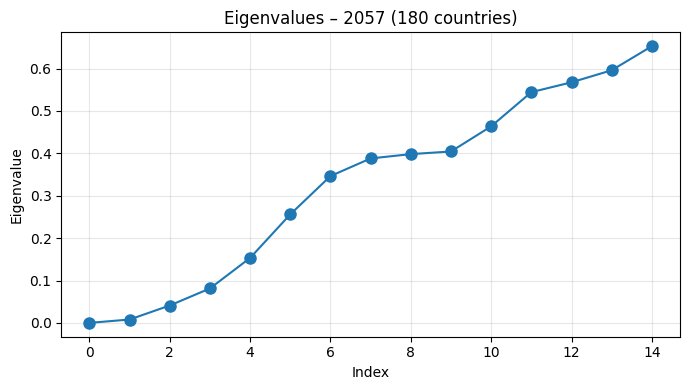

  Eigenvalues[:15]: [0.     0.008  0.041  0.0812 0.1533 0.2561 0.3464 0.388  0.3982 0.4044
 0.4637 0.5444 0.5676 0.596  0.6528]
  Gaps: [0.008  0.0331 0.0402 0.072  0.1028 0.0903 0.0416 0.0102 0.0062 0.0593
 0.0806 0.0232 0.0285 0.0568]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [49 33 25 28 45]

Year: 2058


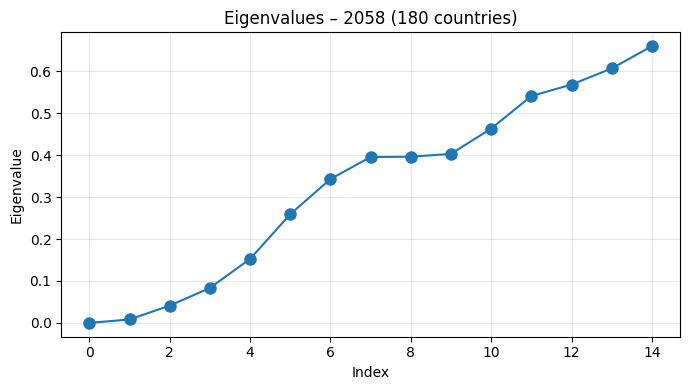

  Eigenvalues[:15]: [0.     0.0082 0.0412 0.0833 0.1526 0.2592 0.343  0.3955 0.3962 0.4031
 0.4634 0.5409 0.5684 0.6068 0.6599]
  Gaps: [0.0082 0.0331 0.042  0.0694 0.1066 0.0838 0.0525 0.0007 0.0068 0.0603
 0.0776 0.0274 0.0384 0.0531]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [46 33 48 26 27]

Year: 2059


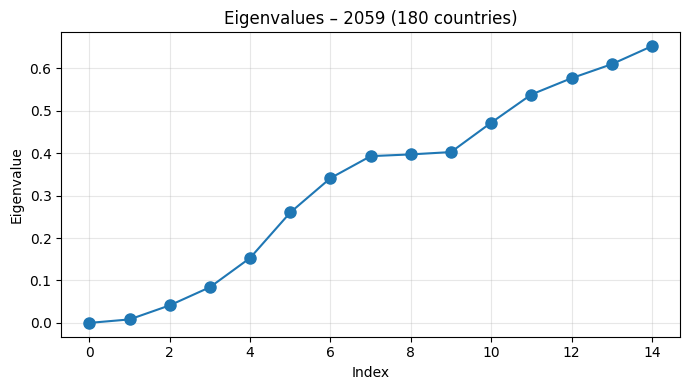

  Eigenvalues[:15]: [-0.      0.0082  0.0413  0.0841  0.153   0.2601  0.3411  0.3929  0.397
  0.4025  0.4717  0.5381  0.5765  0.6095  0.652 ]
  Gaps: [0.0082 0.0331 0.0428 0.0689 0.1072 0.0809 0.0518 0.0041 0.0055 0.0692
 0.0664 0.0384 0.0329 0.0425]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [45 33 27 49 26]

Year: 2060


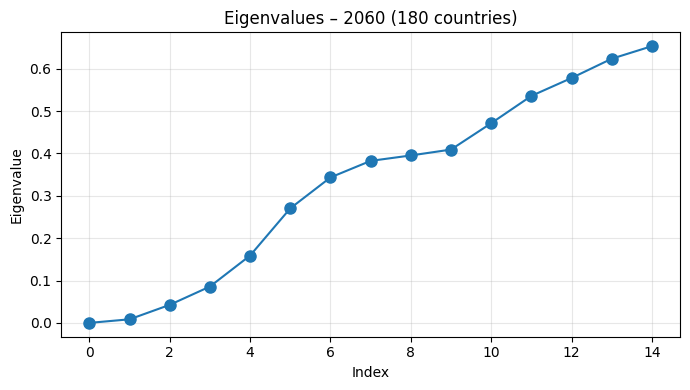

  Eigenvalues[:15]: [0.     0.0085 0.0426 0.0858 0.159  0.2704 0.3433 0.3824 0.3952 0.4091
 0.4712 0.5357 0.578  0.6235 0.6531]
  Gaps: [0.0085 0.0341 0.0432 0.0732 0.1114 0.073  0.0391 0.0128 0.0139 0.0622
 0.0645 0.0423 0.0455 0.0297]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [45 33 27 49 26]

Year: 2061


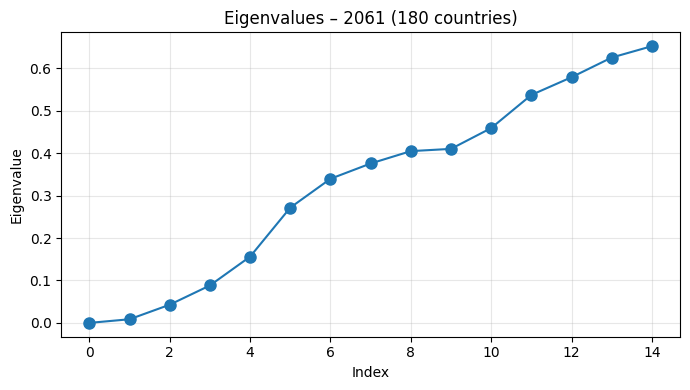

  Eigenvalues[:15]: [-0.      0.0086  0.0429  0.0882  0.1561  0.2717  0.3397  0.3757  0.4049
  0.4102  0.4592  0.5373  0.5791  0.6255  0.6523]
  Gaps: [0.0086 0.0343 0.0454 0.0679 0.1156 0.068  0.036  0.0292 0.0053 0.049
 0.0781 0.0417 0.0464 0.0268]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [48 44 27 26 35]

Year: 2062


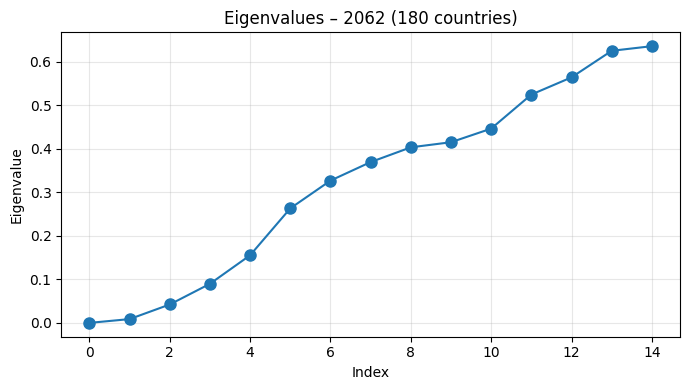

  Eigenvalues[:15]: [0.     0.0087 0.0423 0.0898 0.1554 0.2631 0.3269 0.3695 0.4034 0.4151
 0.4464 0.5246 0.5642 0.6252 0.6358]
  Gaps: [0.0087 0.0336 0.0475 0.0656 0.1078 0.0638 0.0426 0.0339 0.0117 0.0313
 0.0783 0.0395 0.061  0.0106]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [44 35 48 27 26]

Year: 2063


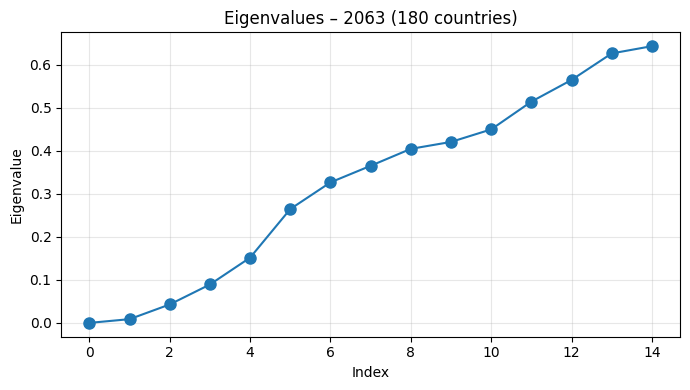

  Eigenvalues[:15]: [0.     0.0087 0.0429 0.0893 0.1517 0.2647 0.3268 0.3653 0.4047 0.4208
 0.45   0.5145 0.565  0.6267 0.6435]
  Gaps: [0.0087 0.0342 0.0464 0.0624 0.113  0.062  0.0385 0.0394 0.0161 0.0291
 0.0645 0.0505 0.0617 0.0169]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [53 30 44 27 26]

Year: 2064


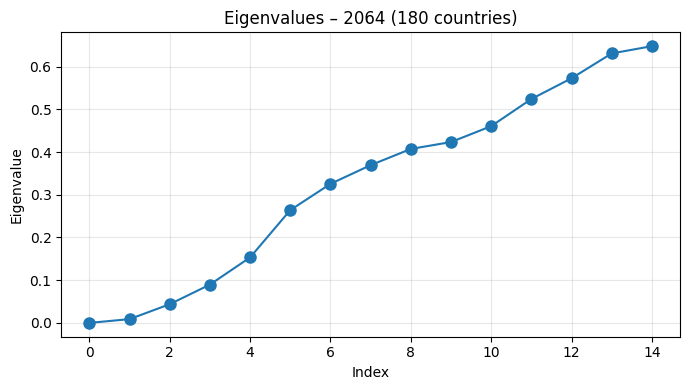

  Eigenvalues[:15]: [0.     0.0088 0.0438 0.0897 0.1533 0.264  0.3255 0.3693 0.4072 0.4234
 0.4606 0.5242 0.5727 0.6308 0.6479]
  Gaps: [0.0088 0.035  0.0459 0.0636 0.1108 0.0615 0.0438 0.0379 0.0162 0.0372
 0.0636 0.0485 0.0582 0.017 ]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [53 44 27 26 30]

Year: 2065


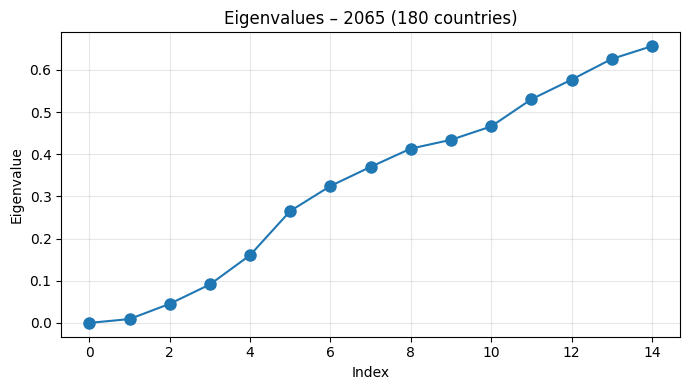

  Eigenvalues[:15]: [-0.      0.0091  0.0453  0.0911  0.1606  0.2653  0.3245  0.3699  0.4132
  0.4341  0.4658  0.5302  0.5766  0.6258  0.6561]
  Gaps: [0.0091 0.0362 0.0458 0.0696 0.1047 0.0592 0.0454 0.0433 0.0208 0.0318
 0.0644 0.0464 0.0491 0.0303]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [42 27 26 54 31]

Year: 2066


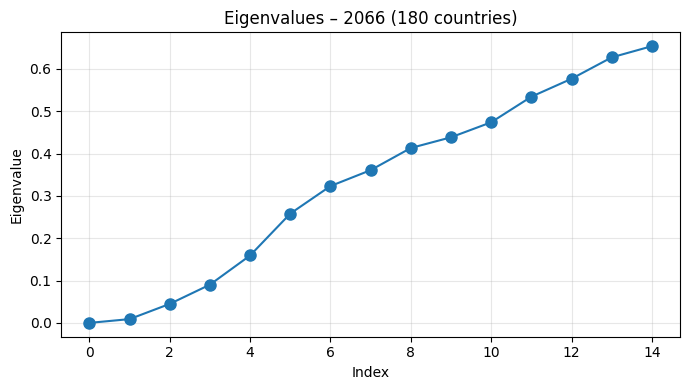

  Eigenvalues[:15]: [-0.      0.0089  0.0449  0.0903  0.1592  0.2581  0.3232  0.3608  0.4131
  0.4384  0.4738  0.5343  0.5766  0.6272  0.6537]
  Gaps: [0.0089 0.0359 0.0454 0.0689 0.0989 0.065  0.0376 0.0523 0.0253 0.0354
 0.0604 0.0424 0.0506 0.0265]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [53 33 41 27 26]

Year: 2067


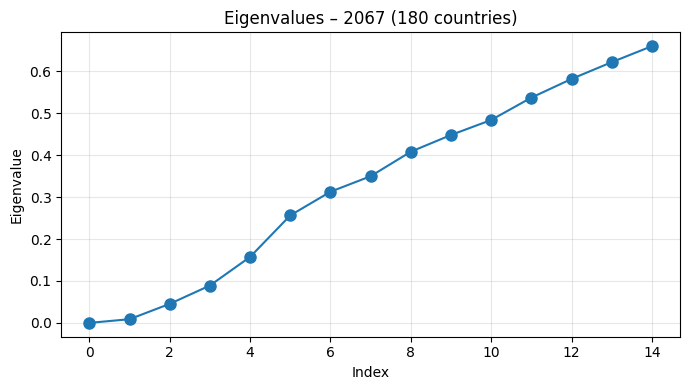

  Eigenvalues[:15]: [0.     0.0088 0.0454 0.0892 0.1575 0.2566 0.313  0.3501 0.4086 0.4485
 0.4843 0.5376 0.5822 0.6222 0.6604]
  Gaps: [0.0088 0.0366 0.0438 0.0682 0.0991 0.0564 0.0371 0.0585 0.0399 0.0358
 0.0534 0.0446 0.04   0.0382]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [55 28 27 39 31]

Year: 2068


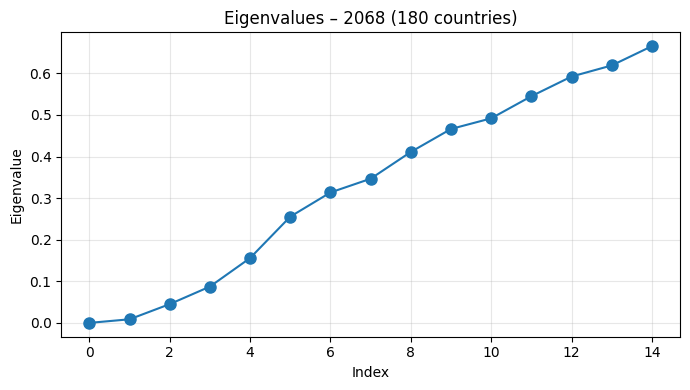

  Eigenvalues[:15]: [-0.      0.0087  0.0452  0.0873  0.1559  0.2555  0.3136  0.3467  0.4111
  0.4663  0.4919  0.5451  0.5924  0.619   0.6654]
  Gaps: [0.0087 0.0365 0.0422 0.0686 0.0996 0.0581 0.0331 0.0644 0.0553 0.0256
 0.0532 0.0473 0.0267 0.0464]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [37 30 27 58 28]

Year: 2069


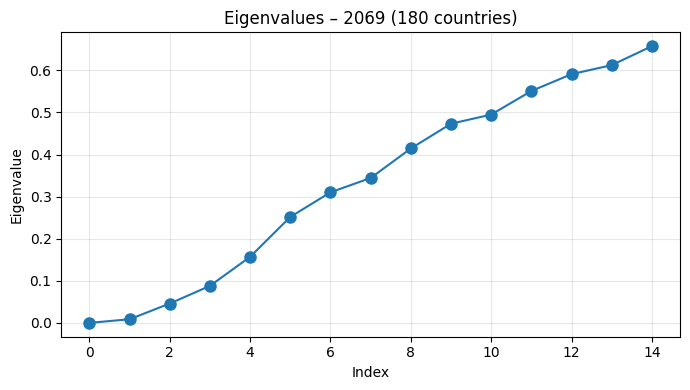

  Eigenvalues[:15]: [-0.      0.0086  0.046   0.0879  0.1569  0.2517  0.3102  0.3442  0.4143
  0.4731  0.4948  0.5509  0.5909  0.6123  0.6573]
  Gaps: [0.0086 0.0373 0.042  0.069  0.0948 0.0585 0.034  0.0701 0.0588 0.0217
 0.0561 0.04   0.0214 0.045 ]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [35 29 27 29 60]

Year: 2070


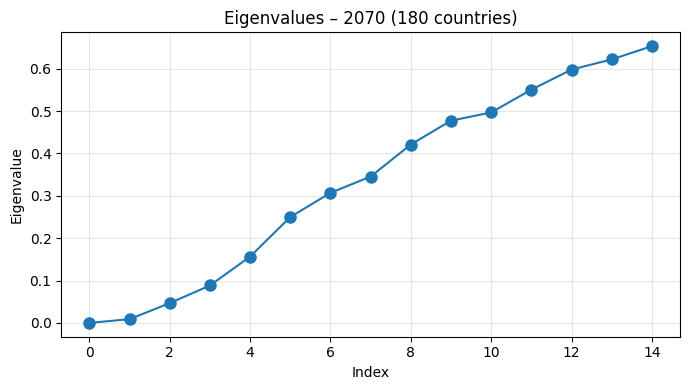

  Eigenvalues[:15]: [-0.      0.0088  0.0467  0.0883  0.1565  0.2498  0.307   0.3454  0.4211
  0.4774  0.4968  0.5505  0.598   0.622   0.6533]
  Gaps: [0.0088 0.0379 0.0416 0.0682 0.0933 0.0572 0.0384 0.0757 0.0563 0.0194
 0.0537 0.0475 0.024  0.0313]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [58 32 27 28 35]

Year: 2071


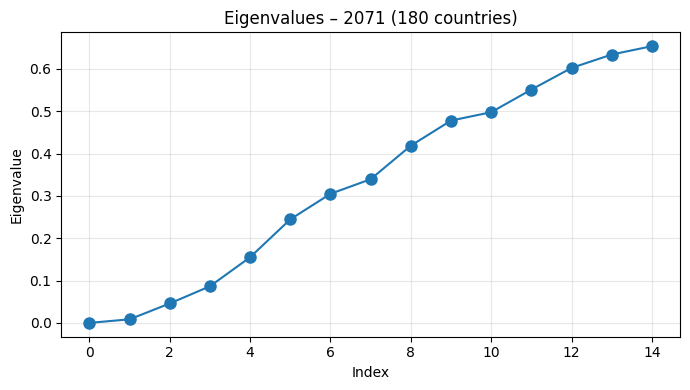

  Eigenvalues[:15]: [-0.      0.0084  0.0459  0.0865  0.1551  0.2447  0.305   0.3395  0.4187
  0.478   0.4978  0.5513  0.6024  0.6341  0.6539]
  Gaps: [0.0084 0.0375 0.0406 0.0686 0.0896 0.0603 0.0345 0.0792 0.0593 0.0198
 0.0534 0.0512 0.0316 0.0198]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [35 32 27 26 60]

Year: 2072


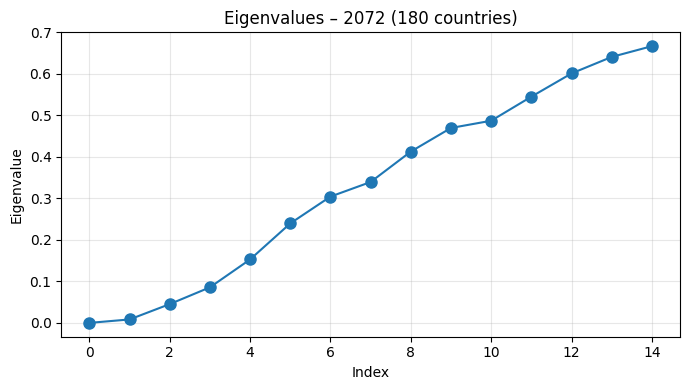

  Eigenvalues[:15]: [0.     0.0083 0.0453 0.0857 0.1529 0.2398 0.3044 0.3395 0.4129 0.4698
 0.4872 0.5452 0.6012 0.641  0.6669]
  Gaps: [0.0083 0.037  0.0404 0.0672 0.0868 0.0646 0.0352 0.0733 0.0569 0.0174
 0.058  0.056  0.0398 0.0259]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [34 33 27 26 60]

Year: 2073


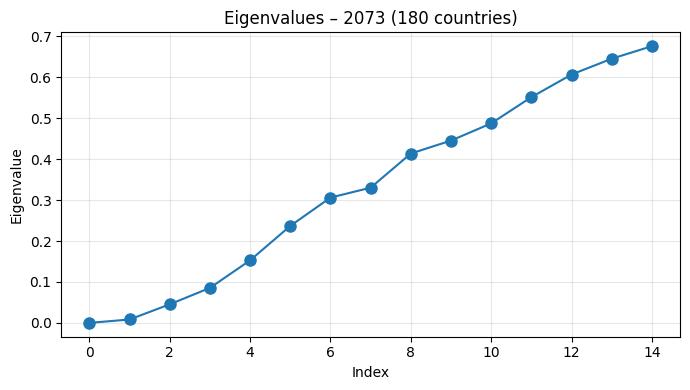

  Eigenvalues[:15]: [0.     0.0083 0.0454 0.0855 0.1528 0.2369 0.3061 0.3303 0.4137 0.4453
 0.4874 0.5514 0.6067 0.6454 0.676 ]
  Gaps: [0.0083 0.0371 0.0401 0.0673 0.0841 0.0692 0.0242 0.0835 0.0316 0.0421
 0.0641 0.0553 0.0386 0.0307]
  → Optimal number of clusters (eigengap): **5**
  Cluster sizes: [33 33 27 27 60]

Year: 2074


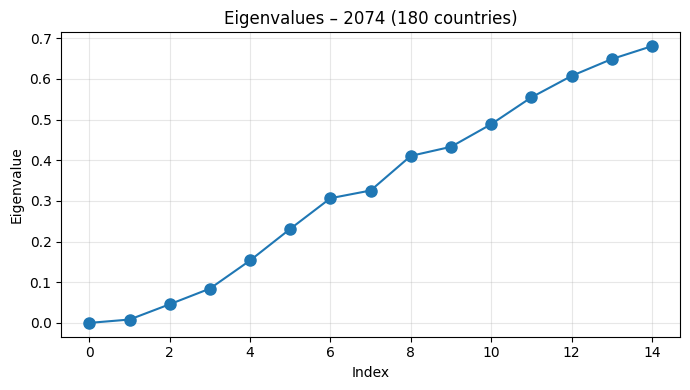

  Eigenvalues[:15]: [-0.      0.0082  0.0459  0.0843  0.1536  0.2313  0.3067  0.3256  0.4108
  0.4331  0.4886  0.5547  0.6074  0.6489  0.6806]
  Gaps: [0.0082 0.0376 0.0385 0.0693 0.0777 0.0753 0.019  0.0851 0.0223 0.0556
 0.066  0.0527 0.0415 0.0318]
  → Optimal number of clusters (eigengap): **8**
  Cluster sizes: [20 31 21 23 18 19 25 23]

Year: 2075


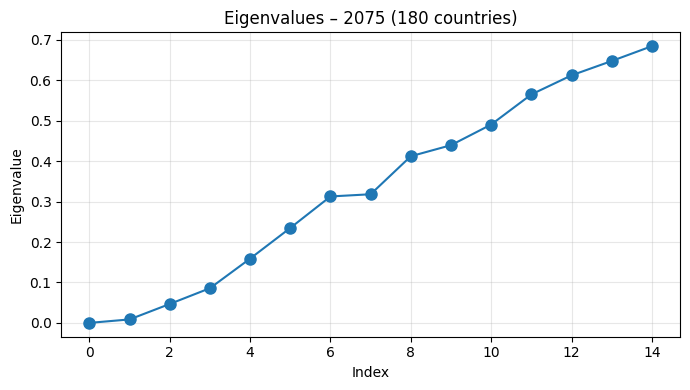

  Eigenvalues[:15]: [-0.      0.0086  0.0468  0.0858  0.159   0.2348  0.3128  0.3182  0.4122
  0.4396  0.4906  0.5651  0.6123  0.6478  0.6845]
  Gaps: [0.0086 0.0382 0.039  0.0732 0.0758 0.0779 0.0054 0.094  0.0274 0.051
 0.0745 0.0472 0.0355 0.0367]
  → Optimal number of clusters (eigengap): **8**
  Cluster sizes: [20 17 23 30 20 26 20 24]

Year: 2076


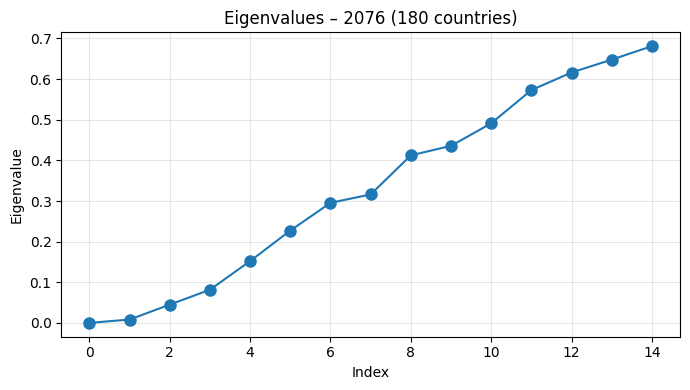

  Eigenvalues[:15]: [0.     0.0082 0.045  0.0816 0.1521 0.2272 0.2955 0.3162 0.4123 0.4358
 0.4912 0.573  0.6163 0.648  0.6811]
  Gaps: [0.0082 0.0368 0.0366 0.0705 0.0751 0.0683 0.0207 0.0961 0.0235 0.0554
 0.0818 0.0433 0.0317 0.0331]
  → Optimal number of clusters (eigengap): **8**
  Cluster sizes: [23 26 27 20 20 20 25 19]

Year: 2077


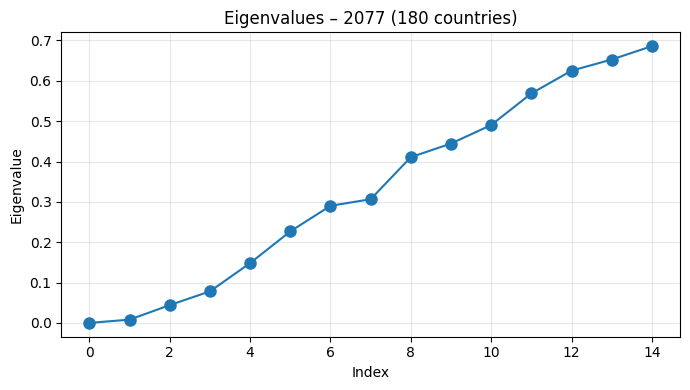

  Eigenvalues[:15]: [-0.      0.008   0.0441  0.0781  0.1482  0.2268  0.2902  0.3065  0.4108
  0.4446  0.4904  0.5688  0.6252  0.6529  0.6859]
  Gaps: [0.008  0.0361 0.034  0.0701 0.0786 0.0634 0.0163 0.1043 0.0338 0.0458
 0.0784 0.0564 0.0277 0.0331]
  → Optimal number of clusters (eigengap): **8**
  Cluster sizes: [26 29 23 24 19 19 20 20]

Year: 2078


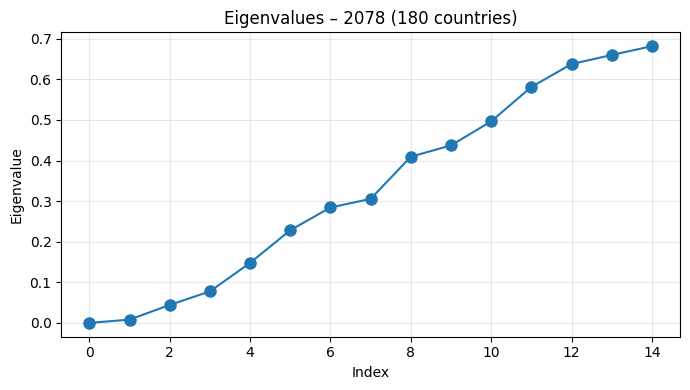

  Eigenvalues[:15]: [-0.      0.008   0.0443  0.0776  0.1478  0.2283  0.2842  0.3055  0.4093
  0.4372  0.4964  0.5811  0.6376  0.6599  0.6816]
  Gaps: [0.008  0.0362 0.0333 0.0703 0.0804 0.056  0.0212 0.1038 0.0279 0.0592
 0.0848 0.0564 0.0223 0.0218]
  → Optimal number of clusters (eigengap): **8**
  Cluster sizes: [19 28 23 23 27 21 19 20]

Year: 2079


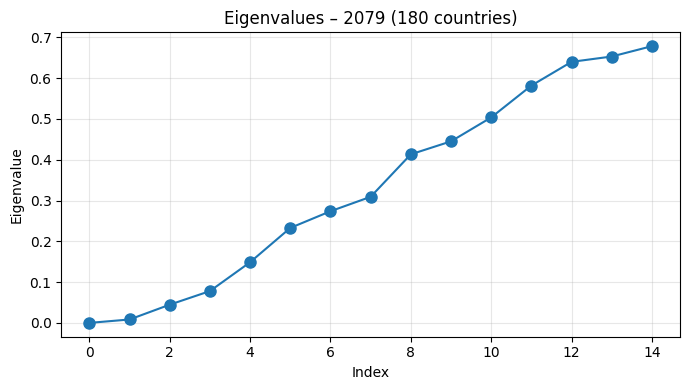

  Eigenvalues[:15]: [-0.      0.0083  0.0447  0.078   0.1487  0.2328  0.2737  0.3091  0.4132
  0.445   0.5037  0.5817  0.6399  0.653   0.6784]
  Gaps: [0.0083 0.0363 0.0333 0.0708 0.0841 0.0409 0.0354 0.1042 0.0318 0.0586
 0.0781 0.0582 0.0131 0.0254]
  → Optimal number of clusters (eigengap): **8**
  Cluster sizes: [23 23 20 20 27 19 29 19]

Year: 2080


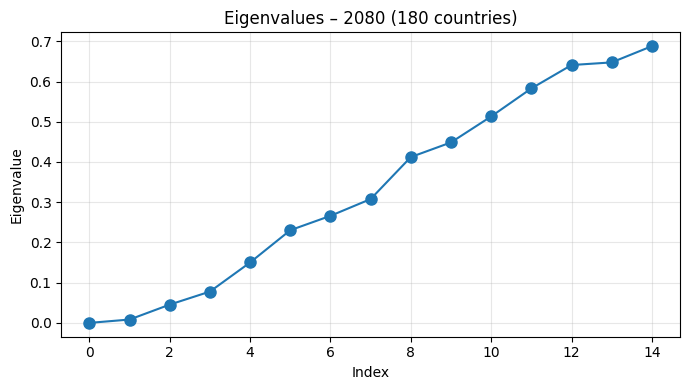

  Eigenvalues[:15]: [-0.      0.0083  0.0455  0.0778  0.1502  0.2304  0.2661  0.3078  0.4122
  0.4487  0.5132  0.5829  0.641   0.6476  0.6879]
  Gaps: [0.0083 0.0371 0.0324 0.0724 0.0802 0.0357 0.0417 0.1044 0.0364 0.0646
 0.0697 0.0581 0.0065 0.0404]
  → Optimal number of clusters (eigengap): **8**
  Cluster sizes: [20 27 23 20 23 19 19 29]

Year: 2081


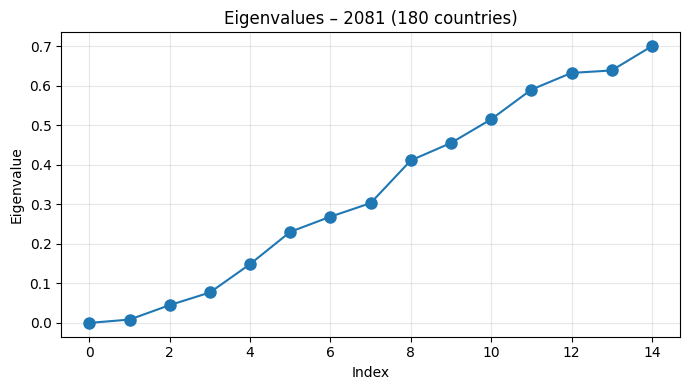

  Eigenvalues[:15]: [0.     0.0084 0.045  0.0769 0.1486 0.2302 0.2686 0.3029 0.4108 0.4549
 0.5148 0.5898 0.632  0.6382 0.6996]
  Gaps: [0.0084 0.0366 0.0319 0.0717 0.0816 0.0383 0.0343 0.1079 0.0441 0.0599
 0.0749 0.0422 0.0062 0.0614]
  → Optimal number of clusters (eigengap): **8**
  Cluster sizes: [21 27 20 28 19 20 23 22]

Year: 2082


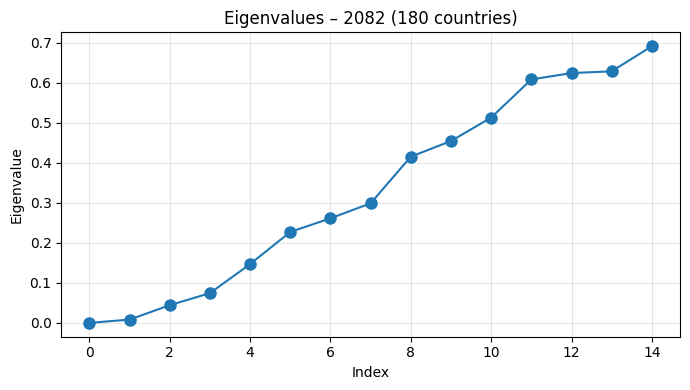

  Eigenvalues[:15]: [-0.      0.0082  0.0443  0.0743  0.1469  0.2272  0.2613  0.2988  0.4153
  0.4543  0.5129  0.6082  0.6241  0.6284  0.6913]
  Gaps: [0.0082 0.0361 0.03   0.0726 0.0803 0.0341 0.0375 0.1165 0.0391 0.0585
 0.0953 0.016  0.0043 0.0629]
  → Optimal number of clusters (eigengap): **8**
  Cluster sizes: [23 22 29 22 17 21 19 27]

Year: 2083


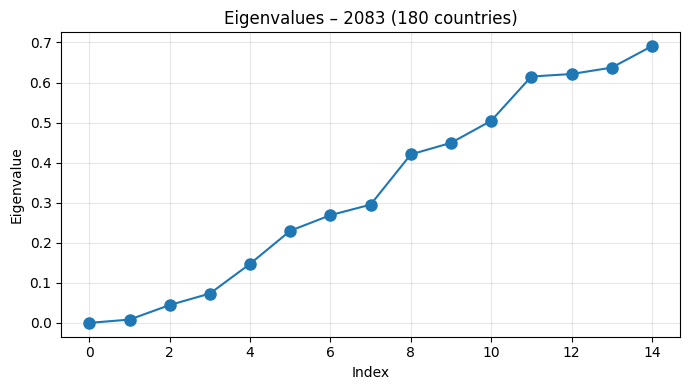

  Eigenvalues[:15]: [-0.      0.0083  0.0446  0.0733  0.1475  0.23    0.2689  0.2953  0.4206
  0.4494  0.5045  0.615   0.6212  0.6372  0.6908]
  Gaps: [0.0083 0.0363 0.0287 0.0742 0.0825 0.0389 0.0264 0.1253 0.0288 0.0551
 0.1105 0.0062 0.016  0.0535]
  → Optimal number of clusters (eigengap): **8**
  Cluster sizes: [21 28 27 23 20 20 21 20]

Year: 2084


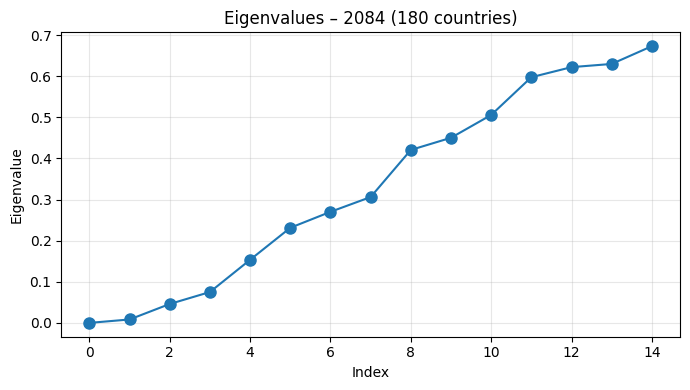

  Eigenvalues[:15]: [-0.      0.0083  0.046   0.0751  0.1535  0.2313  0.2701  0.3061  0.4207
  0.4502  0.5058  0.5976  0.6221  0.6298  0.6731]
  Gaps: [0.0083 0.0377 0.0291 0.0784 0.0778 0.0388 0.036  0.1145 0.0296 0.0555
 0.0918 0.0245 0.0078 0.0432]
  → Optimal number of clusters (eigengap): **8**
  Cluster sizes: [21 21 28 22 27 18 22 21]

Year: 2085


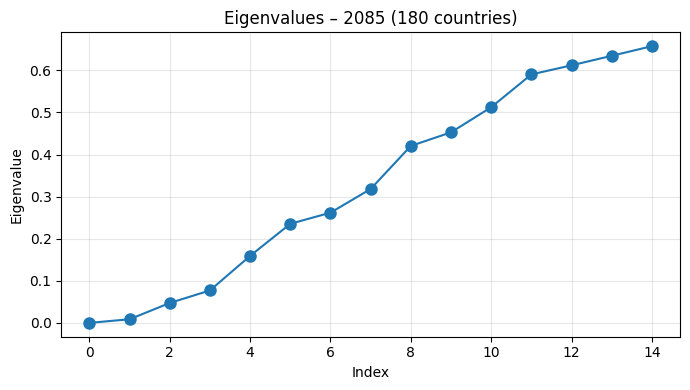

  Eigenvalues[:15]: [0.     0.0087 0.0473 0.0771 0.1591 0.2354 0.2619 0.3181 0.4205 0.4527
 0.5124 0.5904 0.612  0.6346 0.6575]
  Gaps: [0.0087 0.0386 0.0298 0.0821 0.0763 0.0265 0.0562 0.1024 0.0322 0.0597
 0.078  0.0217 0.0226 0.0229]
  → Optimal number of clusters (eigengap): **8**
  Cluster sizes: [22 27 21 28 21 20 22 19]

Year: 2086


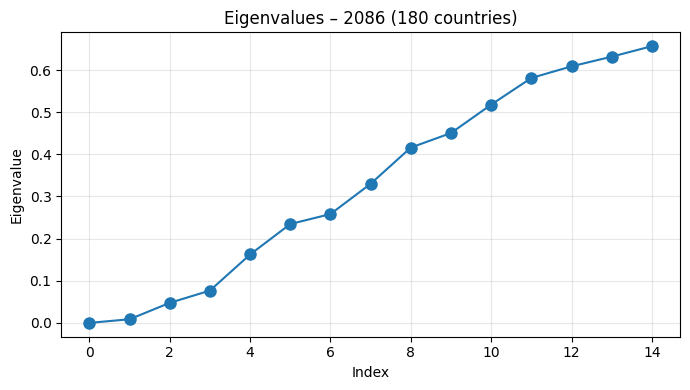

  Eigenvalues[:15]: [-0.      0.0086  0.0475  0.0767  0.1623  0.2345  0.2582  0.33    0.416
  0.4504  0.5178  0.5811  0.6087  0.6317  0.6566]
  Gaps: [0.0086 0.0389 0.0291 0.0857 0.0722 0.0237 0.0718 0.0859 0.0345 0.0674
 0.0633 0.0276 0.0229 0.0249]
  → Optimal number of clusters (eigengap): **8**
  Cluster sizes: [24 28 20 21 19 20 21 27]

Year: 2087


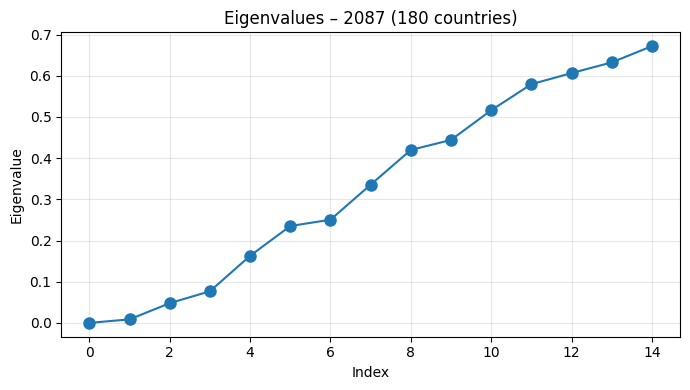

  Eigenvalues[:15]: [0.     0.0085 0.0479 0.0767 0.1628 0.2352 0.2505 0.3355 0.4198 0.4442
 0.5161 0.5794 0.6065 0.6324 0.6718]
  Gaps: [0.0085 0.0394 0.0288 0.0861 0.0723 0.0153 0.085  0.0843 0.0244 0.072
 0.0633 0.027  0.0259 0.0394]
  → Optimal number of clusters (eigengap): **4**
  Cluster sizes: [73 32 31 44]

Year: 2088


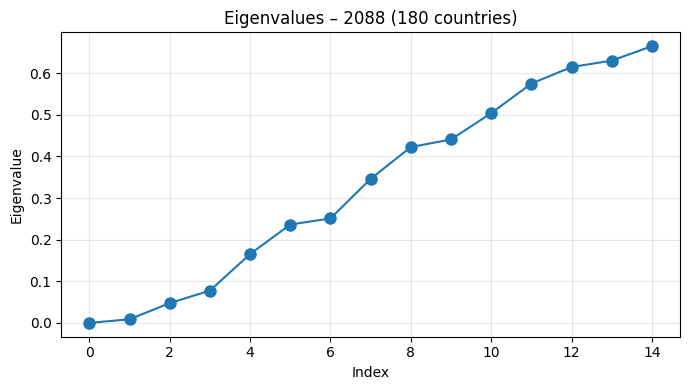

  Eigenvalues[:15]: [-0.      0.0087  0.0476  0.0775  0.1655  0.2363  0.251   0.3461  0.4225
  0.4408  0.5039  0.5751  0.6148  0.6302  0.665 ]
  Gaps: [0.0087 0.0389 0.03   0.088  0.0708 0.0147 0.0951 0.0764 0.0184 0.0631
 0.0711 0.0397 0.0154 0.0347]
  → Optimal number of clusters (eigengap): **7**
  Cluster sizes: [19 25 24 28 22 41 21]

Year: 2089


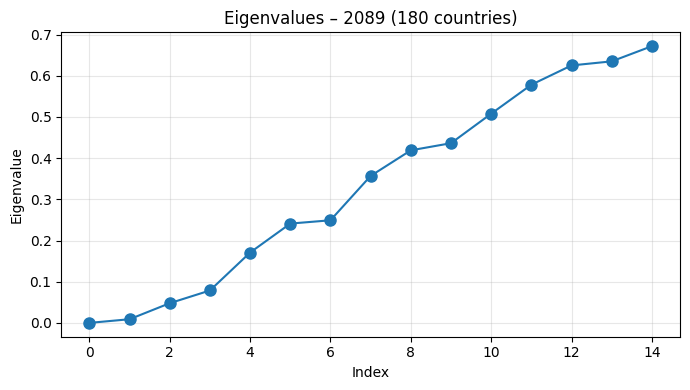

  Eigenvalues[:15]: [0.     0.0089 0.0478 0.0787 0.1708 0.2411 0.2492 0.3569 0.4191 0.4364
 0.508  0.5784 0.6252 0.6351 0.672 ]
  Gaps: [0.0089 0.0389 0.0309 0.0922 0.0703 0.008  0.1077 0.0622 0.0173 0.0716
 0.0704 0.0469 0.0099 0.0369]
  → Optimal number of clusters (eigengap): **7**
  Cluster sizes: [28 20 23 40 19 25 25]

Year: 2090


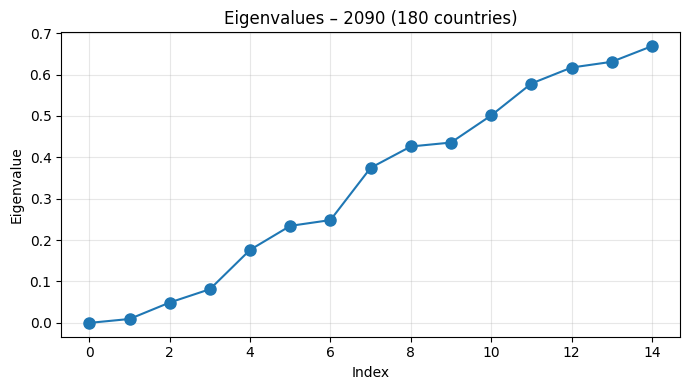

  Eigenvalues[:15]: [0.     0.0095 0.0492 0.0814 0.1765 0.2344 0.2484 0.3746 0.4261 0.4357
 0.5011 0.5782 0.6168 0.6307 0.6685]
  Gaps: [0.0095 0.0398 0.0322 0.0951 0.0579 0.014  0.1262 0.0516 0.0095 0.0655
 0.077  0.0386 0.0138 0.0378]
  → Optimal number of clusters (eigengap): **7**
  Cluster sizes: [27 23 30 37 19 20 24]

Year: 2091


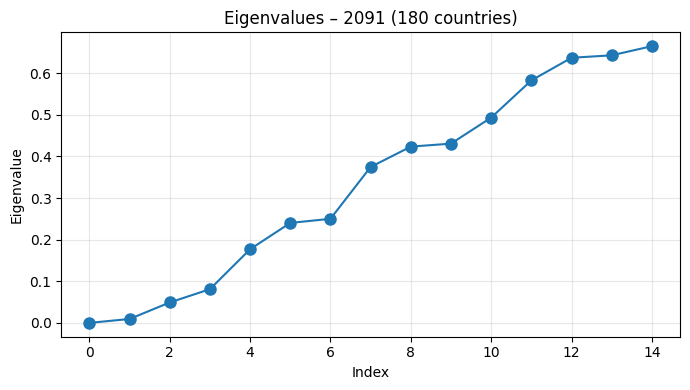

  Eigenvalues[:15]: [-0.      0.0094  0.0491  0.081   0.177   0.2402  0.2501  0.3747  0.4236
  0.4308  0.4934  0.5828  0.6372  0.6431  0.665 ]
  Gaps: [0.0094 0.0397 0.0319 0.0961 0.0632 0.0099 0.1245 0.0489 0.0072 0.0625
 0.0894 0.0544 0.0059 0.022 ]
  → Optimal number of clusters (eigengap): **7**
  Cluster sizes: [27 30 19 37 20 24 23]

Year: 2092


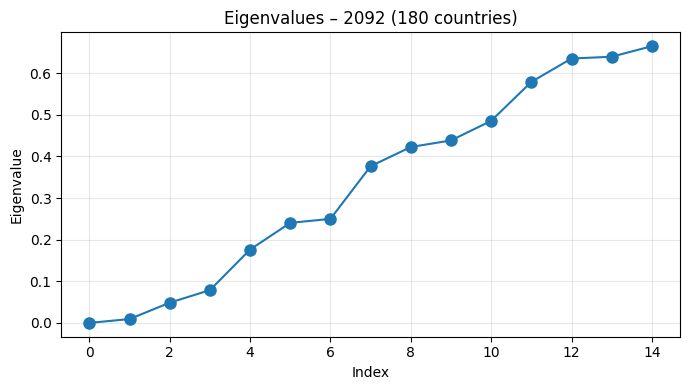

  Eigenvalues[:15]: [0.     0.0092 0.0486 0.0788 0.1763 0.2404 0.25   0.3766 0.4227 0.4385
 0.4856 0.5793 0.6354 0.6397 0.6651]
  Gaps: [0.0092 0.0393 0.0302 0.0976 0.0641 0.0096 0.1266 0.0461 0.0158 0.0471
 0.0937 0.0562 0.0043 0.0254]
  → Optimal number of clusters (eigengap): **7**
  Cluster sizes: [25 34 23 23 36 20 19]

Year: 2093


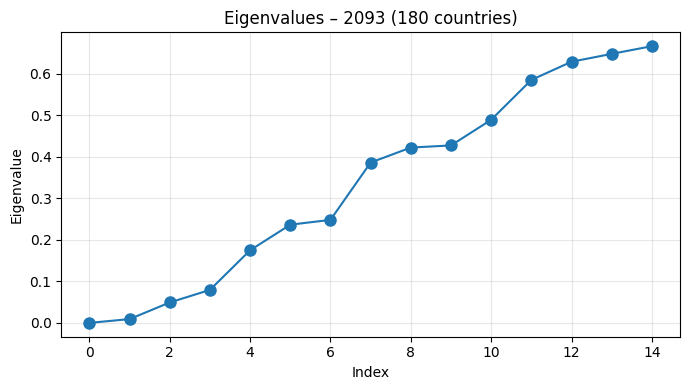

  Eigenvalues[:15]: [0.     0.0091 0.0491 0.0794 0.1748 0.2363 0.2479 0.3859 0.422  0.427
 0.4888 0.5847 0.6285 0.6474 0.6659]
  Gaps: [0.0091 0.04   0.0302 0.0954 0.0615 0.0116 0.138  0.0361 0.005  0.0618
 0.096  0.0437 0.0189 0.0185]
  → Optimal number of clusters (eigengap): **7**
  Cluster sizes: [35 19 25 23 18 25 35]

Year: 2094


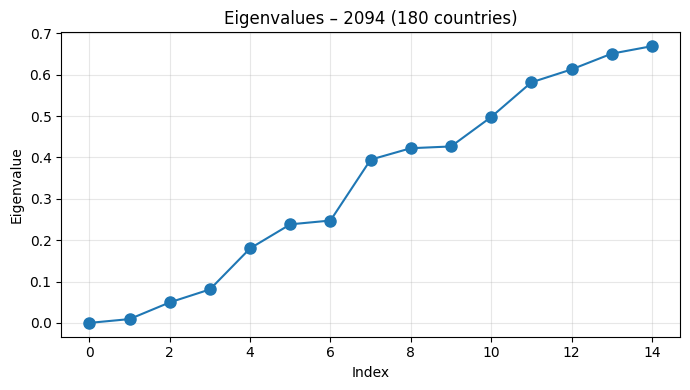

  Eigenvalues[:15]: [-0.      0.0092  0.0496  0.081   0.1802  0.2383  0.2475  0.3947  0.4224
  0.4266  0.4978  0.5816  0.6129  0.651   0.6691]
  Gaps: [0.0092 0.0404 0.0314 0.0992 0.0581 0.0092 0.1472 0.0277 0.0042 0.0712
 0.0838 0.0313 0.0381 0.0181]
  → Optimal number of clusters (eigengap): **7**
  Cluster sizes: [34 35 18 20 23 25 25]

Year: 2095


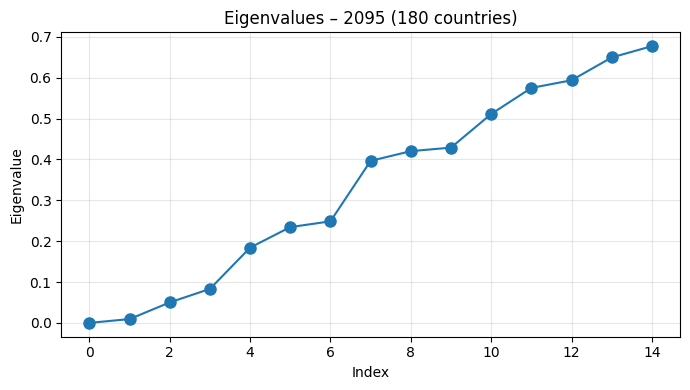

  Eigenvalues[:15]: [0.     0.0093 0.0501 0.0831 0.1842 0.2344 0.2485 0.3965 0.4202 0.4289
 0.5111 0.5749 0.5936 0.6495 0.6771]
  Gaps: [0.0093 0.0408 0.033  0.101  0.0502 0.0142 0.148  0.0237 0.0087 0.0822
 0.0638 0.0188 0.0558 0.0276]
  → Optimal number of clusters (eigengap): **7**
  Cluster sizes: [28 24 20 34 23 15 36]

Year: 2096


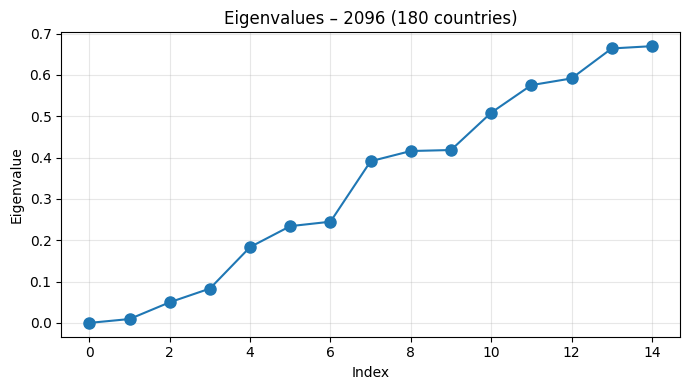

  Eigenvalues[:15]: [-0.      0.0093  0.0499  0.0831  0.1835  0.2341  0.2448  0.3911  0.4159
  0.4182  0.5085  0.5753  0.5915  0.664   0.6695]
  Gaps: [0.0093 0.0406 0.0332 0.1004 0.0506 0.0107 0.1463 0.0247 0.0024 0.0903
 0.0668 0.0162 0.0725 0.0055]
  → Optimal number of clusters (eigengap): **7**
  Cluster sizes: [28 23 20 35 23 36 15]

Year: 2097


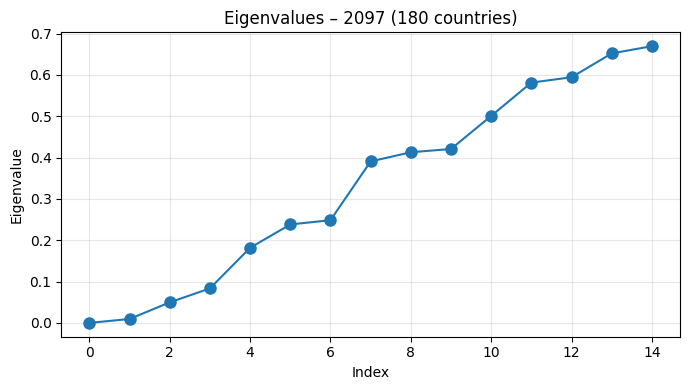

  Eigenvalues[:15]: [-0.      0.0094  0.0497  0.0834  0.1817  0.2383  0.2485  0.3908  0.413
  0.4209  0.5009  0.5815  0.5945  0.6522  0.6697]
  Gaps: [0.0094 0.0403 0.0337 0.0983 0.0565 0.0102 0.1423 0.0222 0.0079 0.08
 0.0806 0.013  0.0577 0.0176]
  → Optimal number of clusters (eigengap): **7**
  Cluster sizes: [23 37 15 28 25 32 20]

Year: 2098


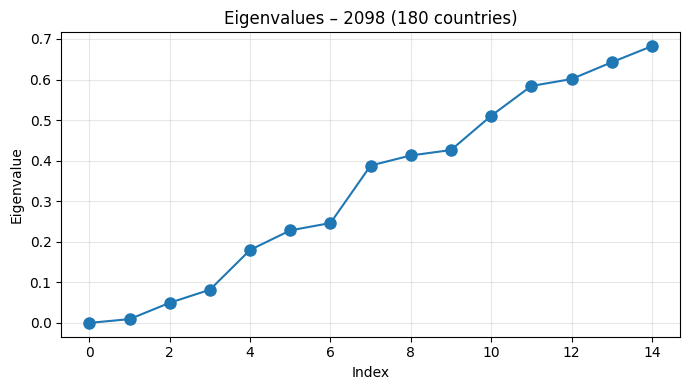

  Eigenvalues[:15]: [-0.      0.0093  0.0496  0.0818  0.1798  0.2281  0.2462  0.3879  0.4128
  0.4262  0.5106  0.5841  0.6012  0.6425  0.6823]
  Gaps: [0.0093 0.0403 0.0322 0.098  0.0483 0.0181 0.1417 0.0249 0.0134 0.0844
 0.0735 0.0171 0.0414 0.0397]
  → Optimal number of clusters (eigengap): **7**
  Cluster sizes: [23 28 34 15 28 20 32]

Year: 2099


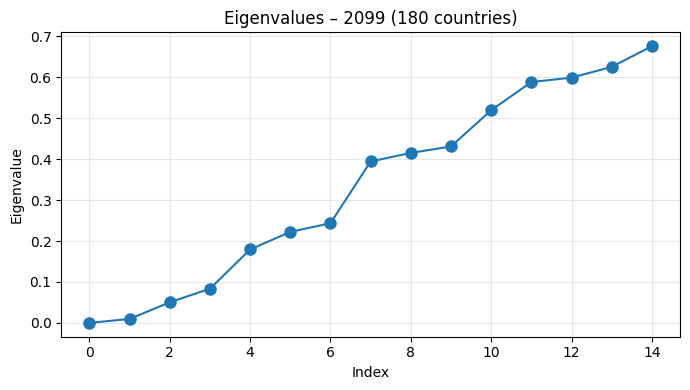

  Eigenvalues[:15]: [-0.      0.0096  0.0503  0.0835  0.1794  0.2224  0.2437  0.3946  0.4155
  0.4313  0.5198  0.5887  0.5994  0.6257  0.6764]
  Gaps: [0.0096 0.0407 0.0332 0.0959 0.043  0.0213 0.1509 0.0209 0.0158 0.0885
 0.069  0.0107 0.0263 0.0506]
  → Optimal number of clusters (eigengap): **7**
  Cluster sizes: [26 35 22 21 23 33 20]

Year: 2100


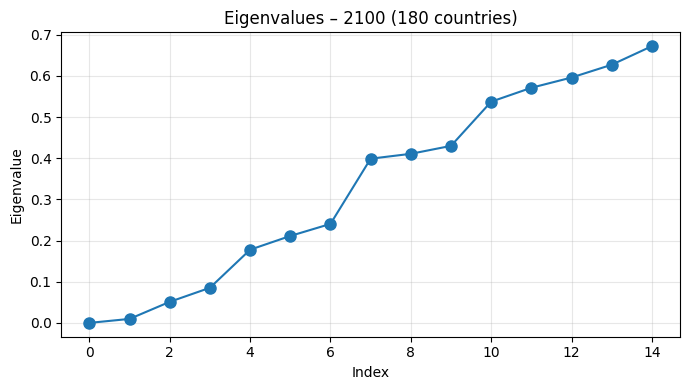

  Eigenvalues[:15]: [-0.      0.0097  0.0512  0.0853  0.1777  0.2111  0.2404  0.3988  0.4106
  0.4299  0.5372  0.571   0.5959  0.627   0.6721]
  Gaps: [0.0097 0.0415 0.0341 0.0925 0.0334 0.0293 0.1584 0.0118 0.0193 0.1073
 0.0338 0.0249 0.031  0.0451]
  → Optimal number of clusters (eigengap): **7**
  Cluster sizes: [23 27 34 27 21 16 32]

Optimal number of clusters per year (eigengap heuristic):
      Optimal_k
Year           
1950          3
1951          3
1952          8
1953          8
1954          3
...         ...
2096          7
2097          7
2098          7
2099          7
2100          7

[151 rows x 1 columns]


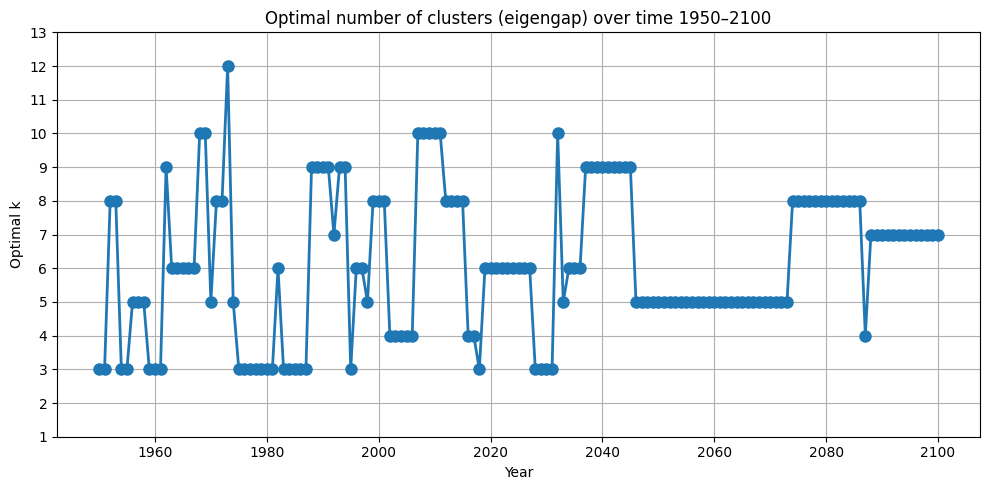


Saved full country-cluster assignments → spectral_clusters_1950_2100.csv


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import normalize
from sklearn.neighbors import kneighbors_graph

# =====================================================
# Spectral clustering on population pyramids 1950–2100
# Automatic optimal k via eigengap for EACH year
# =====================================================

CSV_PATH = "age_data_1.csv"          # ← change to your actual file path
N_NEIGHBORS = 15                     # 8–15 usually good; tune if needed
MAX_EIGEN = 15                       # Look at first 15 eigenvalues for gap
MIN_COUNTRIES_PER_YEAR = 100         # Skip years with too few countries

# Load full dataset (can be large — 200+ countries × many years × 21 ages)
df = pd.read_csv(CSV_PATH)

# Get available years in range
years = sorted(df['Time'].unique())
years = [y for y in years if 1950 <= y <= 2100]

print(f"Found {len(years)} years between 1950 and 2100: {years[:5]} ... {years[-5:]}")

optimal_ks = {}
cluster_sizes_per_year = {}
country_cluster_dfs = []   # optional: store full assignments if needed

for YEAR in years:
    print(f"\n{'='*50}\nYear: {YEAR}")

    df_year = df[df["Time"] == YEAR].copy()
    if df_year.empty:
        print(" → No data")
        continue

    df_pivot = df_year.pivot(
        index="Location",
        columns="AgeGrp",
        values="PopTotal"
    ).fillna(0)

    countries = df_pivot.index.values
    X = df_pivot.values

    if X.shape[1] != 21:
        print(f" → Skipping: {X.shape[1]} age groups (expected 21)")
        continue

    if len(countries) < MIN_COUNTRIES_PER_YEAR:
        print(f" → Skipping: only {len(countries)} countries")
        continue

    # Normalize rows → proportions (very important!)
    X_norm = normalize(X, norm="l1")

    # Build symmetric kNN graph
    W = kneighbors_graph(
        X_norm,
        n_neighbors=N_NEIGHBORS,
        mode="connectivity",
        include_self=False
    )
    W = 0.5 * (W + W.T)          # symmetrize
    W = W.toarray()

    # Normalized Laplacian
    degree = np.sum(W, axis=1)
    degree[degree == 0] = 1e-10  # avoid div by zero
    D_inv_sqrt = np.diag(1.0 / np.sqrt(degree))
    L = np.eye(len(countries)) - D_inv_sqrt @ W @ D_inv_sqrt

    # Eigen decomposition (smallest eigenvalues first)
    eigenvals = np.linalg.eigvalsh(L)
    eigenvals = np.sort(eigenvals)[:MAX_EIGEN]

    # Plot eigengap (optional — comment out for speed)
    plt.figure(figsize=(7, 4))
    plt.plot(eigenvals, 'o-', markersize=8)
    plt.title(f"Eigenvalues – {YEAR} ({len(countries)} countries)")
    plt.xlabel("Index")
    plt.ylabel("Eigenvalue")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.savefig(f"eigengap_{YEAR}.png", dpi=120)
    # plt.close()
    plt.show()   # ← comment if running many years

    # Eigengap heuristic
    gaps = np.diff(eigenvals)
    optimal_k = np.argmax(gaps) + 1
    optimal_ks[YEAR] = optimal_k

    print(f"  Eigenvalues[:{MAX_EIGEN}]: {np.round(eigenvals, 4)}")
    print(f"  Gaps: {np.round(gaps, 4)}")
    print(f"  → Optimal number of clusters (eigengap): **{optimal_k}**")

    # Optional: actually run clustering with this k and save sizes
    if optimal_k >= 2:
        sc = SpectralClustering(
            n_clusters=optimal_k,
            affinity="nearest_neighbors",
            n_neighbors=N_NEIGHBORS,
            assign_labels="kmeans",
            random_state=42
        )
        labels = sc.fit_predict(X_norm)

        sizes = pd.Series(labels).value_counts().sort_index()
        cluster_sizes_per_year[YEAR] = sizes.to_dict()

        print("  Cluster sizes:", sizes.values)

        # Optional: save full assignments
        df_res = pd.DataFrame({"Country": countries, "Cluster": labels, "Year": YEAR})
        country_cluster_dfs.append(df_res)

# Summary table of optimal k over time
k_df = pd.DataFrame.from_dict(optimal_ks, orient='index', columns=['Optimal_k'])
k_df.index.name = 'Year'
print("\nOptimal number of clusters per year (eigengap heuristic):")
print(k_df)

# Plot evolution of optimal k
plt.figure(figsize=(10, 5))
plt.plot(k_df.index, k_df['Optimal_k'], 'o-', linewidth=2, markersize=8)
plt.title("Optimal number of clusters (eigengap) over time 1950–2100")
plt.xlabel("Year")
plt.ylabel("Optimal k")
plt.grid(True)
plt.yticks(range(1, k_df['Optimal_k'].max()+2))
plt.tight_layout()
plt.show()

# Optional: save full results
if country_cluster_dfs:
    pd.concat(country_cluster_dfs).to_csv("spectral_clusters_1950_2100.csv", index=False)
    print("\nSaved full country-cluster assignments → spectral_clusters_1950_2100.csv")

Processing 151 years

Year: 1950
  Silhouette scores: {2: np.float64(0.5191), 3: np.float64(0.3255), 4: np.float64(0.315), 5: np.float64(0.3191), 6: np.float64(0.2982), 7: np.float64(0.3017)}
  → Optimal number of clusters: **2**
  Cluster sizes: [138  42]

Year: 1951
  Silhouette scores: {2: np.float64(0.5249), 3: np.float64(0.4557), 4: np.float64(0.2601), 5: np.float64(0.2741), 6: np.float64(0.294), 7: np.float64(0.2755)}
  → Optimal number of clusters: **2**
  Cluster sizes: [ 64 116]

Year: 1952
  Silhouette scores: {2: np.float64(0.5542), 3: np.float64(0.4285), 4: np.float64(0.2788), 5: np.float64(0.2626), 6: np.float64(0.2738), 7: np.float64(0.2722)}
  → Optimal number of clusters: **2**
  Cluster sizes: [138  42]

Year: 1953
  Silhouette scores: {2: np.float64(0.5293), 3: np.float64(0.2927), 4: np.float64(0.2631), 5: np.float64(0.278), 6: np.float64(0.2492), 7: np.float64(0.2643)}
  → Optimal number of clusters: **2**
  Cluster sizes: [125  55]

Year: 1954
  Silhouette scores: {

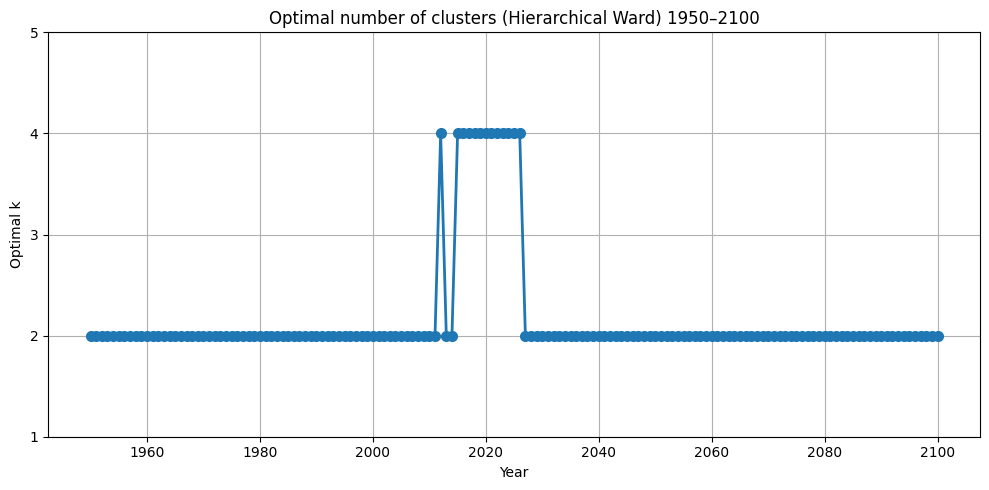


Saved → hierarchical_ward_clusters_1950_2100.csv


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import normalize
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# =====================================================
# Hierarchical (Ward) clustering on population pyramids
# Automatic optimal k via silhouette score for EACH year
# =====================================================

CSV_PATH = "age_data_1.csv"
MIN_COUNTRIES_PER_YEAR = 100
K_RANGE = range(2, 8)   # demographic clusters usually 2–7

df = pd.read_csv(CSV_PATH)

years = sorted(df["Time"].unique())
years = [y for y in years if 1950 <= y <= 2100]

optimal_ks = {}
cluster_sizes_per_year = {}
country_cluster_dfs = []

print(f"Processing {len(years)} years")

for YEAR in years:
    print(f"\n{'='*50}\nYear: {YEAR}")

    df_year = df[df["Time"] == YEAR].copy()
    if df_year.empty:
        print(" → No data")
        continue

    df_pivot = df_year.pivot(
        index="Location",
        columns="AgeGrp",
        values="PopTotal"
    ).fillna(0)

    countries = df_pivot.index.values
    X = df_pivot.values

    if X.shape[1] != 21:
        print(f" → Skipping: {X.shape[1]} age groups (expected 21)")
        continue

    if len(countries) < MIN_COUNTRIES_PER_YEAR:
        print(f" → Skipping: only {len(countries)} countries")
        continue

    # Normalize population pyramids (critical)
    X_norm = normalize(X, norm="l1")

    # =========================
    # FIND OPTIMAL K (Silhouette)
    # =========================
    sil_scores = []

    for k in K_RANGE:
        model = AgglomerativeClustering(
            n_clusters=k,
            linkage="ward"
        )
        labels = model.fit_predict(X_norm)
        score = silhouette_score(X_norm, labels, metric="euclidean")
        sil_scores.append(score)

    optimal_k = K_RANGE[np.argmax(sil_scores)]
    optimal_ks[YEAR] = optimal_k

    print(f"  Silhouette scores: {dict(zip(K_RANGE, np.round(sil_scores, 4)))}")
    print(f"  → Optimal number of clusters: **{optimal_k}**")

    # =========================
    # FINAL CLUSTERING
    # =========================
    model = AgglomerativeClustering(
        n_clusters=optimal_k,
        linkage="ward"
    )
    labels = model.fit_predict(X_norm)

    sizes = pd.Series(labels).value_counts().sort_index()
    cluster_sizes_per_year[YEAR] = sizes.to_dict()

    print("  Cluster sizes:", sizes.values)

    df_res = pd.DataFrame({
        "Country": countries,
        "Cluster": labels,
        "Year": YEAR
    })
    country_cluster_dfs.append(df_res)

# =========================
# SUMMARY OF OPTIMAL K
# =========================
k_df = pd.DataFrame.from_dict(optimal_ks, orient="index", columns=["Optimal_k"])
k_df.index.name = "Year"

print("\nOptimal number of clusters per year:")
print(k_df)

plt.figure(figsize=(10, 5))
plt.plot(k_df.index, k_df["Optimal_k"], "o-", linewidth=2, markersize=7)
plt.title("Optimal number of clusters (Hierarchical Ward) 1950–2100")
plt.xlabel("Year")
plt.ylabel("Optimal k")
plt.grid(True)
plt.yticks(range(1, k_df["Optimal_k"].max() + 2))
plt.tight_layout()
plt.show()

# =========================
# SAVE RESULTS
# =========================
if country_cluster_dfs:
    pd.concat(country_cluster_dfs).to_csv(
        "hierarchical_ward_clusters_1950_2100.csv",
        index=False
    )
    print("\nSaved → hierarchical_ward_clusters_1950_2100.csv")


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import normalize
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
import umap.umap_ as umap

# =====================================================
# Hierarchical clustering (Ward) + PCA + UMAP
# Population pyramids (21 age groups)
# =====================================================

CSV_PATH = "age_data_1.csv"
YEAR = 2020
N_CLUSTERS = 5    # change AFTER inspecting dendrogram

# =========================
# LOAD DATA
# =========================
df = pd.read_csv(CSV_PATH)
df_year = df[df["Time"] == YEAR].copy()

df_pivot = df_year.pivot(
    index="Location",
    columns="AgeGrp",
    values="PopTotal"
).fillna(0)

countries = df_pivot.index.values
X = df_pivot.values

assert X.shape[1] == 21, "Must have exactly 21 age groups"

# =========================
# NORMALIZE PYRAMIDS
# =========================
X = normalize(X, norm="l1")

# =========================
# HIERARCHICAL LINKAGE (WARD)
# =========================
Z = linkage(X, method="ward")

# =========================
# DENDROGRAM
# =========================
plt.figure(figsize=(12, 5))
dendrogram(Z, no_labels=True)
plt.title(f"Hierarchical Dendrogram (Ward) – {YEAR}")
plt.xlabel("Countries")
plt.ylabel("Distance")
plt.grid(alpha=0.3)
plt.show()

# =========================
# FINAL CLUSTERING
# =========================
hc = AgglomerativeClustering(
    n_clusters=N_CLUSTERS,
    linkage="ward"
)
labels = hc.fit_predict(X)

# =========================
# PCA (2D)
# =========================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    cmap="tab10",
    s=50,
    alpha=0.8
)
plt.colorbar(scatter, label="Cluster")
plt.title(f"PCA Projection (Ward Hierarchical) – {YEAR}")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.grid(alpha=0.3)
plt.show()

# =========================
# UMAP (2D)
# =========================
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)
X_umap = umap_model.fit_transform(X)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=labels,
    cmap="tab10",
    s=50,
    alpha=0.8
)
plt.colorbar(scatter, label="Cluster")
plt.title(f"UMAP Projection (Ward Hierarchical) – {YEAR}")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.grid(alpha=0.3)
plt.show()

# =========================
# OUTPUT TABLE
# =========================
results = pd.DataFrame({
    "Country": countries,
    "Cluster": labels
}).sort_values("Cluster")

print(results.head(30))
print("\nCluster sizes:")
print(results["Cluster"].value_counts().sort_index())


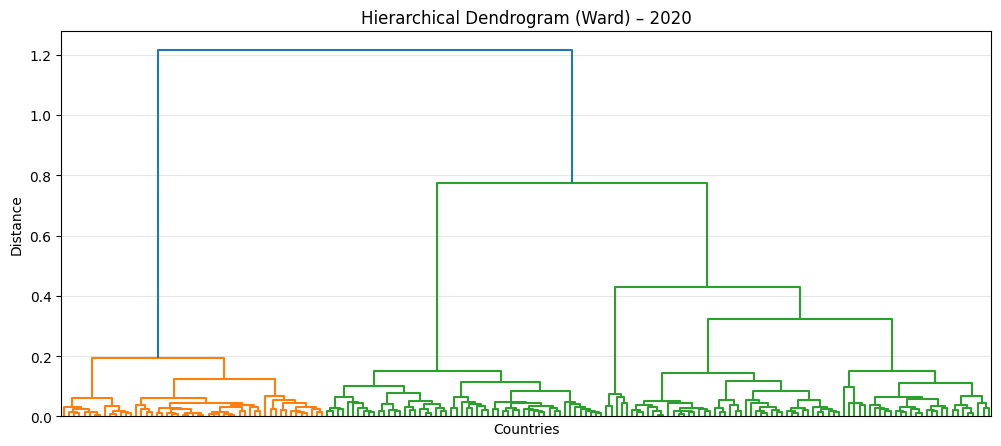

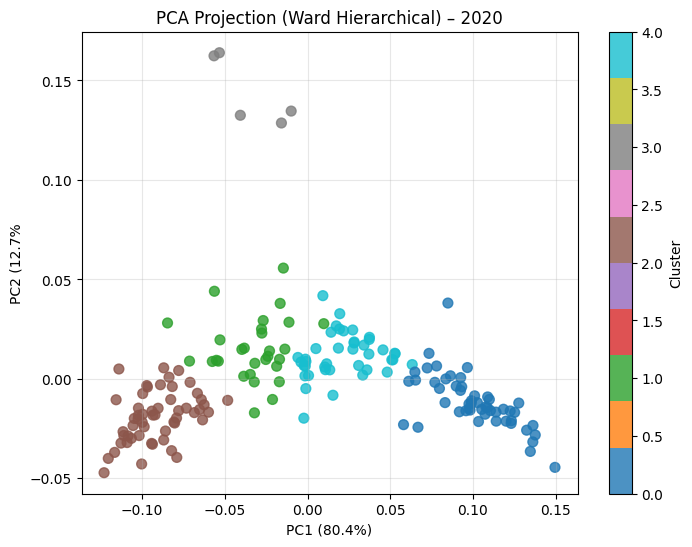

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


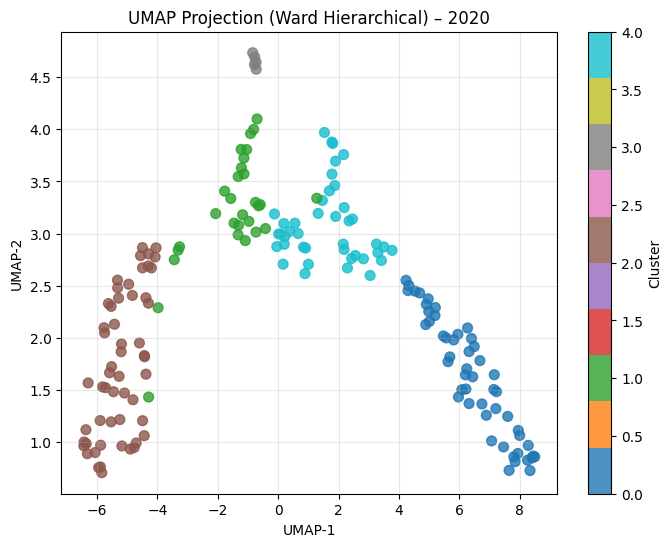

                                Country  Cluster
0                           Afghanistan        0
3                                Angola        0
31                                 Chad        0
29                             Cameroon        0
25                         Burkina Faso        0
26                              Burundi        0
17                                Benin        0
62                                Ghana        0
51                              Eritrea        0
50                    Equatorial Guinea        0
54                             Ethiopia        0
53                             Eswatini        0
58                                Gabon        0
43                        Côte d'Ivoire        0
36                                Congo        0
35                              Comoros        0
59                               Gambia        0
97                               Malawi        0
102                          Mauritania        0
100                 

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import normalize
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
import umap.umap_ as umap

# =====================================================
# Hierarchical clustering (Ward) + PCA + UMAP
# Population pyramids (21 age groups)
# =====================================================

CSV_PATH = "age_data_1.csv"
YEAR = 2020
N_CLUSTERS = 5    # change AFTER inspecting dendrogram

# =========================
# LOAD DATA
# =========================
df = pd.read_csv(CSV_PATH)
df_year = df[df["Time"] == YEAR].copy()

df_pivot = df_year.pivot(
    index="Location",
    columns="AgeGrp",
    values="PopTotal"
).fillna(0)

countries = df_pivot.index.values
X = df_pivot.values

assert X.shape[1] == 21, "Must have exactly 21 age groups"

# =========================
# NORMALIZE PYRAMIDS
# =========================
X = normalize(X, norm="l1")

# =========================
# HIERARCHICAL LINKAGE (WARD)
# =========================
Z = linkage(X, method="ward")

# =========================
# DENDROGRAM
# =========================
plt.figure(figsize=(12, 5))
dendrogram(Z, no_labels=True)
plt.title(f"Hierarchical Dendrogram (Ward) – {YEAR}")
plt.xlabel("Countries")
plt.ylabel("Distance")
plt.grid(alpha=0.3)
plt.show()

# =========================
# FINAL CLUSTERING
# =========================
hc = AgglomerativeClustering(
    n_clusters=N_CLUSTERS,
    linkage="ward"
)
labels = hc.fit_predict(X)

# =========================
# PCA (2D)
# =========================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    cmap="tab10",
    s=50,
    alpha=0.8
)
plt.colorbar(scatter, label="Cluster")
plt.title(f"PCA Projection (Ward Hierarchical) – {YEAR}")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%")
plt.grid(alpha=0.3)
plt.show()

# =========================
# UMAP (2D)
# =========================
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)
X_umap = umap_model.fit_transform(X)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=labels,
    cmap="tab10",
    s=50,
    alpha=0.8
)
plt.colorbar(scatter, label="Cluster")
plt.title(f"UMAP Projection (Ward Hierarchical) – {YEAR}")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.grid(alpha=0.3)
plt.show()

# =========================
# OUTPUT TABLE
# =========================
results = pd.DataFrame({
    "Country": countries,
    "Cluster": labels
}).sort_values("Cluster")

print(results.to_string())

Countries compared: 180

Contingency table:
Spectral       0   1   2   3   4   5
Hierarchical                        
0              0   0   0  21   0  30
1              5  23   0   0   1   0
2             25   0  29   0   0   0
3              0   5   0   0   0   0
4              0  11   0   0  30   0

Adjusted Rand Index (ARI): 0.547
Normalized Mutual Information (NMI): 0.712


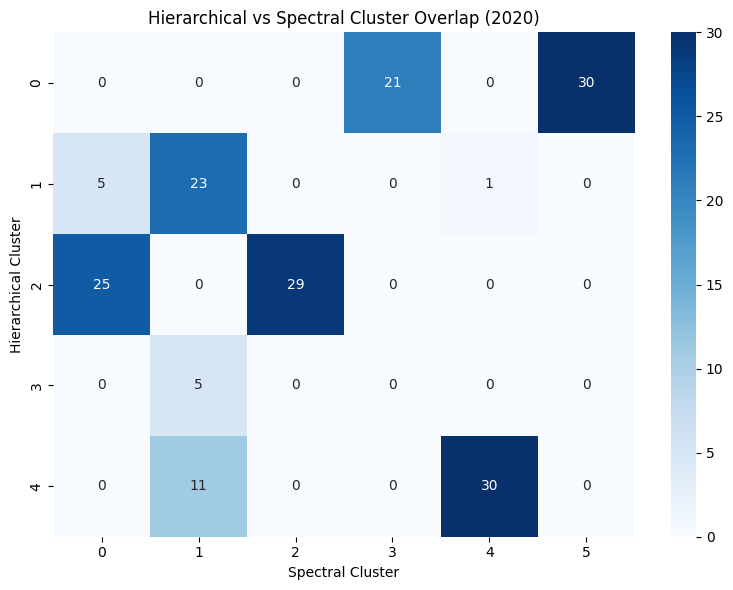


Hierarchical → Spectral best-match mapping:
{0: 5, 1: 1, 2: 2, 3: 1, 4: 4}


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import normalize
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.cluster.hierarchy import linkage

# =====================================================
# MATCH HIERARCHICAL (WARD) vs SPECTRAL CLUSTERING
# Population pyramids – YEAR 2020
# =====================================================

CSV_PATH = "age_data_1.csv"
SPECTRAL_PATH = "spectral_clusters_1950_2100.csv"
YEAR = 2020
N_CLUSTERS = 5   # use same as hierarchical result you trust

# =========================
# LOAD DATA
# =========================
df = pd.read_csv(CSV_PATH)
df_year = df[df["Time"] == YEAR].copy()

df_pivot = df_year.pivot(
    index="Location",
    columns="AgeGrp",
    values="PopTotal"
).fillna(0)

countries = df_pivot.index.values
X = df_pivot.values

assert X.shape[1] == 21, "Expected 21 age groups"

# =========================
# NORMALIZE PYRAMIDS
# =========================
X = normalize(X, norm="l1")

# =========================
# HIERARCHICAL CLUSTERING (WARD)
# =========================
Z = linkage(X, method="ward")

hc = AgglomerativeClustering(
    n_clusters=N_CLUSTERS,
    linkage="ward"
)
hier_labels = hc.fit_predict(X)

hier_df = pd.DataFrame({
    "Country": countries,
    "Hierarchical": hier_labels
})

# =========================
# LOAD SPECTRAL RESULTS
# =========================
spectral_df = pd.read_csv(SPECTRAL_PATH)
spectral_df = spectral_df[spectral_df["Year"] == YEAR][["Country", "Cluster"]]
spectral_df = spectral_df.rename(columns={"Cluster": "Spectral"})

# =========================
# ALIGN COUNTRIES
# =========================
merged = hier_df.merge(
    spectral_df,
    on="Country",
    how="inner"
)

print(f"Countries compared: {len(merged)}")

# =========================
# CONTINGENCY TABLE
# =========================
ct = pd.crosstab(
    merged["Hierarchical"],
    merged["Spectral"]
)

print("\nContingency table:")
print(ct)

# =========================
# AGREEMENT METRICS
# =========================
ari = adjusted_rand_score(
    merged["Hierarchical"],
    merged["Spectral"]
)

nmi = normalized_mutual_info_score(
    merged["Hierarchical"],
    merged["Spectral"]
)

print(f"\nAdjusted Rand Index (ARI): {ari:.3f}")
print(f"Normalized Mutual Information (NMI): {nmi:.3f}")

# =========================
# HEATMAP VISUALIZATION
# =========================
plt.figure(figsize=(8, 6))
sns.heatmap(
    ct,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Hierarchical vs Spectral Cluster Overlap (2020)")
plt.xlabel("Spectral Cluster")
plt.ylabel("Hierarchical Cluster")
plt.tight_layout()
plt.show()

# =========================
# OPTIONAL: BEST MATCH RELABELING (FOR VISUALS ONLY)
# =========================
mapping = ct.idxmax(axis=1).to_dict()
merged["Hierarchical_matched"] = merged["Hierarchical"].map(mapping)

print("\nHierarchical → Spectral best-match mapping:")
print(mapping)


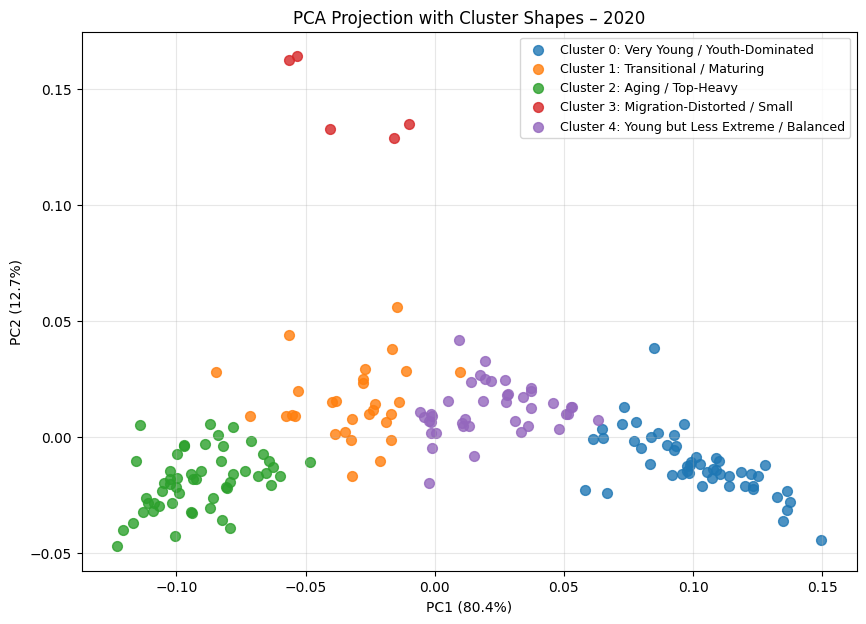

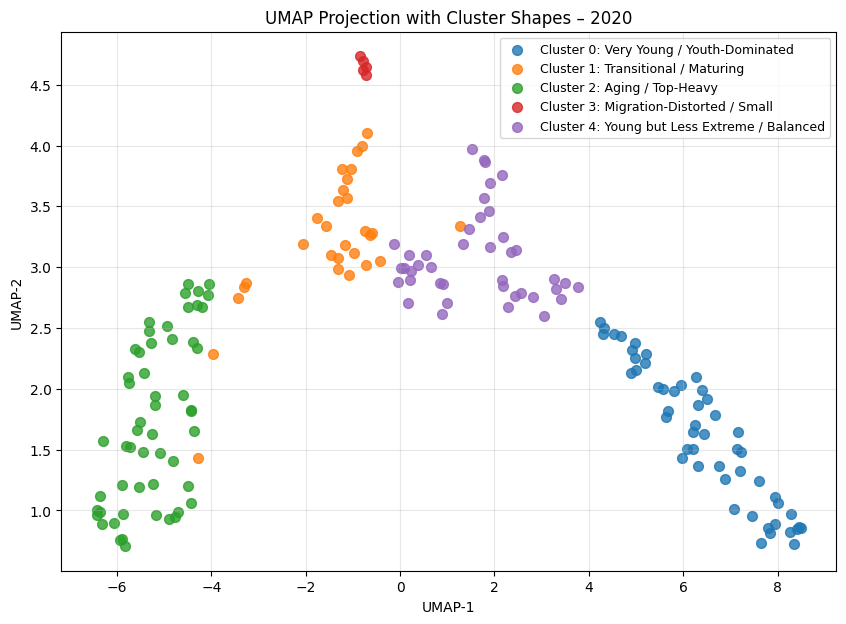

In [23]:
import matplotlib.pyplot as plt

# =========================
# Map cluster numbers to shapes
# =========================
cluster_shapes = {
    0: "Very Young / Youth-Dominated",
    1: "Transitional / Maturing",
    2: "Aging / Top-Heavy",
    3: "Migration-Distorted / Small",
    4: "Young but Less Extreme / Balanced"
}

# Add shape labels to results
results['Shape'] = results['Cluster'].map(cluster_shapes)

# =========================
# PCA Visualization with Shape Labels
# =========================
plt.figure(figsize=(10, 7))
for cluster_num, shape in cluster_shapes.items():
    idx = labels == cluster_num
    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        label=f"Cluster {cluster_num}: {shape}",
        s=50,
        alpha=0.8
    )

plt.title(f"PCA Projection with Cluster Shapes – {YEAR}")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.grid(alpha=0.3)
plt.legend(loc="best", fontsize=9)
plt.show()

# =========================
# UMAP Visualization with Shape Labels
# =========================
plt.figure(figsize=(10, 7))
for cluster_num, shape in cluster_shapes.items():
    idx = labels == cluster_num
    plt.scatter(
        X_umap[idx, 0],
        X_umap[idx, 1],
        label=f"Cluster {cluster_num}: {shape}",
        s=50,
        alpha=0.8
    )

plt.title(f"UMAP Projection with Cluster Shapes – {YEAR}")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.grid(alpha=0.3)
plt.legend(loc="best", fontsize=9)
plt.show()


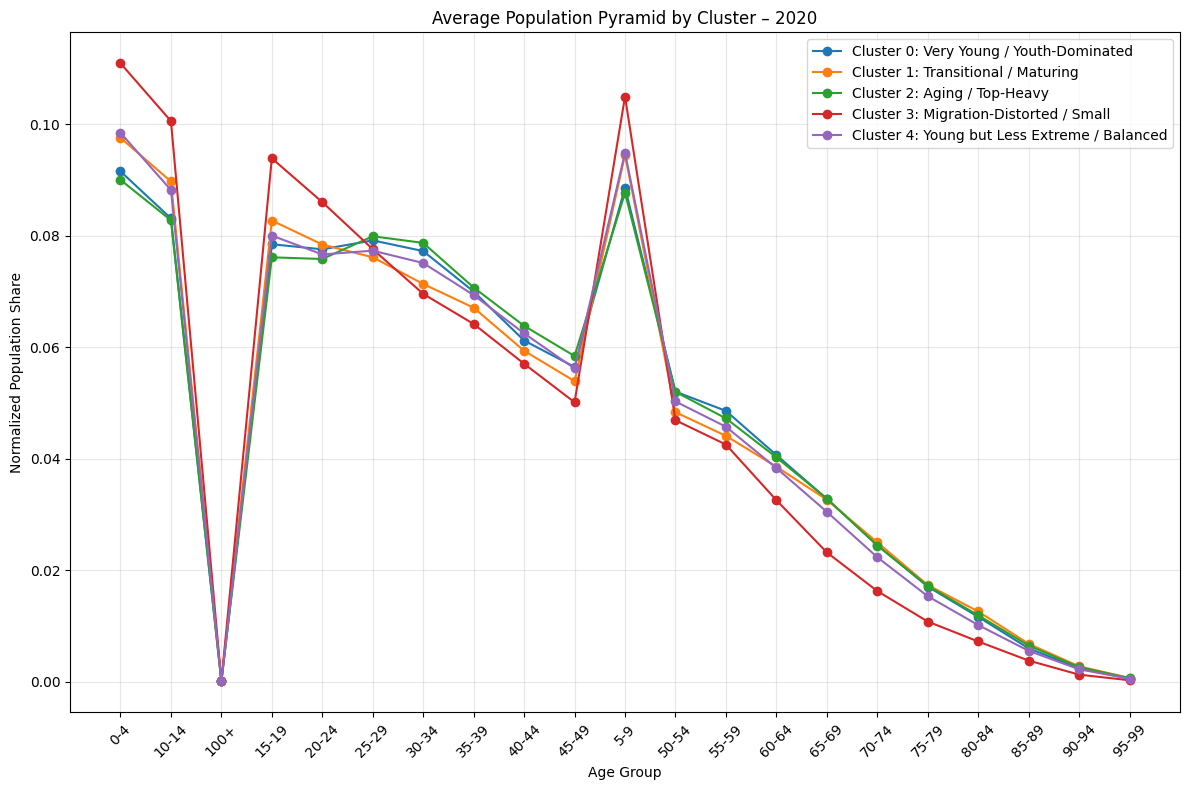

In [24]:
# =========================
# Plot Population Pyramids by Cluster
# =========================
age_groups = df_pivot.columns.tolist()
n_clusters = len(cluster_shapes)

plt.figure(figsize=(12, 8))

for cluster_num, shape_desc in cluster_shapes.items():
    # Get countries in this cluster
    idx = results['Cluster'] == cluster_num
    cluster_data = X[idx, :]  # normalized populations

    # Compute average pyramid for the cluster
    avg_pyramid = cluster_data.mean(axis=0)

    # Plot
    plt.plot(age_groups, avg_pyramid, marker='o', label=f"Cluster {cluster_num}: {shape_desc}")

plt.title(f"Average Population Pyramid by Cluster – {YEAR}")
plt.xlabel("Age Group")
plt.ylabel("Normalized Population Share")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


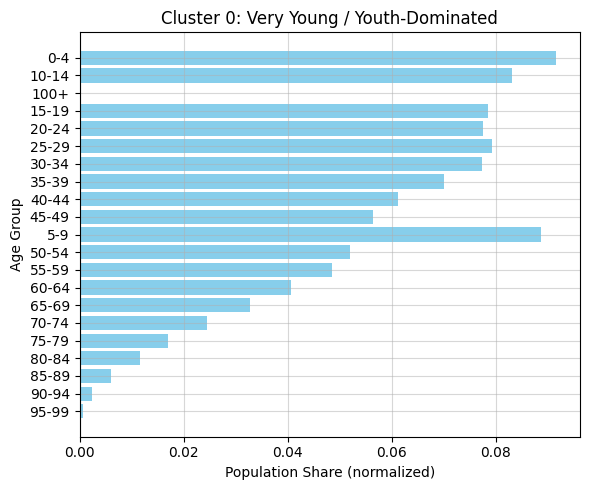

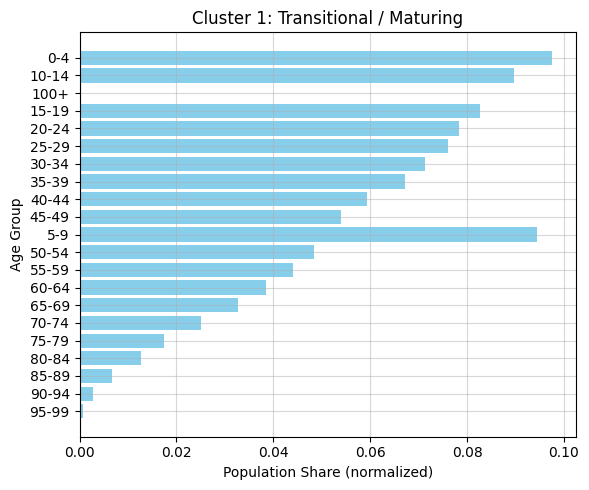

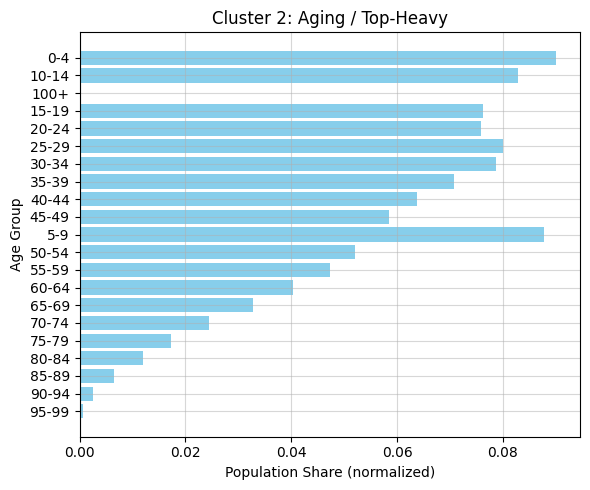

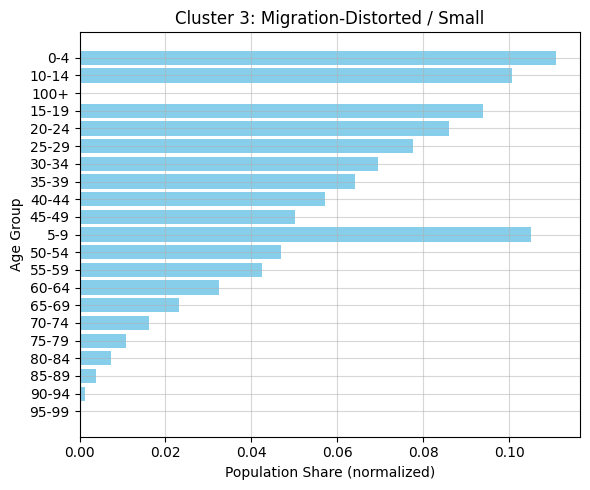

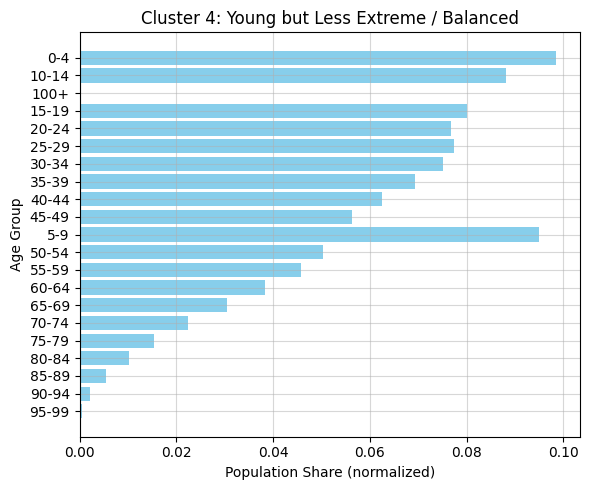

In [26]:
# =========================
# Population Pyramid Plots by Cluster
# =========================
age_groups = df_pivot.columns.tolist()

for cluster_num, shape_desc in cluster_shapes.items():
    idx = results['Cluster'] == cluster_num
    cluster_data = X[idx, :]

    # Compute average population for males and females
    # Here assuming age groups combine male+female; if only total, we just plot total
    avg_pyramid = cluster_data.mean(axis=0)

    # Plot pyramid
    plt.figure(figsize=(6, 5))
    plt.barh(age_groups, avg_pyramid, color='skyblue')
    plt.xlabel("Population Share (normalized)")
    plt.ylabel("Age Group")
    plt.title(f"Cluster {cluster_num}: {shape_desc}")
    plt.gca().invert_yaxis()  # so youngest age at bottom
    plt.grid(alpha=0.5)
    plt.tight_layout()
    plt.show()


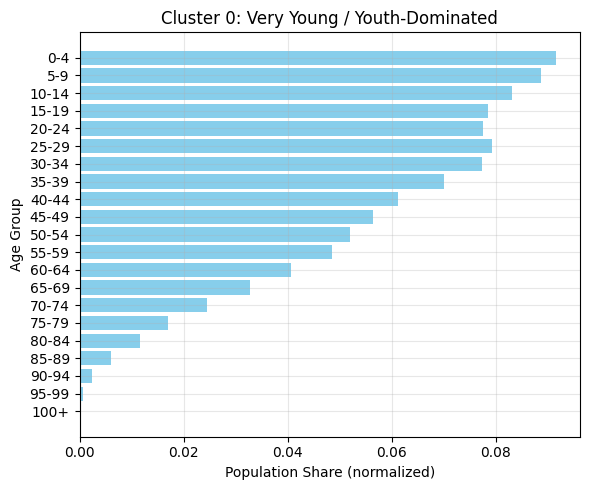

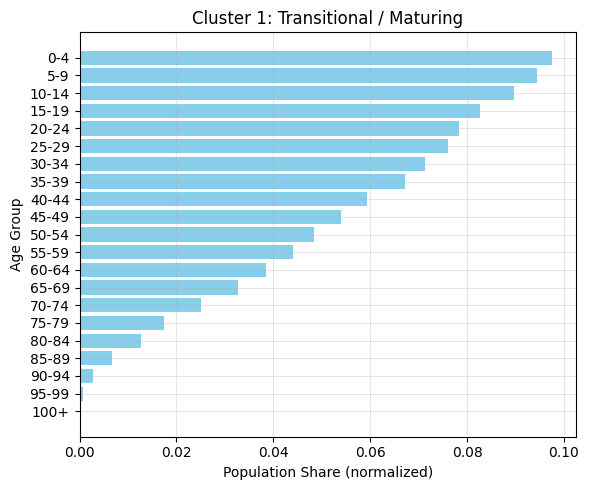

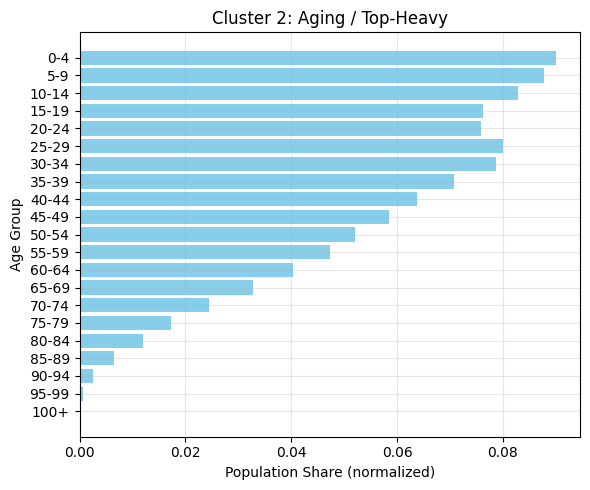

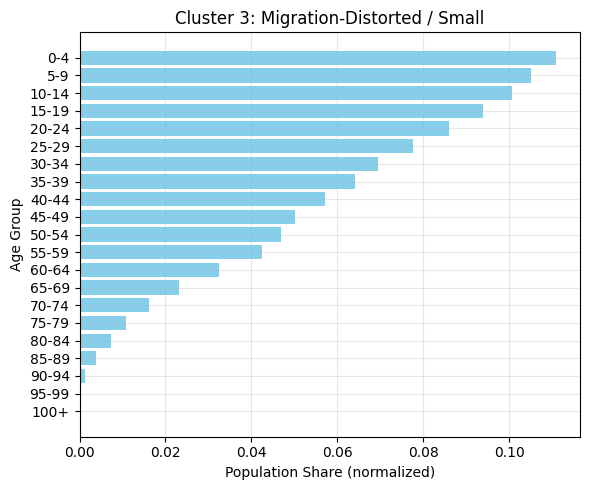

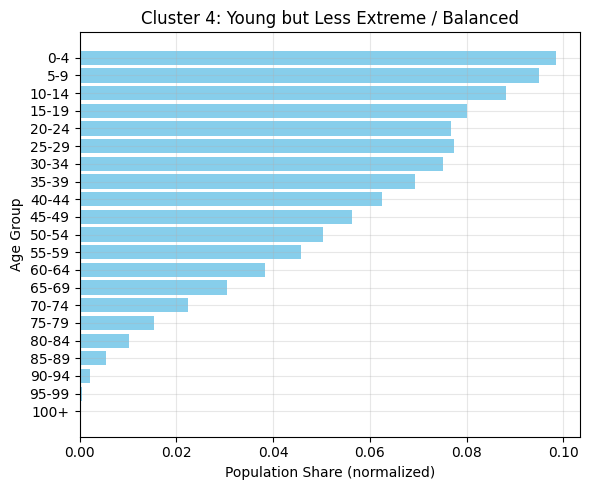

In [27]:
# =========================
# Correct age group order
# =========================
# Example age group labels: ['0-4', '5-9', ..., '95-99', '100+']
def sort_age_groups(age_groups):
    def age_key(age):
        if age == "100+":
            return 100
        else:
            return int(age.split("-")[0])
    return sorted(age_groups, key=age_key)

age_groups_sorted = sort_age_groups(df_pivot.columns.tolist())

# Reorder X accordingly
X_sorted = X[:, [df_pivot.columns.get_loc(a) for a in age_groups_sorted]]

# =========================
# Plot population pyramids by cluster
# =========================
for cluster_num, shape_desc in cluster_shapes.items():
    idx = results['Cluster'] == cluster_num
    cluster_data = X_sorted[idx, :]

    # Average population for the cluster
    avg_pyramid = cluster_data.mean(axis=0)

    # Horizontal bar plot (classic pyramid)
    plt.figure(figsize=(6, 5))
    plt.barh(age_groups_sorted, avg_pyramid, color='skyblue')
    plt.xlabel("Population Share (normalized)")
    plt.ylabel("Age Group")
    plt.title(f"Cluster {cluster_num}: {shape_desc}")
    plt.gca().invert_yaxis()  # youngest at bottom
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


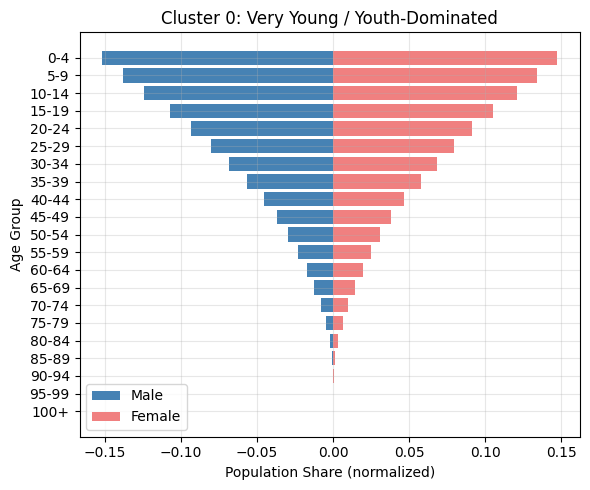

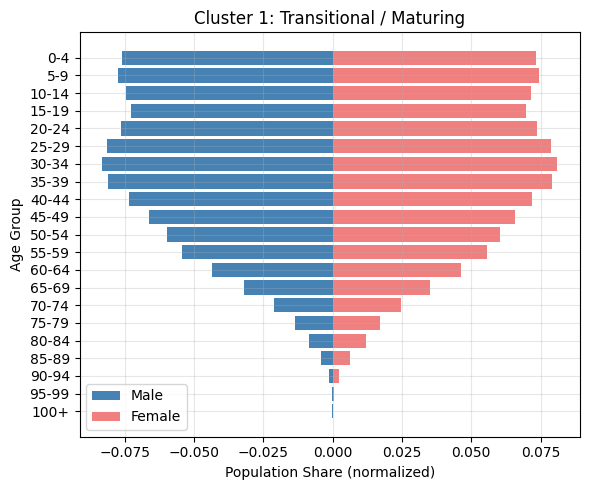

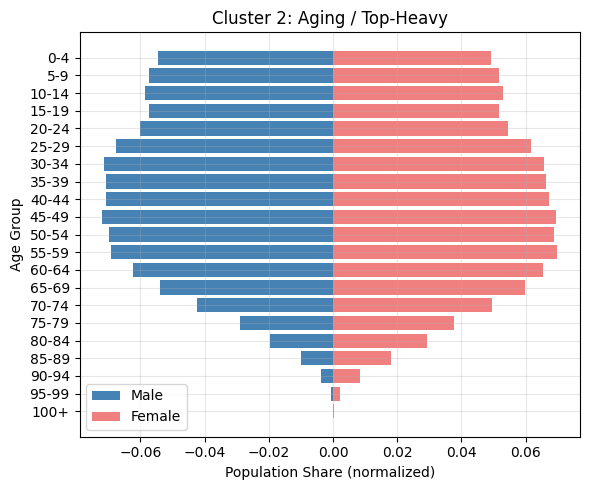

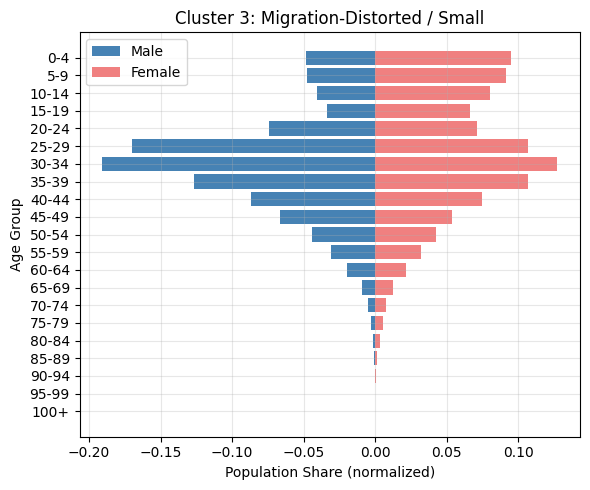

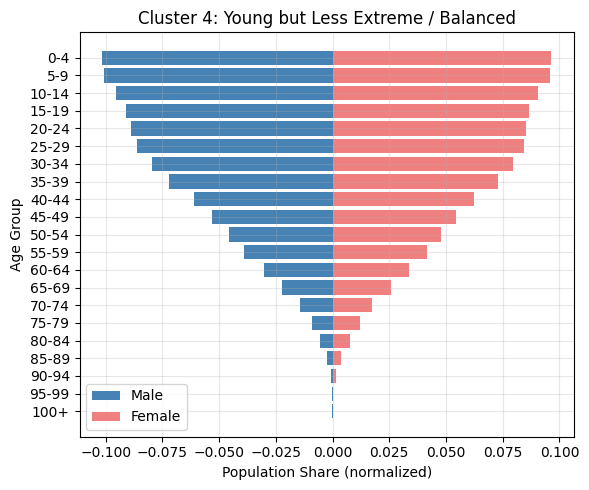

In [28]:
# =========================
# Population Pyramids by Cluster (Male & Female)
# =========================
# Sort age groups
def sort_age_groups(age_groups):
    def age_key(age):
        if age == "100+":
            return 100
        else:
            return int(age.split("-")[0])
    return sorted(age_groups, key=age_key)

age_groups_sorted = sort_age_groups(df_pivot.columns.tolist())

for cluster_num, shape_desc in cluster_shapes.items():
    idx = results['Cluster'] == cluster_num
    cluster_countries = results[idx]['Country'].values

    # Get data for cluster
    cluster_data = df_year[df_year['Location'].isin(cluster_countries)]

    # Pivot male and female separately
    pivot_male = cluster_data.pivot(index='Location', columns='AgeGrp', values='PopMale').fillna(0)
    pivot_female = cluster_data.pivot(index='Location', columns='AgeGrp', values='PopFemale').fillna(0)

    # Reorder columns
    pivot_male = pivot_male[age_groups_sorted]
    pivot_female = pivot_female[age_groups_sorted]

    # Normalize by total population per country
    pivot_male_norm = pivot_male.div(pivot_male.sum(axis=1), axis=0)
    pivot_female_norm = pivot_female.div(pivot_female.sum(axis=1), axis=0)

    # Average pyramid across countries
    avg_male = pivot_male_norm.mean(axis=0)
    avg_female = pivot_female_norm.mean(axis=0)

    # Plot population pyramid
    plt.figure(figsize=(6, 5))
    plt.barh(age_groups_sorted, -avg_male, color='steelblue', label='Male')  # negative for left side
    plt.barh(age_groups_sorted, avg_female, color='lightcoral', label='Female')

    plt.title(f"Cluster {cluster_num}: {shape_desc}")
    plt.xlabel("Population Share (normalized)")
    plt.ylabel("Age Group")
    plt.gca().invert_yaxis()  # youngest at bottom
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
